## 0. Project setup and scalar potential

In this section we fix the **project path** and the **model parameters** used throughout the notebook.

We work with a double–well scalar potential $V(\phi)$ with a **false vacuum** at $\phi = v_1$ and a **true vacuum** at $\phi = v_2$.

At finite chemical potential $\omega$ the relevant thermodynamic potential is the **grand potential**
$$
\Omega(\phi) = V(\phi) - \omega^2 \phi^2 \,,
$$
which controls the metastability of the false vacuum and the nucleation of the critical bubble. The 2D solver uses the same physics: the homogeneous value $\rho_0$ satisfies $W(\rho_0^2)=\omega^2$, i.e. $V'(\rho_0)=2\omega^2\rho_0$.

**What the code does:** the first cell sets `PROJECT_ROOT` (project path), `PHI0` (field value near the centre of the bounce), `V1`, `V2` (false and true vacua) and `OMEGA` ($\omega$). The next cell imports the modules, builds the potential $U(\rho)=V(\phi)$ for the 2D solver via `make_potential_from_V`, and configures LaTeX for plotting.


In [1]:
# ============================================================================
# Project path and configuration
# ============================================================================

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Model parameters (same potential as in the 4D bounce notebook)
PHI0 = 1.999   # field value near the center of the bounce
V1 = 1.0       # false vacuum
V2 = 2.0       # true vacuum
OMEGA = 0.85    # chemical potential ω (can be changed)

print(f"Project root: {PROJECT_ROOT}")
print(f"Potential: false vacuum at φ={V1}, true vacuum at φ={V2}")
print(f"φ0 = {PHI0},  ω = {OMEGA}")

Project root: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX
Potential: false vacuum at φ=1.0, true vacuum at φ=2.0
φ0 = 1.999,  ω = 0.85


In [2]:
# ============================================================================
# Imports
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

from Q_ball_finder.grid import build_grid, RadialTimeGrid

from Bubble_finder.potential_bubble import (
    V_phi, dV_dphi, d2V_dphi2, Omega_phi, dOmega_dphi, d2Omega_dphi2, vacua_of_Omega,
)
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver, make_potential_from_V, solve_rho0_for_omega
from Bubble_finder.bounce_1d import solve_bounce
from Bubble_finder.ansatz_bubble import (
    AnsatzParams, build_seed_bubble, compute_negative_mode_1d, compute_Dp_shooting_1d, bc_projector_y,
    make_q_ball_objects, make_bubble_profile_1d_from_solve_bounce, PotentialModel,
)
from Bubble_finder.ansatz_bubble import select_best_seed

# Potential U(ρ)=V(φ) for the 2D solver (requires PHI0, V1, V2 from previous cell)
U, dU, d2U = make_potential_from_V(V_phi, dV_dphi, d2V_dphi2, phi0=PHI0, v1=V1, v2=V2)

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}",
})
plt.rcParams["figure.figsize"] = (7, 4.8)

print("Imports completed.")

Imports completed.


## Conventions and Observables (reference)

Reference for the conventions and observables used in the rest of the notebook. All formulas are consistent with the code in `Bubble_finder.observables_2d` and with the 2D solver.

**Twisted boundary conditions.** Half-box $\tau \in [-\beta/2,\, 0]$ with twist closure at $\tau = -\beta/2$. **Rotated frame**: $y = r(\varphi_{\mathrm{rot}} - \rho_0)$, $\bar y = r(\bar\varphi_{\mathrm{rot}} - \rho_0)$; homogeneous background $y = \bar y = 0$.

**Charge $Q$ and density $q(r)$.** We use the same convention as the 1D code:
$$
q(\tau,r) = \frac{1}{2}\,\mathrm{Re}\bigl(\bar\varphi\,\partial_\tau\varphi - \varphi\,\partial_\tau\bar\varphi\bigr)\,, \qquad Q(\tau) = 4\pi\int_0^{r_{\max}}\!\! r^2\, q(\tau,r)\,\mathrm{d}r\,.
$$
At $\tau=0$ the solver has no grid point; we use **ghost reconstruction**: values just above and below $\tau=0$ are defined by the twist ($y_+ = \bar y|_0$, $y_- = y|_0$, etc.), then we form the midpoint and a central $\tau$-derivative. So **ground-truth** $Q$ and $E$ are those at $\tau=0$ from this ghost procedure (`compute_charge_tau0_ghost_2d`, `compute_energy_tau0_ghost_2d`). Optional background subtraction: $Q \to Q - Q_{\mathrm{hom}}$ with
$$
Q_{\mathrm{hom}} = 4\pi\,\omega\,\rho_0^2\,\frac{r_{\max}^3}{3}\,.
$$

**Energy $E$ and density $e(r)$.**
$$
e(\tau,r) = -(\partial_\tau\varphi)(\partial_\tau\bar\varphi) + (\partial_r\varphi)(\partial_r\bar\varphi) + V(\rho) - V(\rho_0)\,.
$$
**Reference energy**: we subtract $V(\rho_0)$, the potential of the homogeneous false vacuum, so that $E = 0$ for the uniform configuration. This makes $E$ the *excess* energy over the homogeneous background. $V(\rho)$ uses $\rho$ from the rotated fields (same as the solver). $E(\tau) = 4\pi\int r^2\, e\,\mathrm{d}r$; at $\tau=0$ we use the same ghost reconstruction as for $Q$.

**Why $\omega\cdot Q$ is not the energy.** For a homogeneous Q-ball, $E$ and $Q$ are related by the thermodynamic identity, but for an inhomogeneous configuration (e.g. the bubble) $E$ is given by the integral above; $\omega\cdot Q \neq E$. So we never set $E_{\mathrm{target}} = \omega\cdot Q_{\mathrm{target}}$.

**Densities and targets.** Volume $V = \frac{4}{3}\pi\,L_r^3$ with $L_r = r_{\max}$. Charge density $\rho_Q = Q/V$, energy density $\rho_E = E/V$. **Targets** ($Q_{\mathrm{target}}$, $E_{\mathrm{target}}$, $\rho_{Q,\mathrm{target}}$, $\rho_{E,\mathrm{target}}$) are computed by applying the *same* $\tau=0$ ghost observables to the homogeneous configuration ($y = \bar y = 0$) on the same grid (`compute_targets_tau0_ghost`). Use them for ratios $Q/Q_{\mathrm{target}}$, $E/E_{\mathrm{target}}$ in scans.

## 1. One-dimensional critical bubble

In this section we compute the **O(3)-symmetric one-dimensional critical bubble** $\phi_{\mathrm{cb}}(r)$ at fixed chemical potential $\omega$.

The radial equation for the bounce profile in $d$ spatial dimensions is
$$
\phi''(r) + \frac{d-1}{r}\,\phi'(r) = \frac{\partial \Omega(\phi)}{\partial \phi} \, ,
$$
with $d = 3$ and grand potential $\Omega(\phi) = V(\phi) - \omega^2 \phi^2$, so that $\partial\Omega/\partial\phi = V'(\phi) - 2\omega^2\phi$.

We impose:
- regularity at the origin, $\phi'(0) = 0$, so that the solution is smooth at $r = 0$;
- approach to the false vacuum as $r \to \infty$, $\phi(r) \to \phi_\text{false}$.

We use a simple **overshoot/undershoot** algorithm with bisection in the initial value $\phi(0)$ to find the bounce profile $\{ r_{\mathrm{cb}},\, \phi_{\mathrm{cb}}(r) \}$, which will later be used as input for the 2D construction.

**Implementation:** we use `solve_bounce` from `Bubble_finder.bounce_1d`; the output arrays `r_bounce` and `phi_bounce` (or equivalents) define the radial profile of the 1D critical bubble.


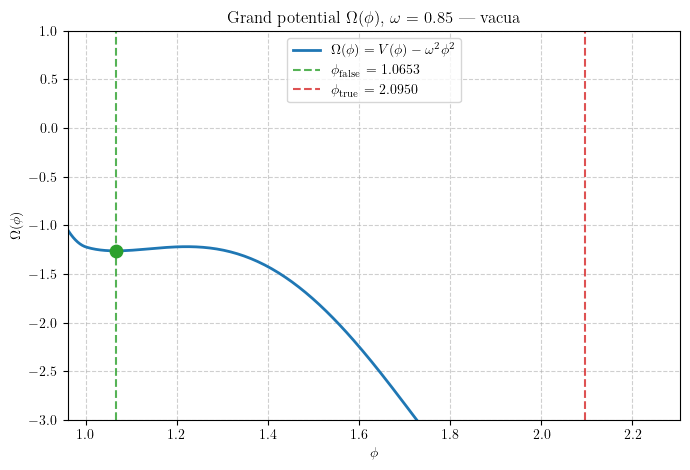

Solving O(3) bounce solution...
Parameters: φ₀=1.999, v1=1.0, v2=2.0, ω=0.85
Analytical action (d=4, Q=0): S₀ = 80.590466
[vacua_of_Omega] ω=0.85
  phi_false=1.06503877578  Ω_false=-1.2608862793  dΩ=-5.29e-08  (ω²-W)=2.48e-08  Ω''=1.244e+01
  phi_true =2.09465574669  Ω_true =-4.54571225238  dΩ=-3.65e-07  (ω²-W)=8.71e-08  Ω''=4.175e+01
Vacua of Ω: phi_false=1.0650387758, phi_true=2.0946557467
  Iteration 0: Undershoot, φ(0)=1.579847, φ(∞)=1.123602, r_stop=1.4118
  Iteration 10: Undershoot, φ(0)=1.667827, φ(∞)=1.066543, r_stop=2.2136
  Iteration 20: Undershoot, φ(0)=1.668004, φ(∞)=1.065053, r_stop=3.3910
  Converged after 27 iterations: φ(0)=1.668005, φ(∞)=1.065041, φ'(∞)=2.711e-20

Bounce solution found:
  φ(0) = 1.668005
  φ(∞) ≈ 1.065041 (target false = 1.065039)
  r_max = 3.85
  Number of points: 1000
  phi range: [1.065041, 1.668005]


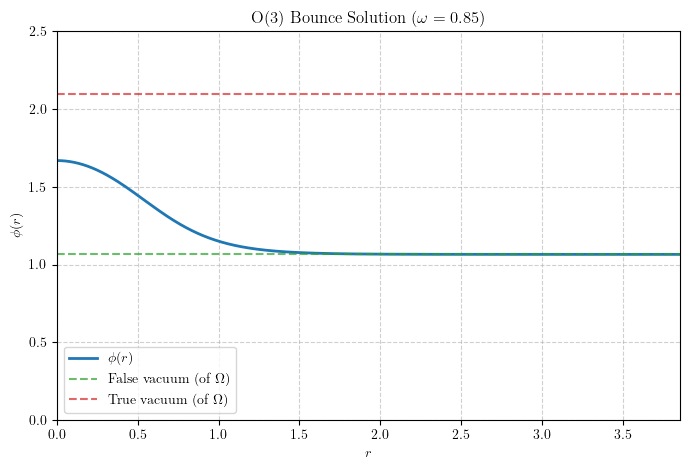

In [3]:
# ============================================================================
# 1D Bounce: parameters, vacua (grid), plot Ω(φ), solve (solve_bounce from bounce_1d)
# ============================================================================

# Parameters
PHI0_BOUNCE = PHI0
V1_BOUNCE = V1
V2_BOUNCE = V2
OMEGA_BOUNCE = OMEGA
D = 3
R0 = 1e-11
RMAX = 10.0
MAX_ITER = 100
VERBOSE = True

# Find vacua of Ω(φ) = V(φ) - ω²φ² using efficient grid method (two grids, then assign false/true by Ω)
phi_grid1 = np.linspace(max(0.5, V1_BOUNCE - 0.2), min(V2_BOUNCE - 0.1, V1_BOUNCE + 0.2), 500)
phi_grid2 = np.linspace(max(V1_BOUNCE + 0.1, V2_BOUNCE - 0.2), V2_BOUNCE+0.2, 500)
Omega_grid1 = np.array([Omega_phi(phi, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE) for phi in phi_grid1])
Omega_grid2 = np.array([Omega_phi(phi, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE) for phi in phi_grid2])
idx_min1 = np.argmin(Omega_grid1)
idx_min2 = np.argmin(Omega_grid2)
phi_near_v1 = phi_grid1[idx_min1]
phi_near_v2 = phi_grid2[idx_min2]
Omega_near_v1 = Omega_phi(phi_near_v1, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE)
Omega_near_v2 = Omega_phi(phi_near_v2, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE)
if Omega_near_v1 > Omega_near_v2:
    phi_false_grid, phi_true_grid = phi_near_v1, phi_near_v2
    Omega_false_grid, Omega_true_grid = Omega_near_v1, Omega_near_v2
else:
    phi_false_grid, phi_true_grid = phi_near_v2, phi_near_v1
    Omega_false_grid, Omega_true_grid = Omega_near_v2, Omega_near_v1

# Plot Ω(φ) and mark the two minima to verify they correspond to the vacua
# Free range: no clipping; extend below v1 and especially above v2
phi_plot = np.linspace(0.5, 3.0, 500)
Omega_plot = np.array([Omega_phi(phi, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE) for phi in phi_plot])
fig, ax = plt.subplots(figsize=(7, 4.8))
ax.plot(phi_plot, Omega_plot, lw=2, color="C0", label=r"$\Omega(\phi) = V(\phi) - \omega^2\phi^2$")
ax.axvline(phi_false_grid, color="C2", ls="--", lw=1.5, label=rf"$\phi_{{\mathrm{{false}}}}$ = {phi_false_grid:.4f}", alpha=0.8)
ax.axvline(phi_true_grid, color="C3", ls="--", lw=1.5, label=rf"$\phi_{{\mathrm{{true}}}}$ = {phi_true_grid:.4f}", alpha=0.8)
ax.scatter([phi_false_grid], [Omega_false_grid], color="C2", s=80, zorder=5)
ax.scatter([phi_true_grid], [Omega_true_grid], color="C3", s=80, zorder=5)
ax.set_xlabel(r"$\phi$")
ax.set_ylabel(r"$\Omega(\phi)$")
ax.set_xlim(phi_false_grid*0.9, phi_true_grid*1.1)
ax.set_ylim(-3, 1.0)
ax.set_title(rf"Grand potential $\Omega(\phi)$, $\omega$ = {OMEGA_BOUNCE:.2f} — vacua")
ax.legend()
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

# Analytical Euclidean action for d=4, Q=0 (used for display only)
from scipy.special import spence
def S0_analytical(phi0):
    """S₀ = -π²/3 [φ₀ - 1 + Li₂((φ₀-1)/(φ₀-2))]; Li₂(z) = spence(1-z)."""
    term = (phi0 - 1) / (phi0 - 2)
    Li2_val = spence(1 - term)
    return -np.pi**2 / 3.0 * (phi0 - 1 + Li2_val)

# Solve bounce with chosen parameters
print("Solving O(3) bounce solution...")
print(f"Parameters: φ₀={PHI0_BOUNCE}, v1={V1_BOUNCE}, v2={V2_BOUNCE}, ω={OMEGA_BOUNCE}")
print(f"Analytical action (d=4, Q=0): S₀ = {S0_analytical(PHI0_BOUNCE):.6f}")
r_bounce, phi_bounce, phi0_bounce, phi_false_bounce, phi_true_bounce = solve_bounce(
    PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE, 
    d=D, r0=R0, rmax=RMAX, max_iter=MAX_ITER, verbose=VERBOSE
)

if r_bounce is not None:
    print(f"\nBounce solution found:")
    print(f"  φ(0) = {phi0_bounce:.6f}")
    print(f"  φ(∞) ≈ {phi_bounce[-1]:.6f} (target false = {phi_false_bounce:.6f})")
    print(f"  r_max = {r_bounce[-1]:.2f}")
    print(f"  Number of points: {len(r_bounce)}")
    print(f"  phi range: [{phi_bounce.min():.6f}, {phi_bounce.max():.6f}]")
    
    # Update phi_false and phi_true with analytical values
    phi_false = phi_false_grid
    phi_true = phi_true_grid
    
    # Plot bounce solution
    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.plot(r_bounce, phi_bounce, lw=2, color='C0', label=r"$\phi(r)$")
    ax.axhline(phi_false, color='C2', ls='--', lw=1.5, label=rf"False vacuum (of $\Omega$)", alpha=0.7)
    ax.axhline(phi_true, color='C3', ls='--', lw=1.5, label=rf"True vacuum (of $\Omega$)", alpha=0.7)
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$\phi(r)$")
    ax.set_xlim(0, r_bounce[-1])
    ax.set_ylim(0, phi_bounce.max()*1.5)
    ax.set_title(rf"O(3) Bounce Solution ($\omega = {OMEGA_BOUNCE:.2f}$)")
    ax.legend()
    ax.grid(True, ls="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("Failed to find bounce solution.")

Solving O(3) bounce for ω=0 (bubble_zero_charge)...
[vacua_of_Omega] ω=0
  phi_false=1.00000001839  Ω_false=-0.5  dΩ=1.67e-06  (ω²-W)=-8.35e-07  Ω''=9.636e+05
  phi_true =1.99986461045  Ω_true =-1.50000001833  dΩ=-4.20e-08  (ω²-W)=1.05e-08  Ω''=4.001e+00
Vacua of Ω: phi_false=1.0000000184, phi_true=1.9998646105
  Iteration 0: Undershoot, φ(0)=1.499932, φ(∞)=1.336373, r_stop=1.1604
  Iteration 10: Overshoot, φ(0)=1.995471, φ(∞)=1.000000, r_stop=2.5341
  Iteration 20: Undershoot, φ(0)=1.995052, φ(∞)=1.000242, r_stop=3.1309
  Converged after 27 iterations: φ(0)=1.995052, φ(∞)=1.000000, φ'(∞)=-2.497e-04
  φ(0) = 1.995052, r_max = 3.37, N = 1000


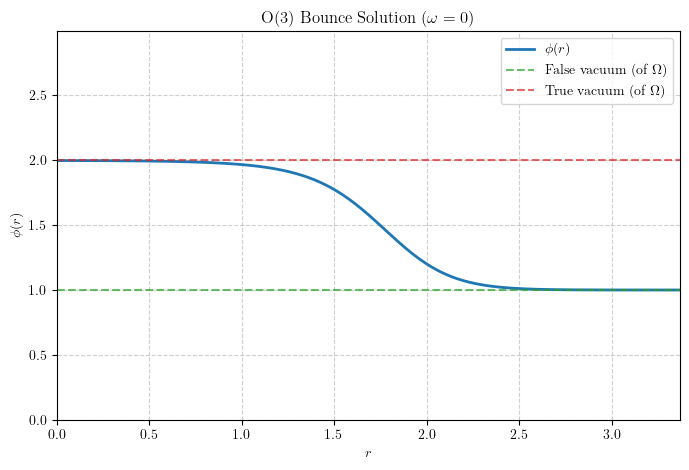

In [4]:
# Bounce for ω=0 (zero charge): same potential, omega=0 → Ω(φ)=V(φ)
print("Solving O(3) bounce for ω=0 (bubble_zero_charge)...")
r_bubble_zero_charge, phi_bubble_zero_charge, phi0_bzc, phi_false_bzc, phi_true_bzc = solve_bounce(
    PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, 0.0,
    d=D, r0=1e-6, rmax=RMAX, max_iter=MAX_ITER, verbose=VERBOSE
)
if r_bubble_zero_charge is not None:
    print(f"  φ(0) = {phi0_bzc:.6f}, r_max = {r_bubble_zero_charge[-1]:.2f}, N = {len(r_bubble_zero_charge)}")
    fig, ax = plt.subplots(figsize=(7, 4.8))
    ax.plot(r_bubble_zero_charge, phi_bubble_zero_charge, lw=2, color="C0", label=r"$\phi(r)$")
    ax.axhline(phi_false_bzc, color="C2", ls="--", lw=1.5, label=rf"False vacuum (of $\Omega$)", alpha=0.7)
    ax.axhline(phi_true_bzc, color="C3", ls="--", lw=1.5, label=rf"True vacuum (of $\Omega$)", alpha=0.7)
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$\phi(r)$")
    ax.set_xlim(0, r_bubble_zero_charge[-1])
    ax.set_ylim(0, phi_bubble_zero_charge.max() * 1.5)
    ax.set_title(r"O(3) Bounce Solution ($\omega = 0$)")
    ax.legend()
    ax.grid(True, ls="--", alpha=0.6)
    plt.tight_layout()
    plt.show()
else:
    print("  Failed to find bounce for ω=0.")

## 1b. Homogeneous configuration and charge-matched bubble

We fix the **reference volume** to a ball of radius $r_{\mathrm{max}}$ (in the code this can be set to a fixed value, e.g. $10$, or to the bounce domain boundary, $r_{\mathrm{max}} = r_{\mathrm{bounce}}[-1]$). Then:

1. **Homogeneous configuration** at the same chemical potential $\omega$: $\phi = \phi_{\mathrm{false}}(\omega)$ constant. The charge on the ball $[0, r_{\mathrm{max}}]$ is
   $$Q_{\mathrm{hom}} = 4\pi\,\omega\,\phi_{\mathrm{false}}^2\,\frac{r_{\mathrm{max}}^3}{3}\;.$$
   In the code: `Q_homogeneous_ball` from `observables_2d`.

2. **Bubble with the same charge**: we search for $\tilde{\omega}$ (generally $\tilde{\omega} < \omega$) such that the critical bubble at $\tilde{\omega}$, integrated over the **same** volume $[0, r_{\mathrm{max}}]$, has total charge $Q = Q_{\mathrm{hom}}$. The 1D profile is defined only up to some $r_{\mathrm{max}}^{\mathrm{bubble}}$; we apply a **volume correction**: integrate the bubble from $0$ to $r_{\mathrm{max}}^{\mathrm{bubble}}$ and extend from $r_{\mathrm{max}}^{\mathrm{bubble}}$ to $r_{\mathrm{max}}$ with $\phi = \phi_{\mathrm{false}}(\tilde{\omega})$, so that the integral is over the same volume. Function used: `compute_charge_1d_volume_corrected`.


In [5]:
# ============================================================================
# Homogeneous charge at r_max = 10 and charge-matched bubble (volume-corrected)
# ============================================================================

from scipy.optimize import root_scalar
from Bubble_finder.observables_2d import (
    Q_homogeneous_ball,
    compute_charge_1d_volume_corrected,
    compute_energy,
)

R_MAX_REF = r_bounce[-1]#10.0   # reference volume: ball of radius r_max = 10
V_ref = (4.0 / 3.0) * np.pi * R_MAX_REF**3

# 1) Homogeneous configuration at omega = OMEGA (same as bounce)
phi_false_omega = phi_false_bounce   # from section 1 (vacuum of Omega at OMEGA)
Q_hom = Q_homogeneous_ball(OMEGA, phi_false_omega, R_MAX_REF)
E_hom = 0.0   # (1/2)(dφ/dr)² = 0 and Ω(φ) − Ω(φ_false) = 0 for uniform φ = φ_false, so E_hom = 0 if computed)
rho_Q_hom = Q_hom / V_ref
rho_E_hom = E_hom / V_ref
print(f"Reference volume: r_max = {R_MAX_REF}, V = {V_ref:.6f}")
print(f"Homogeneous config (omega = {OMEGA}): phi_false = {phi_false_omega:.6f}, Q_hom = {Q_hom:.6f}, E_hom = {E_hom:.6f}")
print(f"  Densities: Q/V = {rho_Q_hom:.6f}, E/V = {rho_E_hom:.6f}")

def Q_bubble_at_omega_tilde(omega_tilde):
    """Charge of the critical bubble at omega_tilde, integrated on [0, R_MAX_REF] with volume correction."""
    r_b, phi_b, _, phi_false_t, _ = solve_bounce(
        PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, omega_tilde,
        d=D, r0=R0, rmax=max(RMAX, R_MAX_REF), max_iter=MAX_ITER, verbose=False
    )
    if r_b is None:
        return np.nan
    return compute_charge_1d_volume_corrected(r_b, phi_b, omega_tilde, R_MAX_REF, phi_false_t)

# 2) Find omega_tilde such that Q_bubble(omega_tilde) = Q_hom (omega_tilde typically < OMEGA)
omega_lo = 0.01   # lower bound: bounce must exist
omega_hi = OMEGA
try:
    res_Q = root_scalar(lambda w: Q_bubble_at_omega_tilde(w) - Q_hom, bracket=[omega_lo, omega_hi], method='brentq')
    omega_tilde = res_Q.root
except ValueError:
    # If bracket fails (e.g. Q(omega_lo) > Q_hom), try narrower bracket
    omega_lo = 0.5
    res_Q = root_scalar(lambda w: Q_bubble_at_omega_tilde(w) - Q_hom, bracket=[omega_lo, omega_hi], method='brentq')
    omega_tilde = res_Q.root

# Recompute bubble at omega_tilde for later use
r_bubble_Q, phi_bubble_Q, phi0_bubble_Q, phi_false_tilde, phi_true_tilde = solve_bounce(
    PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, omega_tilde,
    d=D, r0=R0, rmax=max(RMAX, R_MAX_REF), max_iter=MAX_ITER, verbose=False
)
Q_bubble_corrected = compute_charge_1d_volume_corrected(r_bubble_Q, phi_bubble_Q, omega_tilde, R_MAX_REF, phi_false_tilde)
E_bubble = compute_energy(
    r_bubble_Q, phi_bubble_Q,
    PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, omega_tilde, phi_false_tilde
)
rho_Q_bubble = Q_bubble_corrected / V_ref
rho_E_bubble = E_bubble / V_ref

print(f"\nCharge-matched bubble:")
print(f"  omega_tilde = {omega_tilde:.6f}  ( < omega = {OMEGA} )")
print(f"  Q_bubble (volume-corrected to r_max={R_MAX_REF}) = {Q_bubble_corrected:.6f}")
print(f"  E_bubble = {E_bubble:.6f}")
print(f"  Densities (same volume V): Q/V = {rho_Q_bubble:.6f}, E/V = {rho_E_bubble:.6f}")
print(f"  Q_hom = {Q_hom:.6f}  (match: |Q_bubble - Q_hom| = {abs(Q_bubble_corrected - Q_hom):.2e})")
print(f"  Bubble r_max = {r_bubble_Q[-1]:.4f}")
rho_hom = float(phi_false_omega)
phi_bubble_at_rmax = float(np.interp(R_MAX_REF, r_bubble_Q, phi_bubble_Q))
print(f"  rho_hom = {rho_hom:.6f}")
print(f"  1D bubble at r = r_max (= {R_MAX_REF}): phi = {phi_bubble_at_rmax:.6f}")

OMEGA = OMEGA
OMEGA_TILDE = omega_tilde

Reference volume: r_max = 3.8532050930721704, V = 239.637614
Homogeneous config (omega = 0.85): phi_false = 1.065039, Q_hom = 231.049350, E_hom = 0.000000
  Densities: Q/V = 0.964161, E/V = 0.000000

Charge-matched bubble:
  omega_tilde = 0.843154  ( < omega = 0.85 )
  Q_bubble (volume-corrected to r_max=3.8532050930721704) = 231.049522
  E_bubble = 0.563286
  Densities (same volume V): Q/V = 0.964162, E/V = 0.002351
  Q_hom = 231.049350  (match: |Q_bubble - Q_hom| = 1.71e-04)
  Bubble r_max = 3.5782
  rho_hom = 1.065039
  1D bubble at r = r_max (= 3.8532050930721704): phi = 1.063097


## 2. Energy and charge of the 1D bubble

From the 1D profile $\phi_{\mathrm{cb}}(r)$ we extract the **energy** $E$ and **charge** $Q$ of the configuration.

In the grand-canonical ensemble the energy is (schematically)
$$
E[\phi] = 4\pi \int_0^{\infty} \mathrm{d}r\, r^2\left[\tfrac12 (\partial_r \phi)^2 + \Omega(\phi) - \Omega(\phi_\text{false})\right] \,,
$$
with $\Omega(\phi)$ the grand potential and $\phi_\text{false}$ the metastable minimum. The conserved charge associated with $\omega$ is
$$
Q[\phi] \propto 4\pi \int_0^{\infty} \mathrm{d}r\, r^2\, \phi^2(r) \, .
$$

**Implementation:** we use the functions in `Bubble_finder.observables_2d`: `compute_energy`, `compute_charge`, `compute_energy_density` (and charge analogues), with the same potentials as the 2D solver; radial integrals are evaluated with Simpson's rule to obtain $E$, $Q$ and the densities for the 1D bounce.


In [6]:
# ============================================================================
# Compute Energy and Charge (1D bounce — from observables_2d)
# ============================================================================

from Bubble_finder.observables_2d import (
    compute_energy,
    compute_charge,
    compute_energy_density,
    compute_charge_density,
)

if r_bounce is not None:
    # Use the bounce parameters
    E_bounce = compute_energy(r_bounce, phi_bounce, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE, phi_false_bounce)
    Q_bounce = compute_charge(r_bounce, phi_bounce, OMEGA_BOUNCE)
    rho_E_bounce = compute_energy_density(r_bounce, phi_bounce, PHI0_BOUNCE, V1_BOUNCE, V2_BOUNCE, OMEGA_BOUNCE, phi_false_bounce)
    rho_Q_bounce = compute_charge_density(r_bounce, phi_bounce, OMEGA_BOUNCE)
    
    print(f"Bounce solution observables:")
    print(f"  Energy: E = {E_bounce:.6f}")
    print(f"  Charge: Q = {Q_bounce:.6f}")
    print(f"  E/Q = {E_bounce/Q_bounce:.6f}")
    print(f"  Energy density: ρ_E = {rho_E_bounce:.6f}")
    print(f"  Charge density: ρ_Q = {rho_Q_bounce:.6f}")

Bounce solution observables:
  Energy: E = 0.526609
  Charge: Q = 233.708585
  E/Q = 0.002253
  Energy density: ρ_E = 0.002198
  Charge density: ρ_Q = 0.975258


## 3. Negative mode around the 1D bubble

We now compute the **negative mode** $\xi(r)$ describing small fluctuations around the 1D critical bubble.

The fluctuation operator has the schematic form
$$
\mathcal{O} = -\frac{\mathrm{d}^2}{\mathrm{d} r^2} + V''\bigl(\phi_{\mathrm{cb}}(r)\bigr) \, ,
$$
and we impose Dirichlet boundary conditions on $u(r) = r\,\xi(r)$,
$$
u(r) = r\,\xi(r) \quad \Rightarrow \quad u(0) = 0 , \quad u(r_{\max}) = 0 \, ,
$$
so that the mode is regular at the origin and vanishes at the numerical boundary.

Si usa la funzione **`compute_negative_mode_from_bounce`** in `Bubble_finder.ansatz_bubble`: it returns the lowest (negative) eigenvalue and the eigenfunction $\xi(r)$, which are then used to build the 2D ansätze in Euclidean $(r,\tau)$ space. Optionally, the $\gamma$ shooting can be checked with **`compute_Dp_shooting_1d`** and **`plot_Dp_shooting_verification`** (following diagnostic cell).


Negative mode (2-component) computed:
  Radial range: r in [0.0000, 3.2315] (R_MIN_NEG=0.0, R_MAX_NEG=None)
  xi_y[0], xi_ybar[0] = 0.000000e+00, 0.000000e+00  (both ~0 for regularity)
  (For real field phi=phibar we have y1d=ybar1d so xi_y and xi_ybar can coincide.)
  lambda = -9.946769e+00
  gamma = sqrt(-lambda) = 3.153850e+00
  beta_natural = 2*pi/gamma = 1.992227e+00


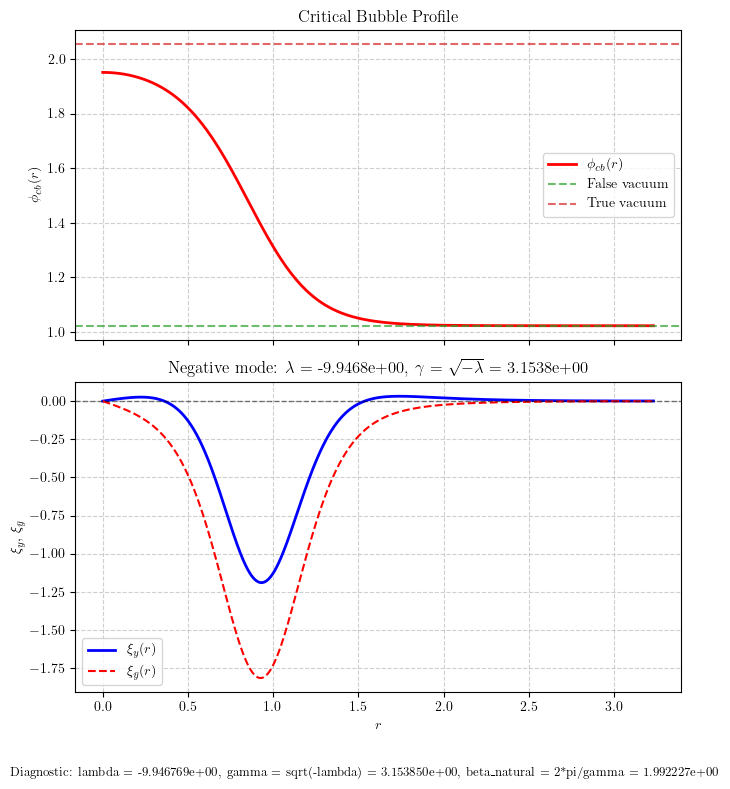

In [30]:
# ============================================================================
# Compute Negative Mode Around Critical Bubble (centralized in ansatz_bubble)
# ============================================================================

from Bubble_finder.ansatz_bubble import (
    compute_negative_mode_from_bounce,
    compute_Dp_shooting_1d,
    prepare_negative_mode_region,
)

# Radial range for negative-mode calculation (None = use full 1D profile)
R_MIN_NEG = 0.0
R_MAX_NEG = None

unstable_mode = None
beta_natural = 40.0

if r_bounce is not None and phi_bounce is not None:
    try:
        unstable_mode = compute_negative_mode_from_bounce(
            r_bounce, phi_bounce, phi_false_bounce, U, dU, d2U, OMEGA_TILDE,
            r_min=R_MIN_NEG, r_max=R_MAX_NEG,
            gamma_scan_neg=(0.01, 5.0), n_scan_neg=80,
            gamma_scan_dp=(0.01, 10.0), n_scan_dp=80,
            sign_convention=1,
        )
        beta_natural = unstable_mode.beta_natural
    except RuntimeError as e:
        if "Could not bracket" in str(e):
            r, phi_slice, potential_1d, dr, phi_false = prepare_negative_mode_region(
                r_bounce, phi_bounce, phi_false_bounce, U, dU, d2U,
                r_min=R_MIN_NEG, r_max=R_MAX_NEG,
            )
            result_dp_diag = compute_Dp_shooting_1d(
                r=r, phi=phi_slice, phibar=phi_slice, potential=potential_1d, omega=OMEGA,
                gamma_scan=(0.01, 5), n_scan=80, require_bracket=False,
            )
            gg = result_dp_diag["gamma_grid"]
            Dp = result_dp_diag["Dp_vals"]
            fig_d, ax_d = plt.subplots(1, 1, figsize=(8, 4))
            ax_d.plot(gg, Dp, 'o-', lw=1, ms=3, label=r'$D_p(\gamma)$')
            ax_d.axhline(0, color='k', ls='--', lw=1)
            ax_d.set_xlabel(r'$\gamma$')
            ax_d.set_ylabel(r'$D_p(\gamma)$')
            ax_d.set_title('Diagnostic: D_p(γ) shooting (no sign change found in range)')
            ax_d.grid(True, alpha=0.5)
            plt.tight_layout()
            plt.show()
            print("D_p scan: γ in [%.4f, %.4f]; min(Dp)=%.4e, max(Dp)=%.4e" % (gg[0], gg[-1], np.min(Dp), np.max(Dp)))
        raise

    # Print and plot
    r = unstable_mode.r
    xi_y, xi_ybar = unstable_mode.xi_y, unstable_mode.xi_ybar
    lam_neg, gamma = unstable_mode.lam_neg, unstable_mode.gamma
    print("Negative mode (2-component) computed:")
    print(f"  Radial range: r in [{r[0]:.4f}, {r[-1]:.4f}] (R_MIN_NEG={R_MIN_NEG}, R_MAX_NEG={R_MAX_NEG})")
    print(f"  xi_y[0], xi_ybar[0] = {xi_y[0]:.6e}, {xi_ybar[0]:.6e}  (both ~0 for regularity)")
    print(f"  (For real field phi=phibar we have y1d=ybar1d so xi_y and xi_ybar can coincide.)")
    print(f"  lambda = {lam_neg:.6e}")
    print(f"  gamma = sqrt(-lambda) = {gamma:.6e}")
    print(f"  beta_natural = 2*pi/gamma = {beta_natural:.6e}")
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 8), sharex=True)
    ax1.plot(r_bounce, phi_bounce, 'r-', lw=2, label=r"$\phi_{cb}(r)$")
    ax1.axhline(phi_false_bounce, color='C2', ls='--', lw=1.5, label="False vacuum", alpha=0.7)
    ax1.axhline(phi_true_bounce if 'phi_true_bounce' in globals() else phi_bounce[0],
                color='C3', ls='--', lw=1.5, label="True vacuum", alpha=0.7)
    ax1.set_ylabel(r"$\phi_{cb}(r)$")
    ax1.set_title("Critical Bubble Profile")
    ax1.legend()
    ax1.grid(True, ls="--", alpha=0.6)
    ax2.plot(r, xi_y, 'b-', lw=2, label=r"$\xi_y(r)$")
    ax2.plot(r, xi_ybar, 'r--', lw=1.5, label=r"$\xi_{\bar{y}}(r)$")
    ax2.axhline(0, color='k', ls='--', lw=1, alpha=0.5)
    ax2.set_xlabel(r"$r$")
    ax2.set_ylabel(r"$\xi_y$, $\xi_{\bar{y}}$")
    ax2.set_title(rf"Negative mode: $\lambda$ = {lam_neg:.4e}, $\gamma$ = $\sqrt{{-\lambda}}$ = {gamma:.4e}")
    ax2.legend()
    ax2.grid(True, ls="--", alpha=0.6)
    fig.text(0.02, 0.02, f"Diagnostic: lambda = {lam_neg:.6e}, gamma = sqrt(-lambda) = {gamma:.6e}, beta_natural = 2*pi/gamma = {beta_natural:.6e}", fontsize=9, verticalalignment='bottom')
    plt.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()
else:
    print("Negative mode: run the 1D bounce cell first (r_bounce, phi_bounce required).")


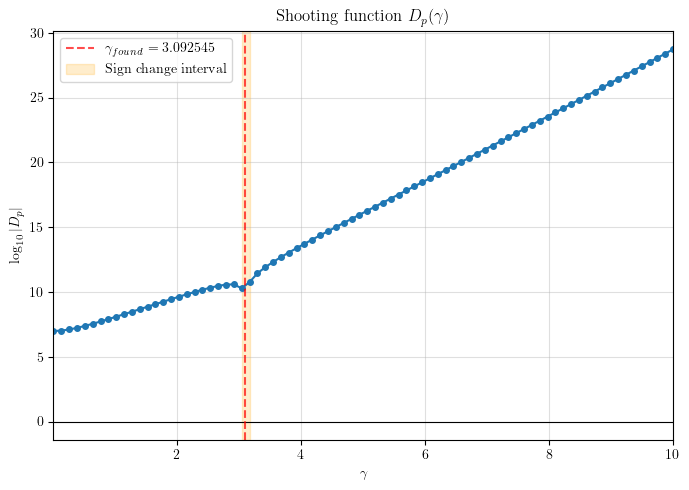


Shooting function verification:
  Found γ = 3.092545
  Sign change bracket: [3.044937, 3.171392]
  γ is within bracket: True
  D_p(γ_found) ≈ 9.734435e+09
  |D_p(γ_found)| < 1e-3: False


In [7]:
# Diagnostic: gamma from negative mode (and optional D_p shooting if available)
# Run the cell above first (negative mode) to get unstable_mode; then this cell shows gamma (or D_p curve).

from Bubble_finder.ansatz_bubble import plot_Dp_shooting_verification

plot_Dp_shooting_verification(unstable_mode, show_plot=True)

## 4. Two-dimensional ansätze: gallery

**Ansatz gallery:** we build several **non-oscillatory** ansatz families (the same ones used in the section 5 scan) with fixed parameters and compare them visually. **Twisted BC** only; no oscillatory kick from the negative mode.

**What the code does:** we use `build_tau_independent_embedding` to embed the 1D profile into the 2D $(r,\tau)$ grid and `residual_report_compact` to report residual norms. The heatmaps and slices (e.g. $\rho(r\!=\!r_{\max},\tau)$ and $\rho(r\!=\!0,\tau)$) show the temporal dependence of each ansatz at the boundary and at the centre.



In [7]:
# ============================================================================
# Section 4: Ansatz gallery — non-oscillatory families with diagnostics
# ============================================================================
# Uses: omega_tilde, r_bubble_Q, phi_bubble_Q, rho_hom from "Homogeneous charge".
# Twisted BC only. No oscillatory exp(±iγτ) kick.

from Bubble_finder.diagnostics_sanity import build_tau_independent_embedding, residual_report_compact
from Bubble_finder.ansatz_bubble import (
    AnsatzParams, build_seed_bubble, build_twisted_seed_from_static,
    make_q_ball_objects, make_bubble_profile_1d_from_arrays,
)
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver
from Q_ball_finder.grid import build_grid

NR_DEFAULT = 80
NTAU_DEFAULT = 100
# Use same radial extent as reference volume (section 1b) so Q_target == Q_hom
Lr_sel = float(R_MAX_REF)
beta_sel = 20
rho0_s4 = float(rho_hom)
r_1d_s4 = np.asarray(r_bubble_Q, float)
phi_1d_s4 = np.asarray(phi_bubble_Q, float)

settings_s4 = Bubble2DSettings(
    Nr=NR_DEFAULT, Ntau=NTAU_DEFAULT, Lr=Lr_sel, beta=beta_sel,
    omega_ref=OMEGA, rho0=rho0_s4, rho0_bracket=(1.0, 1.1),
    newton_tol=1e-8, newton_max_iter=35, damping=0.5,
    newton_verbose=False, tau_bc="twisted",
)
solver_s4 = Bubble2DSolver(settings_s4, U, dU, d2U)
solver_s4.omega = OMEGA
solver_s4.rho0 = rho0_s4
grid2d, fields, potential, _, _ = make_q_ball_objects(solver_s4)
grid_2d = build_grid(Nr=NR_DEFAULT, Ntau=NTAU_DEFAULT, Lr=Lr_sel, beta=beta_sel)
bubble_profile_1d = make_bubble_profile_1d_from_arrays(r_1d_s4, phi_1d_s4)

def _eval_ansatz(solver, x0, name=""):
    """Residual norms, tau_std_rho from rho=sqrt(Re(phi_rot*phibar_rot)), boundary flag."""
    rep = residual_report_compact(solver, x0, name=name)
    j_max, i_max = rep.get("j_max", 0), rep.get("i_max", 0)
    at_boundary = (j_max == 0 or j_max == solver.Nr - 1 or i_max == 0 or i_max == solver.Nt - 1)
    rep["at_boundary"] = at_boundary
    y, ybar = solver.unpack(x0)
    phi_rot, phibar_rot = solver.phi_rot(y, ybar)
    u = np.maximum((phi_rot * phibar_rot).real, 0.0)
    rho = np.sqrt(u)
    rep["tau_std_rho"] = float(np.max(np.std(rho, axis=1))) if rho.size > 0 else 0.0
    rep["rho"] = rho
    rep["x0"] = x0
    return rep

# Build tau bump for twisted_from_static (localized near tau~0)
Nr, Nt = solver_s4.Nr, solver_s4.Nt
r_arr = np.asarray(solver_s4.grid.r, float)
tau_arr = np.asarray(solver_s4.grid.tau, float)
rr = np.asarray(r_arr, float).reshape(-1, 1)  # (Nr, 1)
tt = np.asarray(tau_arr, float).reshape(1, -1)  # (1, Nt)
sigma_r, sigma_tau = 2.0, 0.15 * max(abs(tau_arr[-1] - tau_arr[0]), 0.1)
r_c, tau_c = float(np.median(rr)), float(tau_arr[0])
bump = np.exp(-((rr - r_c)**2) / (2*sigma_r**2)) * np.exp(-((tt - tau_c)**2) / (2*sigma_tau**2))
bump_y = rr * bump
bump_ybar = -0.5 * bump_y.copy()
seed_tau_bump = (bump_y, bump_ybar)

# ANSATZ_FAMILIES: non-oscillatory (static, twisted_from_static, gated_bubble)
gallery = []

# 1) Static embedded
x_static = build_tau_independent_embedding(solver_s4, r_1d_s4, phi_1d_s4, rho0_s4)
rep = _eval_ansatz(solver_s4, x_static, "static_embedded")
rep["name"] = "static_embedded"
rep["params"] = {}
gallery.append(rep)

# 2) Twisted from static (tau bump, a=0.05)
x_tw = build_twisted_seed_from_static(solver=solver_s4, r_1d=r_1d_s4, phi_1d=phi_1d_s4, rho0=rho0_s4,
    a=0.05, seed_tau_bump=seed_tau_bump)
rep = _eval_ansatz(solver_s4, x_tw, "twisted_from_static")
rep["name"] = "twisted_from_static"
rep["params"] = {"a": 0.05}
gallery.append(rep)

# 3) Gated bubble (build_seed_bubble with eps=0; no oscillatory kick)
# tau_gate_center_frac: 0 = τ_min (-β/2), 1 = τ_max (0), 0.5 = middle. Set to choose where the r=0 slice evolves.
params_gated = AnsatzParams(eps=1.0, k=1, phase=0.0, amp=1.0, tau_gate_frac=0.25, tau_gate_center_frac=1, r_window_frac=0.15)
neg_mode_dummy = (np.zeros_like(fields.grid.r), np.zeros_like(fields.grid.r), 0.0)
try:
    x0_g, _ = build_seed_bubble(
        grid=fields.grid, fields=fields, potential=potential,
        omega_ref=OMEGA, omega_tilde=omega_tilde,
        bubble_profile_1d=bubble_profile_1d, params=params_gated,
        neg_mode_override=neg_mode_dummy,
    )
    rep = _eval_ansatz(solver_s4, x0_g, "gated_bubble")
    rep["name"] = "gated_bubble"
    rep["params"] = {"amp": 1.0, "tau_gate_frac": 0.15}
    gallery.append(rep)
except Exception as e:
    print(f"gated_bubble build failed: {e}")

# Sort by nF_inf for summary
gallery.sort(key=lambda g: g["nF_inf"])
print("Ansatz gallery built. Summary (by ||F||_inf):")
for g in gallery:
    print(f"  {g['name']:<22} ||F||_inf={g['nF_inf']:.4e} tau_std_rho={g['tau_std_rho']:.4e} boundary={g['at_boundary']}")


Ansatz gallery built. Summary (by ||F||_inf):
  static_embedded        ||F||_inf=9.4652e-02 tau_std_rho=8.8818e-16 boundary=True
  gated_bubble           ||F||_inf=8.6550e-01 tau_std_rho=1.7122e-01 boundary=False
  twisted_from_static    ||F||_inf=2.1797e+01 tau_std_rho=3.7760e-03 boundary=True


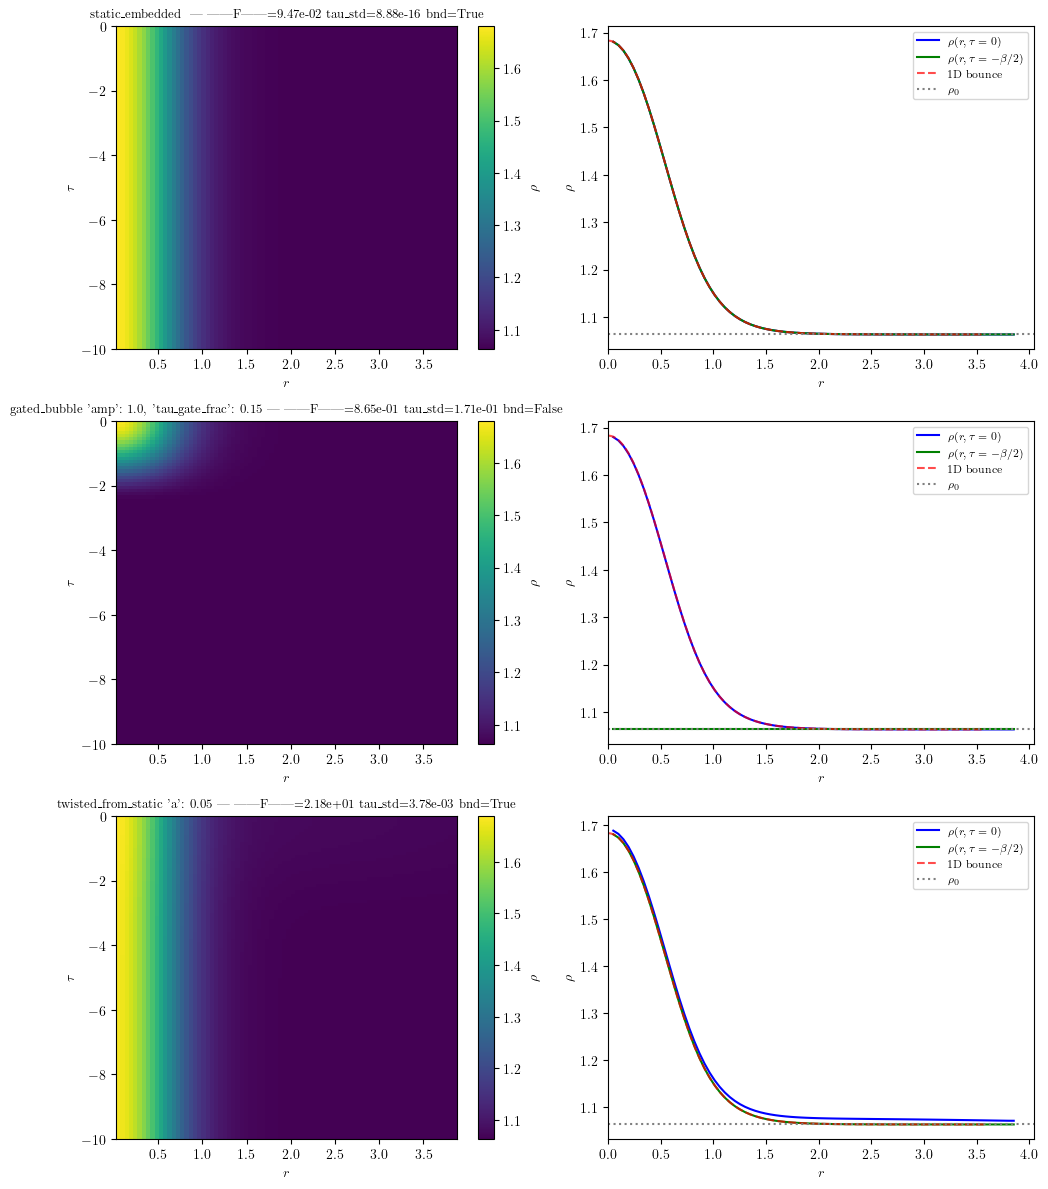


Ansatz gallery summary (sorted by ||F||_inf):
name                   params                      ||F||_inf ||F||_2/sqrt(N)  tau_std_rho boundary
static_embedded        {}                         9.4652e-02     3.9376e-02   8.8818e-16     True
gated_bubble           {'amp': 1.0, 'tau_gate     8.6550e-01     5.8984e-02   1.7122e-01    False
twisted_from_static    {'a': 0.05}                2.1797e+01     1.0190e+00   3.7760e-03     True


In [8]:
# Plot gallery: heatmap + slices for each ansatz
r_plot = np.asarray(solver_s4.grid.r, float)
tau_plot = np.asarray(solver_s4.grid.tau, float)
beta_s4 = float(solver_s4.settings.beta)
n_ansatz = len(gallery)
fig, axes = plt.subplots(n_ansatz, 2, figsize=(10, 4 * n_ansatz))
if n_ansatz == 1:
    axes = axes.reshape(1, -1)
for row, g in enumerate(gallery):
    rho_a = g["rho"]
    # Ansatz card
    card = f"{g['name']} {g['params']} | ||F||={g['nF_inf']:.2e} tau_std={g['tau_std_rho']:.2e} bnd={g['at_boundary']}"
    axes[row, 0].set_title(card, fontsize=9)
    im = axes[row, 0].pcolormesh(r_plot, tau_plot, rho_a.T, shading="auto", cmap="viridis")
    axes[row, 0].set_xlabel(r"$r$")
    axes[row, 0].set_ylabel(r"$\tau$")
    axes[row, 0].set_aspect("auto")
    plt.colorbar(im, ax=axes[row, 0], label=r"$\rho$")
    axes[row, 1].plot(r_plot, rho_a[:, 0], "b-", label=r"$\rho(r,\tau=0)$")
    axes[row, 1].plot(r_plot, rho_a[:, -1], "g-", label=r"$\rho(r,\tau=-\beta/2)$")
    axes[row, 1].plot(r_1d_s4, phi_1d_s4, "r--", alpha=0.7, label="1D bounce")
    axes[row, 1].axhline(rho0_s4, color="gray", ls=":", label=r"$\rho_0$")
    axes[row, 1].set_xlabel(r"$r$")
    axes[row, 1].set_ylabel(r"$\rho$")
    axes[row, 1].legend(fontsize=8)
    axes[row, 1].set_xlim(0, None)
plt.tight_layout()
plt.show()

# Summary table
print("\nAnsatz gallery summary (sorted by ||F||_inf):")
print(f"{'name':<22} {'params':<24} {'||F||_inf':>12} {'||F||_2/sqrt(N)':>14} {'tau_std_rho':>12} {'boundary':>8}")
for g in gallery:
    ps = str(g.get("params", {}))[:22]
    print(f"{g['name']:<22} {ps:<24} {g['nF_inf']:>12.4e} {g['nF_2_per_site']:>14.4e} {g['tau_std_rho']:>12.4e} {str(g['at_boundary']):>8}")


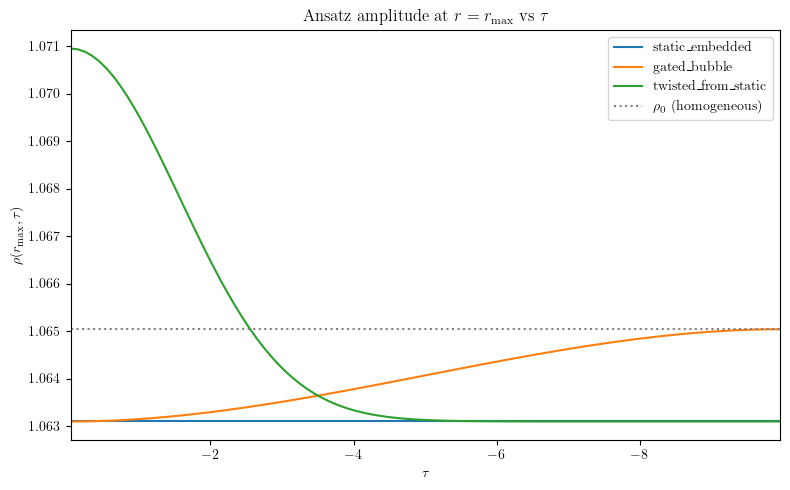

In [9]:
# ρ(r=r_max, τ) vs τ for each ansatz: temporal dependence at the boundary
tau_plot = np.asarray(solver_s4.grid.tau, float)
r_max = float(solver_s4.grid.r[-1])
fig, ax = plt.subplots(figsize=(8, 5))
for g in gallery:
    rho_at_rmax = g["rho"][-1, :]
    ax.plot(tau_plot, rho_at_rmax, lw=1.5, label=g["name"])
ax.axhline(rho0_s4, color="gray", ls=":", label=r"$\rho_0$ (homogeneous)")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$\rho(r_{\mathrm{max}}, \tau)$")
ax.set_title(r"Ansatz amplitude at $r=r_{\mathrm{max}}$ vs $\tau$")
ax.legend()
ax.set_xlim(tau_plot[0], tau_plot[-1])
plt.tight_layout()
plt.show()


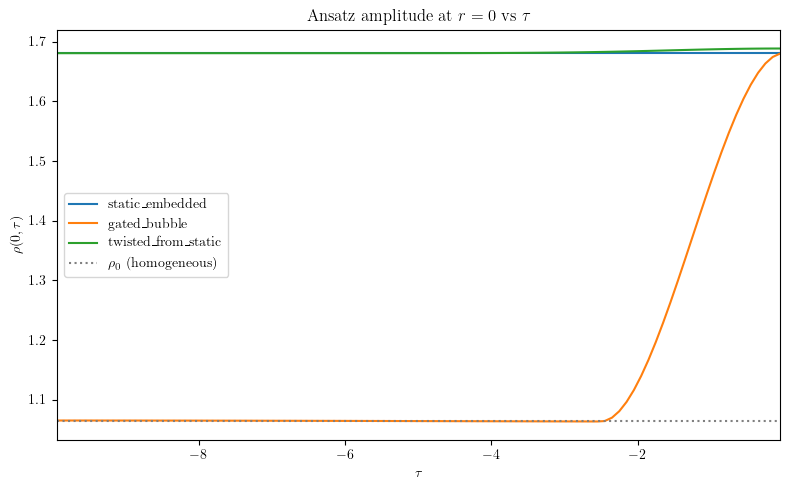

In [10]:
# ρ(r=0, τ) vs τ for each ansatz: temporal dependence at the center
tau_plot = np.asarray(solver_s4.grid.tau, float)
fig, ax = plt.subplots(figsize=(8, 5))
for g in gallery:
    rho_at_r0 = g["rho"][0, :]
    ax.plot(tau_plot, rho_at_r0, lw=1.5, label=g["name"])
ax.axhline(rho0_s4, color="gray", ls=":", label=r"$\rho_0$ (homogeneous)")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$\rho(0, \tau)$")
ax.set_title(r"Ansatz amplitude at $r=0$ vs $\tau$")
ax.legend()
ax.set_xlim(tau_plot.min(), tau_plot.max())  # τ from min to 0, left to right
plt.tight_layout()
plt.show()

## 2.1 Diagnostics: homogeneous background and $\tau$-independent bubble

Diagnostic checks before running Newton:

- **TASK A — Homogeneous background:** we verify that the configuration $y=\bar y=0$ (homogeneous) satisfies the equations and that $\rho_0$ is consistent with the boundary condition ($\rho_0$ from `rho0_from_homogeneous_condition`, residual with `build_background_zero_vec`).
- **TASK B — $\tau$-independent bubble:** we verify that the 2D embedding of the 1D bounce at $\eta_0=0$ is a solution of `Bubble2DSolver` (twisted BC). We use `build_tau_independent_embedding` and solve with Newton; the bulk vs boundary residual is compared with `bulk_vs_boundary_residual`.
- **Charge definition:** `charge_definition_report` and comparison between 2D charge (ghost at $\tau=0$) and 1D charge (`compute_charge_like_2d_from_1d`) for consistency.


In [11]:
# Second try: diagnostics — TASK A (background) and TASK B (tau-independent bubble @ eta=0)
# Checklist: A) potential convention, B) varphi=sqrt(s), C) background eq, D) eta0=0, E) r=0, F) Neumann, G) grid, H) norms, I) tau-indep
import numpy as np
from Bubble_finder.diagnostics_sanity import (
    rho0_from_homogeneous_condition,
    build_background_zero_vec,
    build_tau_independent_embedding,
    residual_report_compact,
    bulk_vs_boundary_residual,
    checklist_potential_convention,
    checklist_field_into_potential,
    checklist_eta0_for_tau_indep,
)
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver, solve_rho0_for_omega

# --- Build diagnostic solver (eta0=0 for tau-independent bubble check) ---
solver_diag = globals().get("solver_newton") or globals().get("solver_exist") or globals().get("solver")
if solver_diag is None and "grid_2d" in globals():
    Lr_ex = grid_2d.dr * grid_2d.Nr
    beta_ex = 2.0 * abs(grid_2d.tau[-1])
    Ntau_ex = getattr(grid_2d, "Ntau", len(grid_2d.tau))
    rho0_diag = float(solve_rho0_for_omega(OMEGA, dU, (1.0, 1.1)))
    settings_diag = Bubble2DSettings(
        Nr=grid_2d.Nr, Ntau=Ntau_ex, Lr=Lr_ex, beta=beta_ex,
        omega_ref=OMEGA, rho0=rho0_diag, rho0_bracket=(1.0, 1.1),
        newton_tol=1e-9, newton_max_iter=35, damping=0.5,
        tau_bc="twisted", complex_saddle=True, eta0=0.0,  # eta0=0 for tau-indep check
    )
    solver_diag = Bubble2DSolver(settings_diag, U, dU, d2U)
    solver_diag.omega = OMEGA
    solver_diag.rho0 = rho0_diag
    print("Diagnostic solver built from grid_2d (eta0=0)")
elif solver_diag is None:
    # Fallback: build minimal diagnostic grid from 1D bounce
    from Q_ball_finder.grid import build_grid
    _Nr, _Nt, _Lr, _beta = 80, 80, float(r_bounce[-1]) if "r_bounce" in globals() and r_bounce is not None else 25.0, 50.0
    if "r_bounce" in globals() and r_bounce is not None:
        _Lr = max(_Lr, float(np.max(r_bounce)) * 1.2)
    grid_2d = build_grid(_Nr, _Nt, _Lr, _beta)
    rho0_diag = float(solve_rho0_for_omega(OMEGA, dU, (1.0, 1.1)))
    settings_diag = Bubble2DSettings(
        Nr=grid_2d.Nr, Ntau=grid_2d.Ntau, Lr=grid_2d.dr * grid_2d.Nr, beta=2.0 * abs(grid_2d.tau[-1]),
        omega_ref=OMEGA, rho0=rho0_diag, rho0_bracket=(1.0, 1.1),
        newton_tol=1e-9, tau_bc="twisted", complex_saddle=True, eta0=0.0,
    )
    solver_diag = Bubble2DSolver(settings_diag, U, dU, d2U)
    solver_diag.rho0 = rho0_diag
    print("Diagnostic solver built from minimal grid (r_bounce)")
if solver_diag is None:
    raise NameError("Need solver_newton, solver_exist, solver, grid_2d, or r_bounce to build diagnostic solver")

# Override eta0=0 for tau-independent bubble verification (TASK B, checklist D)
from dataclasses import replace
prev_omega = getattr(solver_diag, "omega", OMEGA)
prev_rho0 = getattr(solver_diag, "rho0", solver_diag.settings.rho0)
settings_eta0 = replace(solver_diag.settings, eta0=0.0)
solver_diag = Bubble2DSolver(settings_eta0, U, dU, d2U)
solver_diag.omega = prev_omega
solver_diag.rho0 = prev_rho0
print("Diagnostic solver: eta0=0 (tau-independent bubble check)")

tau_arr = np.asarray(solver_diag.grid.tau, float)
r_arr = np.asarray(solver_diag.grid.r, float)
rho0 = float(solver_diag.rho0)


Diagnostic solver built from grid_2d (eta0=0)
Diagnostic solver: eta0=0 (tau-independent bubble check)


In [12]:
# ============================================================================
# PART 1 — Model identity report: 1D vs 2D equation comparison
# ============================================================================
from Bubble_finder.diagnostics_sanity import model_identity_report

phi0_pot = float(PHI0)  # potential parameter
v1_pot, v2_pot = float(V1), float(V2)
mi = model_identity_report(solver_diag, dU, d2U, phi0_pot, v1_pot, v2_pot)
print(mi["report"])

PART 1 — Model identity report (1D vs 2D)

(a) 2D PDE enforced by Bubble2DSolver.residual():
  - Variables: y = r*(phi_rot - rho0), ybar = r*(phibar_rot - rho0)
  - phi_rot = e^{-omega*tau}*phi, phibar_rot = e^{+omega*tau}*phibar
  - u = Re(phi_rot * phibar_rot) = Re((y_tot/r)*(ybar_tot/r)), y_tot = y + r*rho0
  - rho = sqrt(u_pos + rho_eps), u_pos = smooth_positive(u)
  - Potential: W(u) = dU(rho)/(2*rho), U(rho)=V(varphi) with varphi=rho
  - Scalar in potential: u = Re(phi_rot*phibar_rot), rho = sqrt(u)
  - Equation: Fy = y_tt + y_rr + 2*omega*y_t + (omega^2 - W)*y_tot

(b) Tau-independent (d/dtau=0), eta0=0 reduction of 2D PDE:
  - y_t=0, y_tt=0. For real phi_rot=phibar_rot: y=ybar, y_tot=r*phi.
  - y_rr = 2*phi' + r*phi'' (from y = r*(phi-rho0))
  - Fy = y_rr + A_coef*y_tot, A_coef = 2*(omega^2 - W) [FIXED for 1D match]
  - W = dU(rho)/(2*rho), so A_coef*phi = 2*omega^2*phi - dV_dphi
  - REDUCED 2D (fixed): phi'' + 2*phi'/r + 2*omega^2*phi - dV_dphi(phi) = 0

(c) ODE solved by solv

In [13]:
# ============================================================================
# TASK B — Tau-independent bubble solution @ eta=0
# ============================================================================
# Verify that embedding the 1D bounce into 2D gives a solution of Bubble2DSolver when eta=0.
print("\n" + "=" * 70)
print("Tau-independent bubble check")
print("=" * 70)

# (1) Load 1D bounce profile — MUST use same omega as solver for embedding to be a solution
omega_ref = float(getattr(solver_diag, "omega", OMEGA))
phi0_1d = float(PHI0_BOUNCE) if "PHI0_BOUNCE" in globals() else PHI0
v1_1d = float(V1_BOUNCE) if "V1_BOUNCE" in globals() else V1
v2_1d = float(V2_BOUNCE) if "V2_BOUNCE" in globals() else V2
r_max_2d = float(solver_diag.grid.r[-1]) if len(solver_diag.grid.r) > 0 else None
r_1d, phi_1d, _, _, _ = solve_bounce(phi0_1d, v1_1d, v2_1d, omega_ref, verbose=False, extend_to=r_max_2d)
if r_1d is None or phi_1d is None:
    raise RuntimeError("solve_bounce failed for omega_ref=%s. Check potential parameters." % omega_ref)
phi_1d = np.asarray(phi_1d, float)
r_1d = np.asarray(r_1d, float)
print(f"  1D profile: solve_bounce(omega={omega_ref:.6f}), varphi range [{phi_1d.min():.6f}, {phi_1d.max():.6f}]")

# (2) Embed 1D as tau-independent 2D: phi_rot(r,tau)=varphi_1d(r), phibar_rot=phi_rot
x_seed_embed = build_tau_independent_embedding(solver_diag, r_1d, phi_1d, rho0)

# (3) Evaluate residual WITHOUT Newton
rep_embed = residual_report_compact(solver_diag, x_seed_embed, name="embedded_1d")
print(f"\n  Residual on embedded 1D (no Newton):")
print(f"    ||F||_inf = {rep_embed['nF_inf']:.6e}")
print(f"    ||F||_2 / sqrt(sites) = {rep_embed['nF_2_per_site']:.6e}")
print(f"    max at j={rep_embed['j_max']}, i={rep_embed['i_max']} (r={rep_embed['r_at_max']:.4f}, tau={rep_embed['tau_at_max']:.4f})")

# Composite criterion: PASS if residual tiny OR (residual acceptable AND bulk/boundary comparable)
# Embedded residual is limited by 1D->2D interpolation and grid discretization (~1e-2 typically).
dec_embed = bulk_vs_boundary_residual(solver_diag, x_seed_embed)
ratio_bulk_bound = dec_embed["max_boundary"] / (dec_embed["max_bulk"] + 1e-30)
TOL_EMBED_TIGHT = 1e-6
TOL_EMBED_LOOSE = 0.1   # discretization/interpolation typically gives ||F|| ~ 1e-2 to few e-2
embed_residual_ok = (
    rep_embed["nF_inf"] < TOL_EMBED_TIGHT
    or (rep_embed["nF_inf"] < TOL_EMBED_LOOSE and 0.3 < ratio_bulk_bound < 3.0)
)
if embed_residual_ok:
    if rep_embed["nF_inf"] < TOL_EMBED_TIGHT:
        print(f"  --> PASS (embedded residual < {TOL_EMBED_TIGHT})")
    else:
        print(f"  --> PASS (embedded residual {rep_embed['nF_inf']:.2e} < {TOL_EMBED_LOOSE}, bulk/boundary ratio {ratio_bulk_bound:.2f} ~ 1)")
else:
    at_boundary = (rep_embed["j_max"] == 0 or rep_embed["j_max"] == solver_diag.Nr - 1 or
                   rep_embed["i_max"] == 0 or rep_embed["i_max"] == solver_diag.Nt - 1)
    print(f"  --> FAIL (residual >= {TOL_EMBED_LOOSE} or bulk/boundary mismatch). Max at boundary={at_boundary}.")
    print("  Debug: Check A) potential convention, F) Neumann BC, G) grid match. Running Newton refinement...")

# (4) Optional Newton refinement
try:
    from Bubble_finder.bounce2d import NewtonConvergenceError
except Exception:
    NewtonConvergenceError = RuntimeError
result_embed = None
try:
    result_embed = solver_diag.solve(x_seed_embed, verbose=False, store_iteration_history=False)
    print(f"\n  Newton: success={result_embed.success}, iters={result_embed.iterations}, final ||F||={result_embed.residual_norm:.6e}")
except Exception as e:
    print(f"\n  Newton did not converge: {e}")

# (5) Compare 2D to 1D profile and check tau-variance
y_f, ybar_f = solver_diag.unpack(result_embed.x if result_embed is not None else x_seed_embed)
phi_rot_f, phibar_rot_f = solver_diag.phi_rot(y_f, ybar_f)
phi_2d_tau0 = np.real(phi_rot_f[:, 0])
r_grid = np.asarray(solver_diag.grid.r, float)  # use solver grid for comparison
phi_1d_on_r = np.interp(r_grid, r_1d, phi_1d, left=phi_1d[0], right=rho0)  # beyond bubble -> rho0
max_err = float(np.max(np.abs(phi_2d_tau0 - phi_1d_on_r)))
l2_err = float(np.linalg.norm(phi_2d_tau0 - phi_1d_on_r) / (np.linalg.norm(phi_1d_on_r) + 1e-20))
tau_std = float(np.max(np.std(np.real(phi_rot_f), axis=1)))

print(f"\n  Profile comparison (tau=0 slice vs 1D):")
print(f"    max|phi_2d - phi_1d| = {max_err:.6e}")
print(f"    L2 relative error   = {l2_err:.6e}")
print(f"    tau-variance (max over r of std_tau) = {tau_std:.6e}")

TOL_PROFILE = 1e-3  # Interpolation between 1D and 2D grids
TOL_TAU = 1e-7
profile_ok = max_err < TOL_PROFILE and l2_err < TOL_PROFILE
tau_ok = tau_std < TOL_TAU
if profile_ok and tau_ok:
    print(f"  --> PASS (profile err < {TOL_PROFILE}, tau_var < {TOL_TAU})")
else:
    if not profile_ok:
        print(f"  --> FAIL: profile mismatch (max_err={max_err:.2e}, L2={l2_err:.2e}, tol={TOL_PROFILE})")
    if not tau_ok:
        print(f"  --> FAIL: tau-variance={tau_std:.2e} (tol {TOL_TAU}). Check I) tau-independence.")
    if not (profile_ok and tau_ok):
        raise AssertionError("Tau-independent bubble check failed (profile or tau-variance)")

# Charge diagnostic (apples-to-apples using 2D definition)
try:
    from Bubble_finder.observables_2d import compute_charge_tau0_ghost_2d, compute_charge_like_2d_from_1d
    r_2d_local = np.asarray(solver_diag.grid.r, float)
    Q_2d = compute_charge_tau0_ghost_2d(solver_diag, y_f, ybar_f, subtract_background=False)
    Q_1d_like_2d = compute_charge_like_2d_from_1d(r_1d, phi_1d, r_2d_local, omega_ref, rho0, subtract_background=False)
    print(f"\n  [Checklist J] Charge (2D def): Q_2d={Q_2d:.6e}, Q_1d_like_2d={Q_1d_like_2d:.6e}, |diff|={abs(Q_2d-Q_1d_like_2d):.2e}")
except Exception as e:
    print(f"\n  [Checklist J] Charge diagnostic skipped: {e}")


Tau-independent bubble check
  1D profile: solve_bounce(omega=0.600000), varphi range [1.023106, 1.950817]

  Residual on embedded 1D (no Newton):
    ||F||_inf = 1.137958e-02
    ||F||_2 / sqrt(sites) = 2.620326e-03
    max at j=19, i=99 (r=0.7758, tau=-9.9002)
  --> PASS (embedded residual 1.14e-02 < 0.1, bulk/boundary ratio 1.00 ~ 1)

--- Diagnostics (τ=0 ghost) ---
  Q = 8.385877e+01  (target: 78.60376422134529, ratio: 1.0669)
  E = -1.942980e+00  (target: -14.254726910480851, ratio: 0.1363)
  rho_Q = 6.700333e-01  (target: 0.6280456970691478, ratio: 1.0669)
  rho_E = -1.552445e-02  (target: -0.11389556197096413, ratio: 0.1363)
  q_max = 2.282e+00  at r = 0.0388
  e_max = 2.102e+00  at r = 0.8533
  Sanity (η0=0): ||F||=3.417e-09, ω²−W(ρ0)=-7.301e-12


  Newton: success=True, iters=4, final ||F||=2.273481e-12

  Profile comparison (tau=0 slice vs 1D):
    max|phi_2d - phi_1d| = 5.404132e-04
    L2 relative error   = 1.435372e-04
    tau-variance (max over r of std_tau) = 8.402562e-

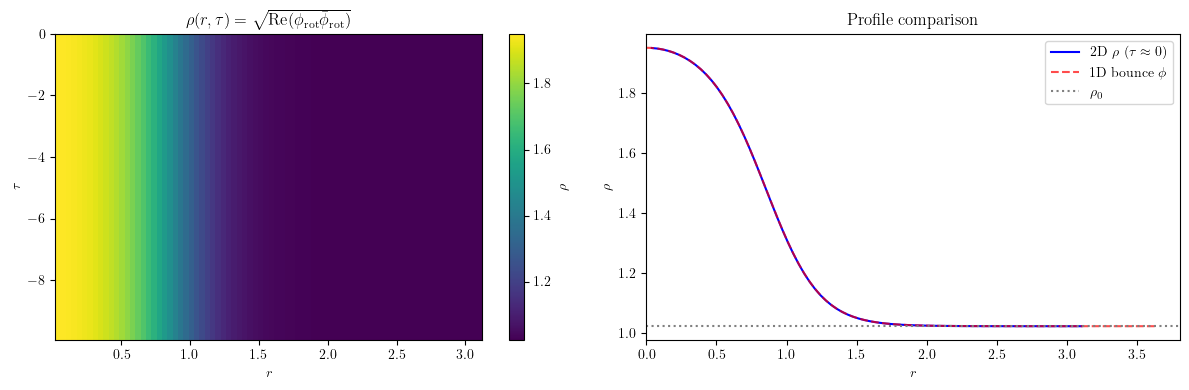

In [14]:
# Plot solution: rho = sqrt(Re(phi_rot * phibar_rot))
rho_2d = solver_diag.rho_map(y_f, ybar_f)
r_plot = np.asarray(solver_diag.grid.r, float)
tau_plot = np.asarray(solver_diag.grid.tau, float)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# 2D heatmap: rho(r, tau) — r on x-axis, tau on y-axis
im = axes[0].pcolormesh(r_plot, tau_plot, rho_2d.T, shading="auto", cmap="viridis")
axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\tau$")
axes[0].set_title(r"$\rho(r,\tau) = \sqrt{\mathrm{Re}(\phi_{\mathrm{rot}}\bar{\phi}_{\mathrm{rot}})}$")
plt.colorbar(im, ax=axes[0], label=r"$\rho$")

# 1D slice at tau=0 (or first slice) vs 1D bounce
rho_tau0 = rho_2d[:, 0]
axes[1].plot(r_plot, rho_tau0, "b-", label=r"2D $\rho$ ($\tau \approx 0$)")
axes[1].plot(r_1d, phi_1d, "r--", alpha=0.7, label=r"1D bounce $\phi$")
axes[1].axhline(rho0, color="gray", ls=":", label=r"$\rho_0$")
axes[1].set_xlabel(r"$r$")
axes[1].set_ylabel(r"$\rho$")
axes[1].set_title("Profile comparison")
axes[1].legend()
axes[1].set_xlim(0, None)

plt.tight_layout()
plt.show()

In [15]:
# ============================================================================
# PART 2 — Local ODE residual comparison + bulk vs boundary decomposition
# ============================================================================
from Bubble_finder.diagnostics_sanity import (
    local_ode_residual_comparison,
    bulk_vs_boundary_residual,
    bulk_vs_boundary_with_bc_compare,
)
from Bubble_finder.potential_bubble import dOmega_dphi

# (2a) Local ODE residual: 1D equation vs 2D reduced equation
loc = local_ode_residual_comparison(
    r_1d, phi_1d, solver_diag, dU, dOmega_dphi, float(PHI0), float(V1), float(V2),
)
print("PART 2a — Local ODE residual (excludes r=0):")
print(f"  Residual_1D_equation:     max = {loc['res_1d_max']:.6e}, mean = {loc['res_1d_mean']:.6e}")
print(f"  Residual_2D_reduced_eq:   max = {loc['res_2d_max']:.6e}, mean = {loc['res_2d_mean']:.6e}")
print(f"  n_pts = {loc['n_pts']}")
if loc['res_1d_max'] < 1e-6 and loc['res_2d_max'] > 0.01:
    print("  --> 1D solution satisfies 1D ODE but NOT 2D reduced eq → EQUATIONS DIFFER.")
elif loc['res_1d_max'] < 1e-6 and loc['res_2d_max'] < 1e-6:
    print("  --> Both residuals small → bulk equations match.")
print()

# (2b) Bulk vs boundary decomposition for embedded 1D config
dec = bulk_vs_boundary_residual(solver_diag, x_seed_embed)
print("PART 2b — Bulk vs boundary residual decomposition (tau_bc=twisted):")
print(f"  max_bulk (excl i=0, i=Nt-1)  = {dec['max_bulk']:.6e}")
print(f"  max_boundary (i=0 or i=Nt-1) = {dec['max_boundary']:.6e}")
print(f"  max at i=0                   = {dec['max_i0']:.6e}")
print(f"  max at i=Nt-1                = {dec['max_iNt1']:.6e}")
if dec['max_boundary'] > 10 * dec['max_bulk'] and dec['max_bulk'] < 0.01:
    print("  --> Bulk matches but BC is inconsistent (boundary residual dominates).")
print()

# (2c) Compare twisted vs neumann BC (requires allow_debug_bcs)
bc_compare = bulk_vs_boundary_with_bc_compare(solver_diag, x_seed_embed, U, dU, d2U)
if "error" in bc_compare:
    print("PART 2c — BC comparison: allow_debug_bcs=False, skipping tau_bc=neumann comparison.")
else:
    print("PART 2c — twisted vs neumann tau_bc:")
    print(f"  twisted:  max_bulk={bc_compare['max_bulk_twisted']:.6e}, max_boundary={bc_compare['max_boundary_twisted']:.6e}")
    print(f"  neumann:  max_bulk={bc_compare['max_bulk_neumann']:.6e}, max_boundary={bc_compare['max_boundary_neumann']:.6e}")

PART 2a — Local ODE residual (excludes r=0):
  Residual_1D_equation:     max = 5.077886e-04, mean = 6.463683e-05
  Residual_2D_reduced_eq:   max = 5.077886e-04, mean = 6.463683e-05
  n_pts = 997

PART 2b — Bulk vs boundary residual decomposition (tau_bc=twisted):
  max_bulk (excl i=0, i=Nt-1)  = 1.609316e-02
  max_boundary (i=0 or i=Nt-1) = 1.609316e-02
  max at i=0                   = 1.609316e-02
  max at i=Nt-1                = 1.609316e-02

PART 2c — BC comparison: allow_debug_bcs=False, skipping tau_bc=neumann comparison.


In [16]:
# ============================================================================
# PART 3 — Potential convention audit table
# ============================================================================
from Bubble_finder.diagnostics_sanity import potential_convention_audit
from Bubble_finder.potential_bubble import V_phi, dV_dphi

omega_audit = float(solver_diag.omega)
rho_hom = float(solver_diag.rho0)
rho_vals = np.unique(np.concatenate([
    [rho_hom], np.linspace(phi_1d.min(), phi_1d.max(), 5), [float(V1), float(V2)],
]))
audit = potential_convention_audit(rho_vals, V_phi, dV_dphi, float(PHI0), float(V1), float(V2),
                                   omega_audit, dU)
print("PART 3 — Potential convention audit table")
print("=" * 100)
print(f"{'rho':>8} {'V':>10} {'dV/dφ':>10} {'W_2d':>10} {'force_1d':>12} {'force_2d':>12} {'rel_diff':>10}")
print("-" * 100)
for row in audit["rows"]:
    rel = abs(row["force_1d"] - row["force_2d_reduced"]) / (abs(row["force_1d"]) + 1e-20)
    print(f"{row['rho']:8.4f} {row['V']:10.4f} {row['dV_dvarphi']:10.4f} {row['W_2d']:10.4f} "
          f"{row['force_1d']:12.4f} {row['force_2d_reduced']:12.4f} {rel:10.2e}")
print("=" * 100)
max_rel = max(abs(row["force_1d"] - row["force_2d_reduced"]) / (abs(row["force_1d"]) + 1e-20) for row in audit["rows"])
audit_ok = max_rel < 1e-6
print(f"  Potential audit: max_rel_diff = {max_rel:.2e}  {'PASS' if audit_ok else 'FAIL (expected < 1e-6 after factor-2 fix)'}")

PART 3 — Potential convention audit table
     rho          V      dV/dφ       W_2d     force_1d     force_2d   rel_diff
----------------------------------------------------------------------------------------------------
  1.0000    -0.5000     0.0000     0.0000      -0.7200      -0.7200   0.00e+00
  1.0231    -0.4907     0.7366     0.3600       0.0000       0.0000   0.00e+00
  1.0231    -0.4907     0.7367     0.3600       0.0000       0.0000   0.00e+00
  1.2550    -0.0859     1.4508     0.5780       0.5472       0.5472   0.00e+00
  1.4870    -0.1118    -1.8173    -0.6111      -2.8879      -2.8879   0.00e+00
  1.7189    -0.8199    -3.7286    -1.0846      -4.9662      -4.9662   0.00e+00
  1.9508    -1.4757    -1.0395    -0.2664      -2.4440      -2.4440   0.00e+00
  2.0000    -1.5000     0.0000     0.0000      -1.4400      -1.4400   0.00e+00
  Potential audit: max_rel_diff = 0.00e+00  PASS


In [17]:
# ============================================================================
# PART 4 — Charge definition report and corrected comparison
# ============================================================================
from Bubble_finder.diagnostics_sanity import charge_definition_report
from Bubble_finder.observables_2d import (
    compute_charge_tau0_ghost_2d,
    compute_charge_like_2d_from_1d,
)

charge_rep = charge_definition_report()
print("PART 4 — Charge definition report")
print("=" * 70)
for name, d in [("compute_charge_1d", charge_rep["compute_charge_1d"]),
                ("compute_charge_tau0_ghost_2d", charge_rep["compute_charge_tau0_ghost_2d"])]:
    print(f"  {name}:")
    for k, v in d.items():
        print(f"    {k}: {v}")
print("  Comparison: " + charge_rep["comparison_note"])
print("=" * 70)

# Apples-to-apples: 1D charge using 2D definition (same formula, same r grid)
compare_excess_Q = True  # Match notebook target
r_2d = np.asarray(solver_diag.grid.r, float)
Q_2d_total = compute_charge_tau0_ghost_2d(solver_diag, y_f, ybar_f, subtract_background=False)
Q_2d_excess = compute_charge_tau0_ghost_2d(solver_diag, y_f, ybar_f, subtract_background=True)
Q_1d_like_2d_total = compute_charge_like_2d_from_1d(r_1d, phi_1d, r_2d, omega_ref, rho0, subtract_background=False)
Q_1d_like_2d_excess = compute_charge_like_2d_from_1d(r_1d, phi_1d, r_2d, omega_ref, rho0, subtract_background=True)
print("\nCharge comparison (2D definition, same omega, same r grid):")
print(f"  Q_2d_total         = {Q_2d_total:.6e}")
print(f"  Q_2d_excess        = {Q_2d_excess:.6e}")
print(f"  Q_1d_like_2d_total  = {Q_1d_like_2d_total:.6e}")
print(f"  Q_1d_like_2d_excess = {Q_1d_like_2d_excess:.6e}")
if compare_excess_Q:
    diff = abs(Q_2d_excess - Q_1d_like_2d_excess)
    rel_diff = diff / (abs(Q_2d_excess) + 1e-30)
    print(f"  |Q_2d_excess - Q_1d_like_2d_excess| = {diff:.6e} (rel {rel_diff:.2e})")
else:
    diff = abs(Q_2d_total - Q_1d_like_2d_total)
    rel_diff = diff / (abs(Q_2d_total) + 1e-30)
    print(f"  |Q_2d_total - Q_1d_like_2d_total| = {diff:.6e} (rel {rel_diff:.2e})")

PART 4 — Charge definition report
  compute_charge_1d:
    formula: Q = 4*pi * omega * integral(r^2 * phi^2, dr)
    field: phi (unrotated amplitude)
    omega: passed as argument (must match 1D bounce omega)
    background_subtraction: False
    volume: full integration from r[0] to r[-1]
  compute_charge_tau0_ghost_2d:
    formula: Q = 4*pi * integral(r^2 * q, dr), q = (1/2)*Re(phibar*phi_tau - phi*phibar_tau)
    field: phi, phibar (unrotated), reconstructed at tau=0 via ghost
    omega: solver.omega
    background_subtraction: optional subtract_background=True => Q -= Q_homogeneous_ball(omega, rho0, r_max)
    volume: r from grid
  Comparison: For apples-to-apples: use same omega, compare EXCESS charge (subtract background) for both.

Charge comparison (2D definition, same omega, same r grid):
  Q_2d_total         = 8.385877e+01
  Q_2d_excess        = 5.254848e+00
  Q_1d_like_2d_total  = 8.386517e+01
  Q_1d_like_2d_excess = 5.261257e+00
  |Q_2d_excess - Q_1d_like_2d_excess| = 6.408

In [18]:
# ============================================================================
# REGRESSION CHECK — After factor-2 fix: bulk and boundary comparable, equations match
# ============================================================================
# With the fix: (i) local 1D and 2D ODE residuals agree, (ii) bulk ~ boundary (no BC spike).
# Discretization/interpolation limit how small the residual can be; we check bulk ~ boundary.
dec_reg = bulk_vs_boundary_residual(solver_diag, x_seed_embed)
ratio = dec_reg["max_boundary"] / (dec_reg["max_bulk"] + 1e-30)
# Before fix: boundary >> bulk (tau BC mismatch). After fix: ratio ~ 1.
bulk_bound_ok = ratio < 2.0 and dec_reg["max_bulk"] < 100.0  # no boundary spike, reasonable scale
print("REGRESSION CHECK (embedded 1D @ eta0=0, after factor-2 fix):")
print(f"  max_bulk     = {dec_reg['max_bulk']:.6e}")
print(f"  max_boundary = {dec_reg['max_boundary']:.6e}")
print(f"  ratio (boundary/bulk) = {ratio:.4f}  (should be ~1 if BC consistent)")
if bulk_bound_ok:
    print("  --> PASS: bulk and boundary comparable (no tau-BC spike)")
else:
    print("  --> Check: if ratio >> 1, tau BC may be inconsistent")

REGRESSION CHECK (embedded 1D @ eta0=0, after factor-2 fix):
  max_bulk     = 1.609316e-02
  max_boundary = 1.609316e-02
  ratio (boundary/bulk) = 1.0000  (should be ~1 if BC consistent)
  --> PASS: bulk and boundary comparable (no tau-BC spike)


## 2.2 Continuation in $\eta_0$ from the static bubble (twisted BC)

We start from the **static solution** ($\tau$-independent bubble) obtained at $\eta_0=0$ in the diagnostics section (TASK B). Then we perform **continuation in $\eta_0$**: we increase $\eta_0$ and solve with Newton at each step, using the previous solution as the initial guess. This shows how the solution develops $\tau$-dependence as $\eta_0$ varies, while keeping **twisted BC** ($\tau \in [-\beta/2,\,0]$ with twist at $\tau=-\beta/2$).

**Note:** $\eta_0$ is the parameter that controls the "rotation" of the complex field in Euclidean time; at $\eta_0=0$ the profile is $\tau$-independent; for $\eta_0\neq 0$ the configuration has non-zero charge and temporal dependence.


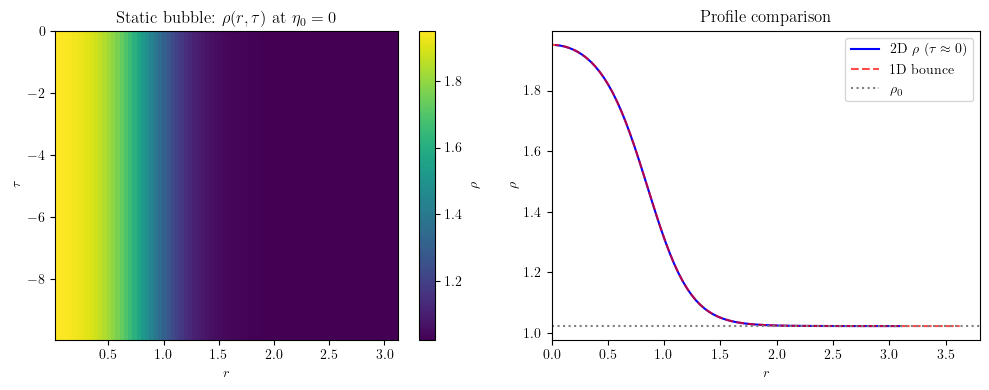

In [19]:
# ============================================================================
# B.1 — Static solution at eta0=0 (already converged in Second try)
# ============================================================================
# Reuse solver_diag, result_embed, x_seed_embed from TASK B.
# Ensure we have a converged static bubble for continuation.
x_static_eta0 = result_embed.x if result_embed is not None and result_embed.success else x_seed_embed
y_static, ybar_static = solver_diag.unpack(x_static_eta0)
phi_rot_static, _ = solver_diag.phi_rot(y_static, ybar_static)
rho_static = solver_diag.rho_map(y_static, ybar_static)
r_plot = np.asarray(solver_diag.grid.r, float)
tau_plot = np.asarray(solver_diag.grid.tau, float)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im = axes[0].pcolormesh(r_plot, tau_plot, rho_static.T, shading="auto", cmap="viridis")
axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\tau$")
axes[0].set_title(r"Static bubble: $\rho(r,\tau)$ at $\eta_0=0$")
plt.colorbar(im, ax=axes[0], label=r"$\rho$")
axes[1].plot(r_plot, rho_static[:, 0], "b-", label=r"2D $\rho$ ($\tau \approx 0$)")
axes[1].plot(r_1d, phi_1d, "r--", alpha=0.7, label="1D bounce")
axes[1].axhline(rho0, color="gray", ls=":", label=r"$\rho_0$")
axes[1].set_xlabel(r"$r$")
axes[1].set_ylabel(r"$\rho$")
axes[1].set_title("Profile comparison")
axes[1].legend()
axes[1].set_xlim(0, None)
plt.tight_layout()
plt.show()

## 3. Best ansatz selection on a small parameter grid (non-oscillatory)

We use only the **gated bubble** family (`build_seed_bubble` with $\texttt{eps}=0$, no oscillatory kick) with twisted BC. We run a **scan** over a parameter grid (typically $\texttt{amp}$ and $\texttt{tau\_gate\_frac}$); each ansatz is evaluated via the **residual norm** of the discretized equations. We rank by residual and run **Newton** on the best ansatz; the output gives $\texttt{best\_x0}$, $\texttt{best\_grid}$ and the converged solution, which is plotted. Functions involved: `AnsatzParams`, `build_seed_bubble`, `make_bubble_profile_1d_from_arrays` (or similar), and the selection/scan logic over parameter grids.


In [11]:
# ============================================================================
# Section 3: Non-oscillatory seed selection, Newton solve, and plots
# ============================================================================
# Uses solver_diag, r_1d, phi_1d, rho0 from Second try diagnostics. Twisted BC only.

from Bubble_finder.ansatz_bubble import (
    AnsatzParams, build_seed_bubble,
    make_q_ball_objects, make_bubble_profile_1d_from_arrays,
)
from Bubble_finder.observables_2d import compute_charge_tau0_ghost_2d
from Bubble_finder.bounce2d import NewtonConvergenceError

def evaluate_seed(solver, x0, name="", extra_meta=None):
    """Compute residual norms, tau_std_rho, boundary flag. rho from phi_rot*phibar_rot."""
    F = np.asarray(solver.residual(x0), dtype=float)
    n_sites = F.size
    nF_inf = float(np.max(np.abs(F)))
    nF_2 = float(np.linalg.norm(F))
    nF_2_per_site = nF_2 / np.sqrt(n_sites) if n_sites > 0 else 0.0
    flat_idx = int(np.argmax(np.abs(F)))
    j_max = flat_idx // solver.Nt if solver.Nt > 0 else 0
    i_max = flat_idx % solver.Nt if solver.Nt > 0 else 0
    at_boundary = (j_max == 0 or j_max == solver.Nr - 1 or i_max == 0 or i_max == solver.Nt - 1)
    y, ybar = solver.unpack(x0)
    phi_rot, phibar_rot = solver.phi_rot(y, ybar)
    u = np.maximum((phi_rot * phibar_rot).real, 0.0)
    rho = np.sqrt(u)
    tau_std_rho = float(np.max(np.std(rho, axis=1))) if rho.size > 0 else 0.0
    return dict(
        name=name, nF_inf=nF_inf, nF_2_per_site=nF_2_per_site,
        tau_std_rho=tau_std_rho, at_boundary=at_boundary,
        j_max=j_max, i_max=i_max, extra=extra_meta or {},
    )

# Solver: use diagnostic solver if available (run "Second try: diagnostics" first),
# else fall back to section 4 solver (run section 4 first)
try:
    solver_s5 = solver_diag
    r_1d = r_1d
    phi_1d = phi_1d
except NameError:
    solver_s5 = solver_s4
    r_1d = r_1d_s4
    phi_1d = phi_1d_s4
rho0_s5 = float(solver_s5.rho0)
grid2d, fields, potential, _, _ = make_q_ball_objects(solver_s5)
omega_ref = float(getattr(solver_s5, "omega", OMEGA))
eta0_s5 = float(getattr(solver_s5, "eta0", 0.0))
bubble_profile_1d = make_bubble_profile_1d_from_arrays(r_1d, phi_1d)

# Candidate seeds: gated_bubble only (eps=0, no oscillatory kick)
candidates = []
neg_mode_dummy = (np.zeros_like(fields.grid.r), np.zeros_like(fields.grid.r), 0.0)
for amp in [1.05, 1.1]:
    for tau_gate_frac in [ 0.1, 0.15, 0.2, 0.25]:
        params = AnsatzParams(eps=1.0, k=1, phase=0.0, amp=amp, tau_gate_frac=tau_gate_frac, tau_gate_center_frac=1, r_window_frac=0.15)
        try:
            x0_g, _ = build_seed_bubble(
                grid=grid2d, fields=fields, potential=potential,
                omega_ref=omega_ref, omega_tilde=omega_ref,
                bubble_profile_1d=bubble_profile_1d, params=params,
                neg_mode_override=neg_mode_dummy,
            )
            rep = evaluate_seed(solver_s5, x0_g, "gated_bubble", {"amp": amp, "tau_gate_frac": tau_gate_frac})
            rep["x0"] = x0_g
            candidates.append(rep)
        except Exception as e:
            pass

# Sort by nF_inf (best first)
candidates.sort(key=lambda c: c["nF_inf"])
best = candidates[0]
best_x0 = best["x0"]
best_name = best["name"]
best_params = best.get("extra", {})

print("Seed ranking table (by ||F||_inf):")
print(f"{'name':<22} {'params':<20} {'||F||_inf':>12} {'||F||_2/sqrt(N)':>14} {'tau_std_rho':>12} {'boundary':>8}")
for c in candidates:
    params_str = str(c.get("extra", {}))[:18]
    print(f"{c['name']:<22} {params_str:<20} {c['nF_inf']:>12.4e} {c['nF_2_per_site']:>14.4e} {c['tau_std_rho']:>12.4e} {str(c['at_boundary']):>8}")

print(f"\nBest seed: {best_name} {best_params}")

# Newton solve
result_s5 = None
try:
    result_s5 = solver_s5.solve(best_x0, verbose=True, store_iteration_history=False)
    print(f"\nNewton: success={result_s5.success}, iters={result_s5.iterations}, final ||F||={result_s5.residual_norm:.4e}")
except (NewtonConvergenceError, Exception) as e:
    print(f"\nNewton failed: {e}")
    if len(candidates) > 1:
        print("Trying fallback (second-best seed)...")
        best_x0 = candidates[1]["x0"]
        try:
            result_s5 = solver_s5.solve(best_x0, verbose=True, store_iteration_history=False)
        except Exception as e2:
            print(f"Fallback also failed: {e2}")

# Use converged solution or best seed for plotting
x_final = result_s5.x if result_s5 is not None and result_s5.success else best_x0
y_fin, ybar_fin = solver_s5.unpack(x_final)
rho_fin = solver_s5.rho_map(y_fin, ybar_fin)
Q_s5 = compute_charge_tau0_ghost_2d(solver_s5, y_fin, ybar_fin, subtract_background=False)
phi_rot_fin, _ = solver_s5.phi_rot(y_fin, ybar_fin)
tau_std_fin = float(np.max(np.std(np.real(phi_rot_fin), axis=1)))
print(f"\nFinal: Q (2D) = {Q_s5:.6e}, tau_std_rho = {tau_std_fin:.6e}")

# Compatibility with downstream cells (section 6+)
best_seed = type("_BestSeed", (), {})()
best_seed.best_x0 = best_x0
best_seed.best_score = best["nF_inf"]
best_seed.best_norm = best["nF_inf"]
best_seed.best_params = {**best_params, "omega_tilde": omega_ref}
best_seed.best_Q = Q_s5
best_seed.best_Q_excess = Q_s5 - (Q_hom if "Q_hom" in dir() else 0)
best_seed.best_meta = best.get("extra", {})
best_grid = grid2d
best_candidate = type("_BestCandidate", (), {})()
best_candidate.omega_tilde = omega_ref
best_candidate.meta = {"rho_ref": rho0_s5}
BETA_USED = float(solver_s5.settings.beta)


Seed ranking table (by ||F||_inf):
name                   params                  ||F||_inf ||F||_2/sqrt(N)  tau_std_rho boundary
gated_bubble           {'amp': 1.05, 'tau     8.6724e-01     5.7544e-02   1.7980e-01    False
gated_bubble           {'amp': 1.1, 'tau_     8.6735e-01     5.6467e-02   1.8838e-01    False
gated_bubble           {'amp': 1.1, 'tau_     9.0769e-01     5.4560e-02   1.7188e-01    False
gated_bubble           {'amp': 1.05, 'tau     9.0959e-01     5.5584e-02   1.6405e-01    False
gated_bubble           {'amp': 1.1, 'tau_     9.8429e-01     5.6667e-02   1.5173e-01    False
gated_bubble           {'amp': 1.05, 'tau     9.8731e-01     5.7356e-02   1.4482e-01    False
gated_bubble           {'amp': 1.1, 'tau_     1.2032e+00     7.4309e-02   1.2619e-01    False
gated_bubble           {'amp': 1.05, 'tau     1.2145e+00     7.3622e-02   1.2044e-01    False

Best seed: gated_bubble {'amp': 1.05, 'tau_gate_frac': 0.25}
[Newton-explicit] iter=01, ||F||=1.029e+01, charge=2.330

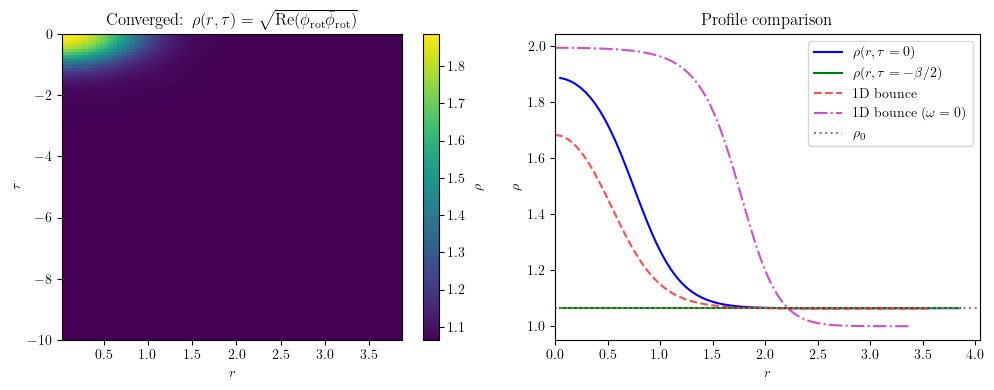

In [12]:
# Plot converged solution: rho 2D heatmap + slices at tau=0, tau=-beta/2 vs 1D bounce
r_plot = np.asarray(solver_s5.grid.r, float)
tau_plot = np.asarray(solver_s5.grid.tau, float)
beta = float(solver_s5.settings.beta)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im = axes[0].pcolormesh(r_plot, tau_plot, rho_fin.T, shading="auto", cmap="viridis")
axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\tau$")
axes[0].set_title(r"Converged: $\rho(r,\tau) = \sqrt{\mathrm{Re}(\phi_{\mathrm{rot}}\bar{\phi}_{\mathrm{rot}})}$")
plt.colorbar(im, ax=axes[0], label=r"$\rho$")

axes[1].plot(r_plot, rho_fin[:, 0], "b-", label=r"$\rho(r, \tau=0)$")
axes[1].plot(r_plot, rho_fin[:, -1], "g-", label=r"$\rho(r, \tau=-\beta/2)$")
axes[1].plot(r_1d, phi_1d, "r--", alpha=0.7, label="1D bounce")
if r_bubble_zero_charge is not None and phi_bubble_zero_charge is not None:
    axes[1].plot(r_bubble_zero_charge, phi_bubble_zero_charge, "m-.", alpha=0.7, label=r"1D bounce ($\omega=0$)")
axes[1].axhline(rho0_s5, color="gray", ls=":", label=r"$\rho_0$")
axes[1].set_xlabel(r"$r$")
axes[1].set_ylabel(r"$\rho$")
axes[1].set_title("Profile comparison")
axes[1].legend()
axes[1].set_xlim(0, None)
plt.tight_layout()
plt.show()


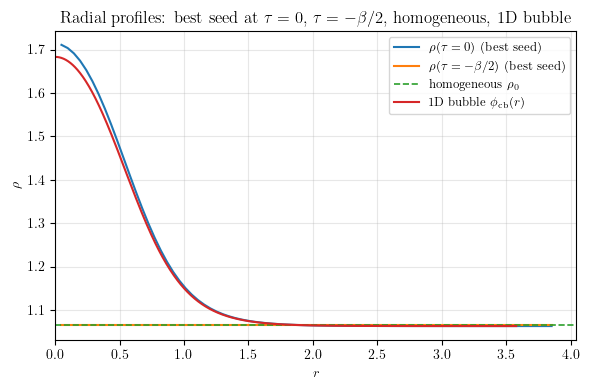

In [13]:
# rho(r) at tau=0, tau=-beta/2 for best seed (from section 5)
# Requires section 5: solver_s5, best_x0, best_grid
sol_plt = solver_s5
g_plt = best_grid if "best_grid" in dir() else sol_plt.grid
y_plt, ybar_plt = sol_plt.unpack(best_x0)
rho_seed = sol_plt.rho_map(y_plt, ybar_plt)  # (Nr, Nt)

r = np.asarray(g_plt.r, float)
rho_tau0 = rho_seed[:, 0]
rho_tau_mid = rho_seed[:, -1]
rho0_ref = float(sol_plt.rho0)
r_cb = r_1d if "r_1d" in dir() else globals().get("r_bounce")
phi_cb = phi_1d if "phi_1d" in dir() else globals().get("phi_bounce")

fig_rho, ax_rho = plt.subplots(1, 1, figsize=(6, 4))
ax_rho.plot(r, rho_tau0, "C0-", lw=1.5, label=r"$\rho(\tau=0)$ (best seed)")
ax_rho.plot(r, rho_tau_mid, "C1-", lw=1.5, label=r"$\rho(\tau=-\beta/2)$ (best seed)")
ax_rho.axhline(rho0_ref, color="C2", ls="--", lw=1.2, label=r"homogeneous $\rho_0$")
if r_cb is not None and phi_cb is not None:
    ax_rho.plot(r_cb, phi_cb, "C3-", lw=1.5, label=r"1D bubble $\phi_{\mathrm{cb}}(r)$")
ax_rho.set_xlabel(r"$r$")
ax_rho.set_ylabel(r"$\rho$")
ax_rho.set_title(r"Radial profiles: best seed at $\tau=0$, $\tau=-\beta/2$, homogeneous, 1D bubble")
ax_rho.legend(loc="best", fontsize=9)
ax_rho.set_xlim(0, None)
ax_rho.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

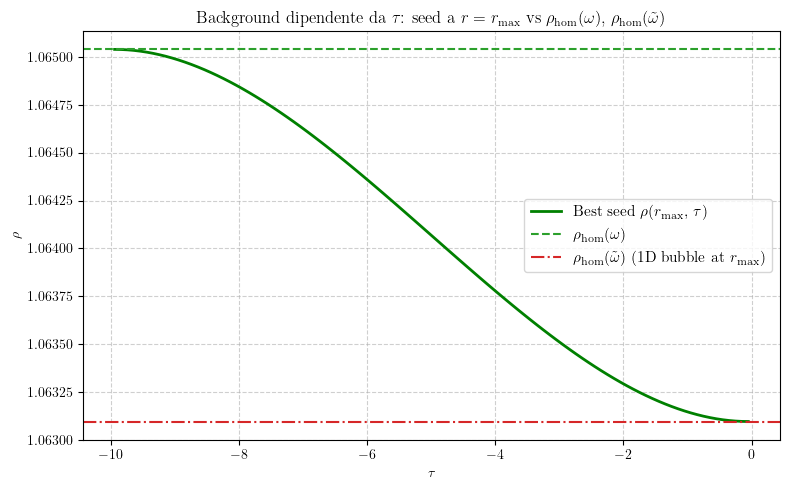

In [14]:
# ρ(r=r_max, τ) vs τ for best seed (from section 5)
# Requires section 5: solver_s5, best_x0, best_grid; rho_seed from previous cell if run, else recompute
g_plt = best_grid if "best_grid" in dir() else solver_s5.grid
if "rho_seed" not in dir():
    y_plt, ybar_plt = solver_s5.unpack(best_x0)
    rho_seed = solver_s5.rho_map(y_plt, ybar_plt)
r_max = float(g_plt.r[-1])
rho_seed_at_rmax = rho_seed[-1, :]
rho_hom = float(solver_s5.rho0)
phi_cb_arr = phi_1d if "phi_1d" in dir() and phi_1d is not None else globals().get("phi_bounce")
rho_tilde_at_rmax = float(phi_cb_arr[-1]) if phi_cb_arr is not None and len(phi_cb_arr) > 0 else None

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(g_plt.tau, rho_seed_at_rmax, "g-", lw=2, label=r"Best seed $\rho(r_{\max},\, \tau)$")
ax.axhline(rho_hom, color="C2", ls="--", lw=1.5, label=r"$\rho_{\mathrm{hom}}(\omega)$")
if rho_tilde_at_rmax is not None:
    ax.axhline(rho_tilde_at_rmax, color="C3", ls="-.", lw=1.5,
               label=r"$\rho_{\mathrm{hom}}(\tilde\omega)$ (1D bubble at $r_{\max}$)")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$\rho$")
ax.set_title(r"Background dipendente da $\tau$: seed a $r=r_{\max}$ vs $\rho_{\mathrm{hom}}(\omega)$, $\rho_{\mathrm{hom}}(\tilde\omega)$")
ax.legend(fontsize=11)
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Newton solve from the best ansatz

We solve the full **2D bubble nucleation problem** with Newton's method, starting from the best ansatz found in the scan (section 3): $\texttt{best\_x0}$, $\texttt{best\_grid}$, with $\beta$ and $\tilde{\omega}$ fixed.

The Newton iteration updates the field vector $x = (y,\bar y)$ (or equivalent parametrization) according to
$$
J[x_n] \, \delta x_n = - F[x_n] \,, \qquad x_{n+1} = x_n + \delta x_n \, ,
$$
where $F$ is the residual of the discretized equations of motion and $J$ is the Jacobian. We use **damped** Newton with backtracking to ensure convergence.

**Contents of this section:**

1. Build `Bubble2DSolver` on the chosen grid and parameters.
2. Run Newton with `verbose=True`; optionally store the **iteration history** ($\rho(r,\tau) = \sqrt{\phi\bar\phi}$ at each step).
3. Plot the final solution and, if available, intermediate iterations (slices at $\tau=0$, $\rho(r_{\max},\tau)$, etc.) to visualize the approach to the 2D bubble.


In [15]:
# ============================================================================
# Newton solve from best ansatz (section 4 scan)
# ============================================================================
# Uses best seed from section 3: best_x0, best_grid, BETA_USED, omega_ref, rho0_s5

grid_newton = best_grid
beta_newton = BETA_USED
omega_tilde_newton = omega_ref
x0_newton = best_x0
rho0_newton = float(rho0_s5)

# Twist η: eta = T*(omega_tilde - omega_ref); eta0 is passed directly (no factor-of-2)
ETA0 = beta_newton * (omega_tilde_newton - OMEGA)

# Grid can be Grid2D (.Nt) from ansatz_bubble or RadialTimeGrid (.Ntau) from Q_ball_finder
_ntau = getattr(grid_newton, "Nt", getattr(grid_newton, "Ntau", len(grid_newton.tau)))
settings_newton = Bubble2DSettings(
    Nr=grid_newton.Nr,
    Ntau=_ntau,
    Lr=grid_newton.dr * grid_newton.Nr,
    beta=beta_newton,
    omega_ref=OMEGA,
    rho0=rho0_newton,
    rho0_bracket=(1.0, 1.15),
    newton_tol=1e-8,
    newton_max_iter=20,
    damping=0.1,
    newton_verbose=True,
    tau_bc="twisted", #twisted, hom_past, neumann
    eta0=ETA0,
    #allow_debug_bcs=True,
)

# Solver: same frame as seed (omega=OMEGA, rho0=rho_hom(OMEGA)) so the initial guess is consistent
solver_newton = Bubble2DSolver(settings_newton, U, dU, d2U)
# Keep omega and rho0 from settings (omega_ref=OMEGA → rho0=rho_hom(OMEGA)); do NOT use omega_tilde

# Initial condition: best seed from section 5 scan
print("Running Newton solve from best seed (section 5)...")
newton_result = solver_newton.solve(x0_newton, verbose=True, store_iteration_history=True)

print("=" * 70)
print("Newton solve summary")
print("=" * 70)
print(f"  Converged: {newton_result.success}")
print(f"  Iterations: {newton_result.iterations}")
print(f"  Final ||F|| = {newton_result.residual_norm:.6e}")

Running Newton solve from best seed (section 5)...
[Newton-explicit] iter=01, ||F||=1.029e+01, charge=2.330699e+02, energy=4.890046e+00, rhoQ=9.725931e-01, rhoE=2.040601e-02, ratioQ=1.0087, ratioE=28240123832.9655
[Newton-explicit] iter=02, ||F||=5.523e+00, charge=2.322856e+02, energy=4.381874e+00, rhoQ=9.693202e-01, rhoE=1.828542e-02, ratioQ=1.0054, ratioE=25305415742.8594
[Newton-explicit] iter=03, ||F||=1.446e+00, charge=2.315226e+02, energy=3.357652e+00, rhoQ=9.661364e-01, rhoE=1.401137e-02, ratioQ=1.0021, ratioE=19390512464.9937
[Newton-explicit] iter=04, ||F||=6.163e-02, charge=2.315051e+02, energy=3.244893e+00, rhoQ=9.660632e-01, rhoE=1.354083e-02, ratioQ=1.0020, ratioE=18739325217.5207
[Newton-explicit] iter=05, ||F||=7.557e-05, charge=2.315061e+02, energy=3.244401e+00, rhoQ=9.660673e-01, rhoE=1.353878e-02, ratioQ=1.0020, ratioE=18736486856.3708
[Newton-explicit] iter=06, ||F||=3.584e-10, charge=2.315061e+02, energy=3.244395e+00, rhoQ=9.660673e-01, rhoE=1.353875e-02, ratioQ=1.0

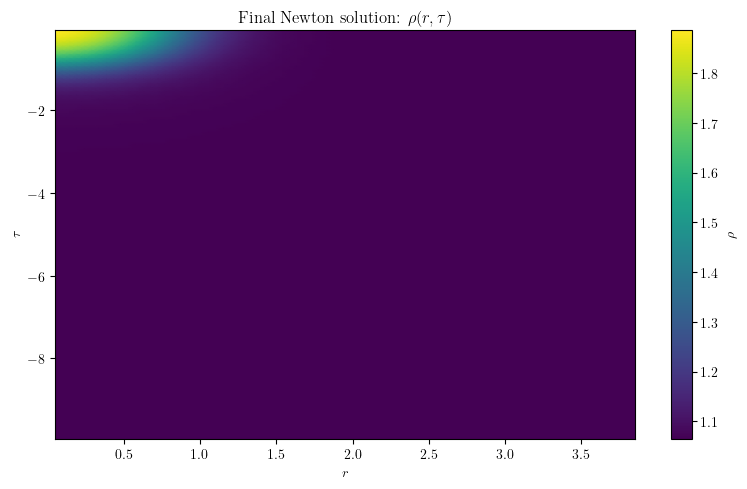

In [16]:
# Unpack final solution and density
y_sol, ybar_sol = solver_newton.unpack(newton_result.x)
phi_sol, phibar_sol = solver_newton.phi(y_sol, ybar_sol)
rho_sol = np.sqrt(np.maximum((phi_sol * phibar_sol).real, 0.0))

# Plot final solution separately
R_f, T_f = np.meshgrid(grid_newton.r, grid_newton.tau, indexing="xy")

fig, ax = plt.subplots(figsize=(8, 5))
cf = ax.pcolormesh(R_f, T_f, rho_sol.T, shading="gouraud", cmap="viridis")
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$\tau$")
ax.set_title(r"Final Newton solution: $\rho(r, \tau)$")
fig.colorbar(cf, ax=ax, label=r"$\rho$")
plt.tight_layout()
plt.show()

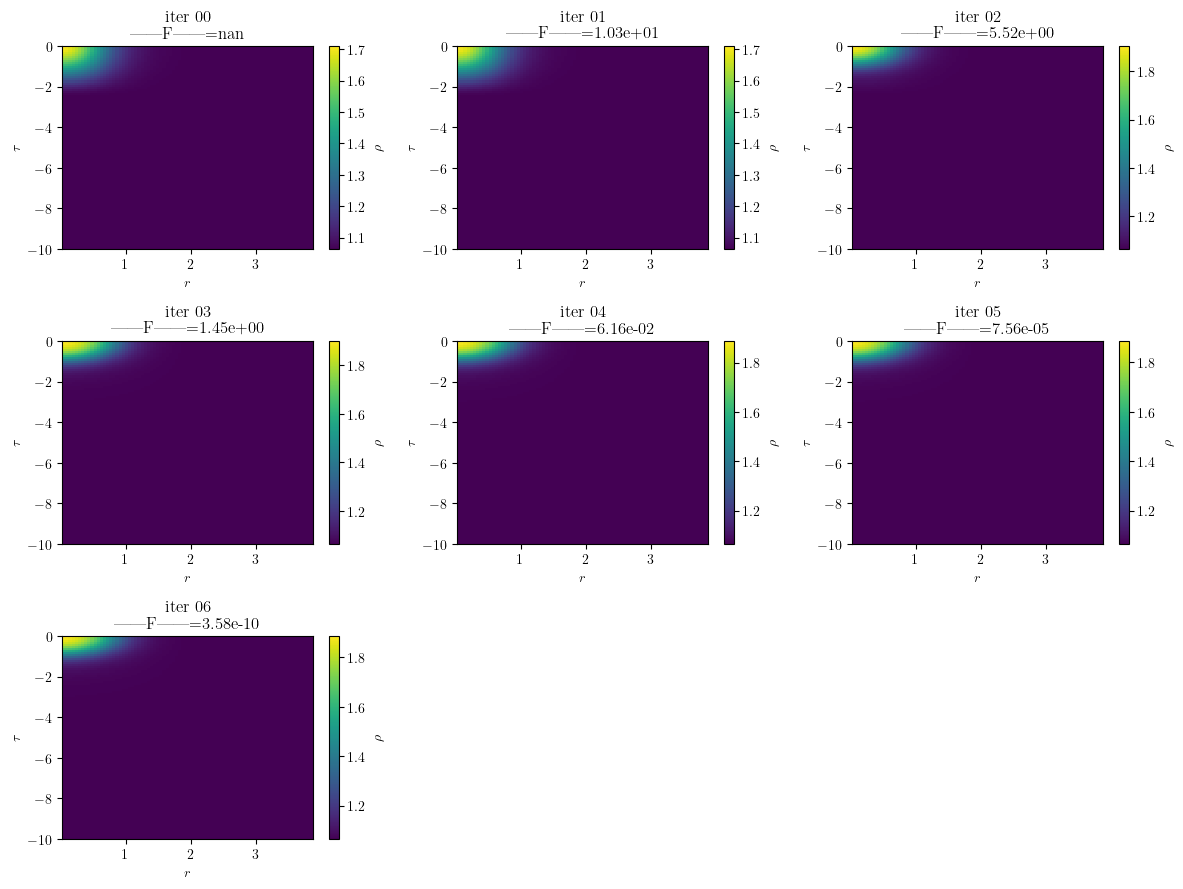

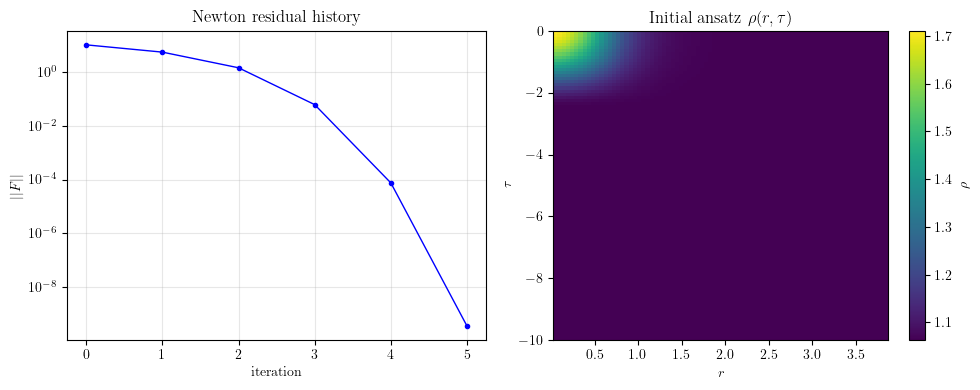

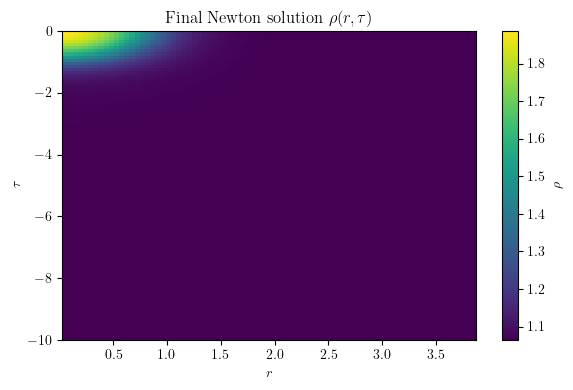

In [17]:
# Newton: residual history + rho at every iteration (when store_iteration_history=True)
R_it, T_it = np.meshgrid(grid_newton.r, grid_newton.tau, indexing="xy")
hist = getattr(newton_result.newton, "history", None) or getattr(newton_result, "history", None)
iteration_history = getattr(newton_result, "iteration_history", None) or []

if iteration_history:
    # Plot rho for each Newton iteration (grid of subplots)
    n_iter = len(iteration_history)
    n_cols = int(np.ceil(np.sqrt(n_iter)))
    n_rows = int(np.ceil(n_iter / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows))
    axes = np.atleast_1d(axes).ravel()
    for i, it in enumerate(iteration_history):
        ax = axes[i]
        rho_it = it["rho"]
        res = it["res_norm"]
        im = ax.pcolormesh(R_it, T_it, rho_it.T, shading="auto", cmap="viridis")
        ax.set_title(f"iter {it['iter']:02d}\n||F||={res:.2e}")
        ax.set_xlabel(r"$r$")
        ax.set_ylabel(r"$\tau$")
        plt.colorbar(im, ax=ax, label=r"$\rho$")
    for j in range(len(iteration_history), len(axes)):
        axes[j].axis("off")
    plt.tight_layout()
    plt.show()

if hist is not None and len(hist) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    ax = axes[0]
    ax.semilogy(range(len(hist)), hist, "b-o", lw=1, ms=3)
    ax.set_xlabel("iteration")
    ax.set_ylabel(r"$||F||$")
    ax.set_title("Newton residual history")
    ax.grid(True, alpha=0.3)
    y_init, ybar_init = solver_newton.unpack(x0_newton)
    phi_init, phibar_init = solver_newton.phi(y_init, ybar_init)
    rho_init = np.sqrt(np.maximum((phi_init * phibar_init).real, 0.0))
    ax = axes[1]
    im0 = ax.pcolormesh(R_it, T_it, rho_init.T, shading="auto", cmap="viridis")
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$\tau$")
    ax.set_title(r"Initial ansatz $\rho(r,\tau)$")
    plt.colorbar(im0, ax=ax, label=r"$\rho$")
    plt.tight_layout()
    plt.show()

    fig2, ax2 = plt.subplots(1, 1, figsize=(6, 4))
    im2 = ax2.pcolormesh(R_it, T_it, rho_sol.T, shading="auto", cmap="viridis")
    ax2.set_xlabel(r"$r$")
    ax2.set_ylabel(r"$\tau$")
    ax2.set_title(r"Final Newton solution $\rho(r,\tau)$")
    plt.colorbar(im2, ax=ax2, label=r"$\rho$")
    plt.tight_layout()
    plt.show()
else:
    print("No Newton history available; re-run solve with store_iteration_history=True for rho per iteration.")

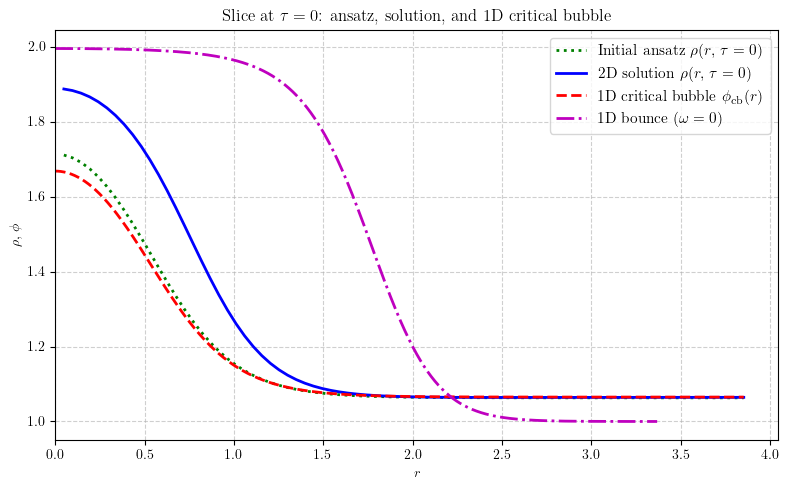

In [18]:
# Slice at τ=0 of the 2D solution vs 1D critical bubble profile and initial ansatz
i_tau0 = np.argmin(np.abs(grid_newton.tau))
rho_at_tau0 = rho_sol[:, i_tau0]

# Initial ansatz (actually given to Newton): unpack x0_newton and get ρ at τ=0
y_init, ybar_init = solver_newton.unpack(x0_newton)
phi_init, phibar_init = solver_newton.phi(y_init, ybar_init)
rho_init = np.sqrt(np.maximum((phi_init * phibar_init).real, 0.0))
rho_init_at_tau0 = rho_init[:, i_tau0]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(grid_newton.r, rho_init_at_tau0, "g:", lw=2, label=r"Initial ansatz $\rho(r,\, \tau=0)$")
ax.plot(grid_newton.r, rho_at_tau0, "b-", lw=2, label=r"2D solution $\rho(r,\, \tau=0)$")
if "r_bounce" in globals() and r_bounce is not None:
    ax.plot(r_bounce, phi_bounce, "r--", lw=2, label=r"1D critical bubble $\phi_{\mathrm{cb}}(r)$")
if "r_bubble_zero_charge" in globals() and r_bubble_zero_charge is not None:
    ax.plot(r_bubble_zero_charge, phi_bubble_zero_charge, "m-.", lw=2, label=r"1D bounce ($\omega=0$)")
ax.set_xlabel(r"$r$")
ax.set_ylabel(r"$\rho$, $\phi$")
ax.set_title(r"Slice at $\tau=0$: ansatz, solution, and 1D critical bubble")
ax.legend(fontsize=11)
ax.grid(True, ls="--", alpha=0.6)
ax.set_xlim(left=0)
plt.tight_layout()
plt.show()

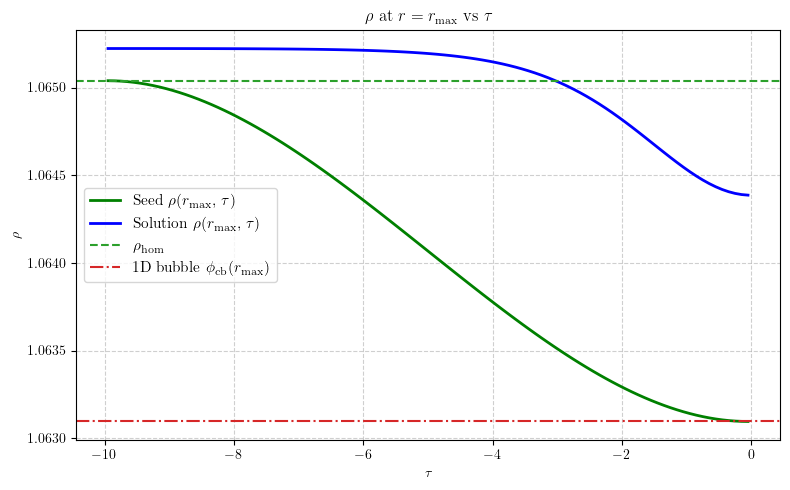

In [19]:
# ρ(r=r_max, τ) vs τ: solution, seed (the one given to Newton), 1D bubble at r_max, and homogeneous
# Rebuild seed ρ from best_x0 with the SAME (ω_ref, ρ_ref) used when building the ansatz (OMEGA, rho_hom),
# so the curve matches the other seed plot. Do NOT use solver_newton.phi (it uses ω̃, ρ̃).
x0_seed = x0_newton  # seed actually passed to Newton
y_seed_ng, ybar_seed_ng = solver_newton.unpack(x0_seed)
# Use solver_newton.phi so seed rho is identical to iteration_history (iter 0)
phi_seed_ng, phibar_seed_ng = solver_newton.phi(y_seed_ng, ybar_seed_ng)
rho_seed_ng = np.sqrt(np.maximum((phi_seed_ng * phibar_seed_ng).real + getattr(solver_newton.settings, 'rho_eps', 1e-12), 0.0))
r_max = grid_newton.r[-1]
rho_at_rmax = rho_sol[-1, :]
rho_seed_at_rmax = rho_seed_ng[-1, :]
rho_hom = float(phi_false_bounce)
#phi_1d_at_rmax = np.interp(r_max, r_bounce, phi_bounce) if "r_bounce" in globals() and r_bounce is not None else None

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(grid_newton.tau, rho_seed_at_rmax, "g", lw=2, label=r"Seed $\rho(r_{\max},\, \tau)$")
ax.plot(grid_newton.tau, rho_at_rmax, "b-", lw=2, label=r"Solution $\rho(r_{\max},\, \tau)$")
ax.axhline(rho_hom, color="C2", ls="--", lw=1.5, label=r"$\rho_{\mathrm{hom}}$")
if phi_bubble_at_rmax is not None:
    ax.axhline(phi_bubble_at_rmax, color="C3", ls="-.", lw=1.5, label=r"1D bubble $\phi_{\mathrm{cb}}(r_{\max})$")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$\rho$")
ax.set_title(r"$\rho$ at $r = r_{\max}$ vs $\tau$")
ax.legend(fontsize=11)
ax.grid(True, ls="--", alpha=0.6)
plt.tight_layout()
plt.show()

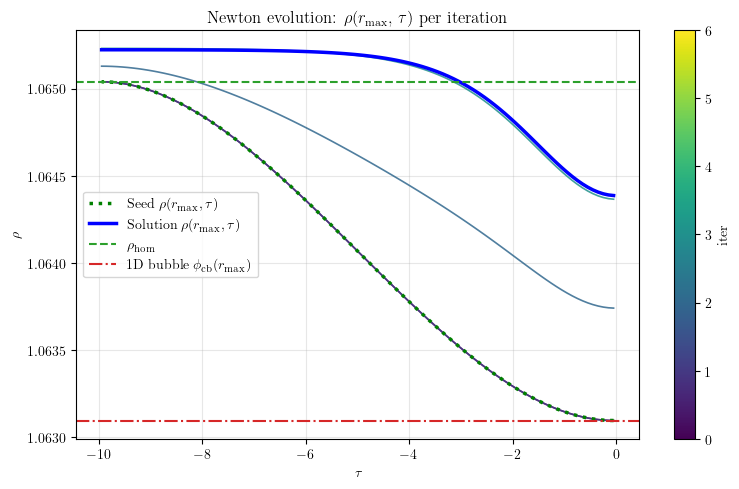

In [20]:
# Newton evolution at r = r_max: ρ(r_max, τ) per iteration
iteration_history = getattr(newton_result, "iteration_history", None) or []
if iteration_history:
    tau = grid_newton.tau
    n_iter = len(iteration_history)
    cmap = plt.cm.viridis
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, it in enumerate(iteration_history):
        rho_it = it["rho"]   # shape (Nr, Nt)
        rho_rmax = rho_it[-1, :]
        color = cmap(i / max(n_iter - 1, 1))
        ax.plot(tau, rho_rmax, color=color, lw=1.2, alpha=0.85)
    # Seed a r_max
    x0_seed = x0_newton
    y_seed_ng, ybar_seed_ng = solver_newton.unpack(x0_seed)
    phi_seed_ng, phibar_seed_ng = solver_newton.phi(y_seed_ng, ybar_seed_ng)
    rho_seed_ng = np.sqrt(np.maximum((phi_seed_ng * phibar_seed_ng).real + getattr(solver_newton.settings, 'rho_eps', 1e-12), 0.0))
    rho_seed_at_rmax = rho_seed_ng[-1, :]
    ax.plot(tau, rho_seed_at_rmax, "g", lw=2.5, ls=":", label=r"Seed $\rho(r_{\max},\tau)$")
    ax.plot(tau, rho_sol[-1, :], "b-", lw=2.5, label=r"Solution $\rho(r_{\max},\tau)$")
    ax.axhline(rho_hom, color="C2", ls="--", lw=1.5, label=r"$\rho_{\mathrm{hom}}$")
    if phi_bubble_at_rmax is not None:
        ax.axhline(phi_bubble_at_rmax, color="C3", ls="-.", lw=1.5, label=r"1D bubble $\phi_{\mathrm{cb}}(r_{\max})$")
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$\rho$")
    ax.set_title(r"Newton evolution: $\rho(r_{\max},\, \tau)$ per iteration")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, n_iter - 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label="iter")
    ax.legend(loc="best", fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Nessuna storia iterazioni; rieseguire solve con store_iteration_history=True.")

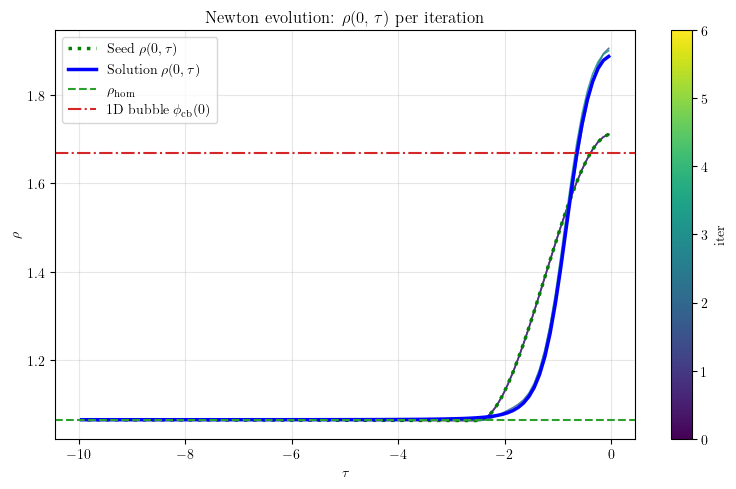

In [21]:
# Same plot but at slice r = 0: evolution ρ(0, τ) vs τ
iteration_history = getattr(newton_result, "iteration_history", None) or []
if iteration_history:
    tau = grid_newton.tau
    n_iter = len(iteration_history)
    cmap = plt.cm.viridis
    fig, ax = plt.subplots(figsize=(8, 5))
    for i, it in enumerate(iteration_history):
        rho_it = it["rho"]   # shape (Nr, Nt)
        rho_r0 = rho_it[0, :]
        color = cmap(i / max(n_iter - 1, 1))
        ax.plot(tau, rho_r0, color=color, lw=1.2, alpha=0.85)
    # Seed a r=0
    x0_seed = x0_newton
    y_seed_ng, ybar_seed_ng = solver_newton.unpack(x0_seed)
    phi_seed_ng, phibar_seed_ng = solver_newton.phi(y_seed_ng, ybar_seed_ng)
    rho_seed_ng = np.sqrt(np.maximum((phi_seed_ng * phibar_seed_ng).real + getattr(solver_newton.settings, 'rho_eps', 1e-12), 0.0))
    rho_seed_at_r0 = rho_seed_ng[0, :]
    ax.plot(tau, rho_seed_at_r0, "g", lw=2.5, ls=":", label=r"Seed $\rho(0,\tau)$")
    ax.plot(tau, rho_sol[0, :], "b-", lw=2.5, label=r"Solution $\rho(0,\tau)$")
    ax.axhline(rho_hom, color="C2", ls="--", lw=1.5, label=r"$\rho_{\mathrm{hom}}$")
    if phi0_bounce is not None:
        ax.axhline(phi0_bounce, color="C3", ls="-.", lw=1.5, label=r"1D bubble $\phi_{\mathrm{cb}}(0)$")
    ax.set_xlabel(r"$\tau$")
    ax.set_ylabel(r"$\rho$")
    ax.set_title(r"Newton evolution: $\rho(0,\, \tau)$ per iteration")
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, n_iter - 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label="iter")
    ax.legend(loc="best", fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("Nessuna storia iterazioni; rieseguire solve con store_iteration_history=True.")

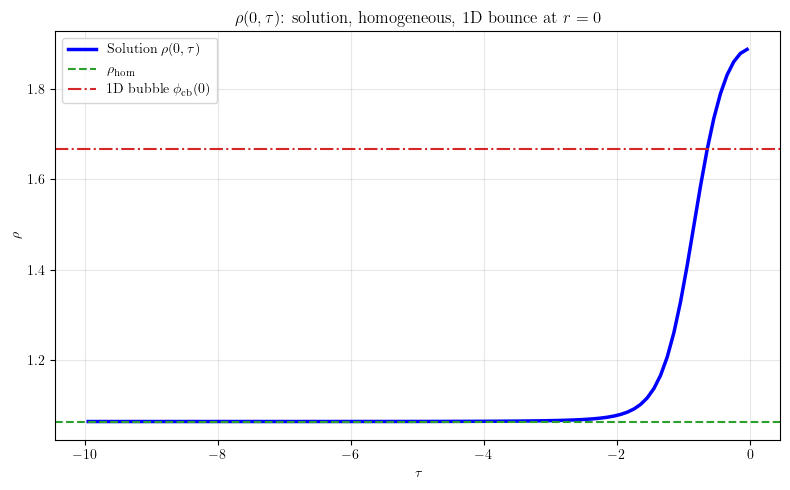

In [22]:
# ρ(0, τ): only ρ_hom, solution ρ(0,τ), and 1D bubble φ(0)
tau = grid_newton.tau
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(tau, rho_sol[0, :], "b-", lw=2.5, label=r"Solution $\rho(0, \tau)$")
ax.axhline(rho_hom, color="C2", ls="--", lw=1.5, label=r"$\rho_{\mathrm{hom}}$")
if phi0_bounce is not None:
    ax.axhline(phi0_bounce, color="C3", ls="-.", lw=1.5, label=r"1D bubble $\phi_{\mathrm{cb}}(0)$")
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$\rho$")
ax.set_title(r"$\rho(0, \tau)$: solution, homogeneous, 1D bounce at $r=0$")
ax.legend(loc="best", fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

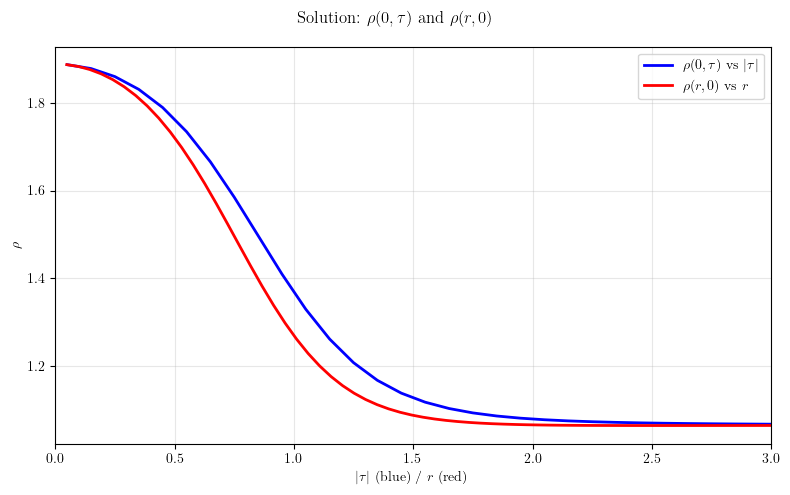

In [23]:
# Same plot: ρ(0, τ) vs |τ| and ρ(r, 0) vs r — both x from 0 to 10
if newton_result is not None and getattr(newton_result, "newton", None) is not None:
    y_sol, ybar_sol = solver_newton.unpack(newton_result.newton.x)
    rho_sol_2d = solver_newton.rho_map(y_sol, ybar_sol)
    r_plt = np.asarray(grid_newton.r, float)
    tau_plt = np.asarray(grid_newton.tau, float)

    x_max = 3.0
    abs_tau = np.abs(tau_plt)
    # ρ(0, τ) vs |τ|: sort so x increases (|τ| from 0 to ...)
    idx_tau = np.argsort(abs_tau)
    x_tau, rho_tau = abs_tau[idx_tau], rho_sol_2d[0, :][idx_tau]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(x_tau, rho_tau, "b-", lw=2, label=r"$\rho(0, \tau)$ vs $|\tau|$")
    ax.plot(r_plt, rho_sol_2d[:, 0], "r-", lw=2, label=r"$\rho(r, 0)$ vs $r$")
    ax.set_xlim(0, x_max)
    ax.set_ylabel(r"$\rho$")
    ax.set_xlabel(r"$|\tau|$ (blue) / $r$ (red)")
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    fig.suptitle(r"Solution: $\rho(0,\tau)$ and $\rho(r,0)$")
    plt.tight_layout()
    plt.show()
else:
    print("Newton result not available; run Newton solve first.")

## Scan $\eta_0$ to match charge with homogeneous

**Goal:** choose $\eta_0$ so that the 2D charge of the converged solution equals the homogeneous charge $Q_{\mathrm{hom}}$ (same volume and same $\omega$).

We start from the converged Newton solution (section 6). The charge $Q$ is computed at $\tau=0$ with the ghost procedure (`compute_charge_tau0_ghost_2d`). We vary $\eta_0$ (e.g. increase by step $\texttt{d\_eta}$ until $Q \ge Q_{\mathrm{target}}$) and **bisect** in the resulting interval until $Q = Q_{\mathrm{hom}}$ within tolerance. The solution at $\eta_0 = \eta_0^*$ is the charge-matched one; it is stored in $\texttt{sol\_eta}$ and used for the $\beta$ and $L_r$ scans.


In [24]:
# ============================================================================
# Scan eta0 to match Q with Q_hom (charge increases with eta0)
# ============================================================================
# Uses: solver_newton, newton_result, ETA0 from section 6; Q_hom from homogeneous charge.
# Step 1: if Q < Q_target, increase eta0 by d_eta and solve; repeat until Q >= Q_target.
# Step 2: when Q crosses target, bracket and bisect to find eta*.

from Bubble_finder.bounce2d import NewtonConvergenceError
from scipy.optimize import brentq

Q_target_eta = Q_hom if "Q_hom" in dir() else float(solver_newton.rho0) * 1.0
d_eta = 0.2
max_scan_steps = 40
tol_Q = 1e-6 * max(1.0, abs(Q_target_eta))

def solve_at_eta(solver, eta, x0):
    solver.settings.eta0 = float(eta)
    solver.eta0 = float(eta)
    sol = solver.solve(x0, verbose=False)
    return float(sol.Q_tau0.real), sol

x_seed = np.array(newton_result.x, copy=True)
eta_curr = float(ETA0)
Q_curr, sol_curr = solve_at_eta(solver_newton, eta_curr, x_seed)
x_seed = sol_curr.x

print(f"Target Q = {Q_target_eta:.6f}, d_eta = {d_eta}")
print(f"Initial: eta0 = {eta_curr:.6f}, Q = {Q_curr:.6f}")

# Step 1: step in eta until we cross Q_target
eta_prev, Q_prev = eta_curr, Q_curr
bracket_found = False
for step in range(max_scan_steps):
    if abs(Q_curr - Q_target_eta) < tol_Q:
        eta_star = eta_curr
        sol_eta = sol_curr
        Q_final = Q_curr
        print(f"Already at target after {step} steps.")
        bracket_found = False
        break
    if Q_curr < Q_target_eta:
        eta_prev, Q_prev = eta_curr, Q_curr
        eta_curr += d_eta
        Q_curr, sol_curr = solve_at_eta(solver_newton, eta_curr, x_seed)
        x_seed = sol_curr.x
        print(f"  step {step+1}: eta={eta_curr:.4f}, Q={Q_curr:.6f}")
        if Q_curr >= Q_target_eta:
            eta_lo, eta_hi = eta_prev, eta_curr
            bracket_found = True
            break
    else:
        eta_prev, Q_prev = eta_curr, Q_curr
        eta_curr -= d_eta
        Q_curr, sol_curr = solve_at_eta(solver_newton, eta_curr, x_seed)
        x_seed = sol_curr.x
        print(f"  step {step+1}: eta={eta_curr:.4f}, Q={Q_curr:.6f}")
        if Q_curr <= Q_target_eta:
            eta_lo, eta_hi = eta_curr, eta_prev
            bracket_found = True
            break
else:
    raise RuntimeError("Scan did not cross Q_target within max_scan_steps.")

# Step 2: bisection (only if we crossed the target)
if bracket_found:
    state = {"x_seed": x_seed.copy(), "sol_curr": sol_curr}
    def f_eta(eta):
        q, s = solve_at_eta(solver_newton, eta, state["x_seed"])
        state["x_seed"] = s.x
        state["sol_curr"] = s
        return q - Q_target_eta

    eta_star = float(brentq(f_eta, eta_lo, eta_hi, xtol=1e-10))
    sol_eta = state["sol_curr"]
    Q_final = float(sol_eta.Q_tau0.real)

print(f"\nEta scan completed: eta* = {eta_star:.6f}")
print(f"  Q(eta*) = {Q_final:.6f}  (target {Q_target_eta:.6f}, ratio {Q_final/Q_target_eta:.6f})")
print(f"  E(eta*) = {float(sol_eta.E_tau0):.6f}  (energy τ=0 ghost)")
print(f"  Newton: success={sol_eta.success}, ||F||={sol_eta.residual_norm:.4e}")


--- Diagnostics (τ=0 ghost) ---
  Q = 2.315061e+02  (target: 231.04889899330254, ratio: 1.0020)
  E = 3.244395e+00  (target: 1.7315952381809756e-10, ratio: 18736449616.5775)
  rho_Q = 9.660673e-01  (target: 0.9641595717003983, ratio: 1.0020)
  rho_E = 1.353875e-02  (target: 7.225890841624023e-13, ratio: 18736449616.5775)
  q_max = 2.278e+00  at r = 0.0482
  e_max = 1.538e+00  at r = 0.7706
  Sanity (η0=0): ||F||=1.502e-05, ω²−W(ρ0)=2.483e-08

Target Q = 231.049350, d_eta = 0.2
Initial: eta0 = 0.000000, Q = 231.506066

--- Diagnostics (τ=0 ghost) ---
  Q = 2.281819e+02  (target: 231.04889899330254, ratio: 0.9876)
  E = -2.225190e+00  (target: 1.7315952381809756e-10, ratio: -12850522229.7611)
  rho_Q = 9.521956e-01  (target: 0.9641595717003983, ratio: 0.9876)
  rho_E = -9.285647e-03  (target: 7.225890841624023e-13, ratio: -12850522229.7611)
  q_max = 2.260e+00  at r = 0.0482
  e_max = 1.523e+00  at r = 0.7706
  Sanity (η0=0): ||F||=1.502e-05, ω²−W(ρ0)=2.483e-08

  step 1: eta=-0.2000, Q

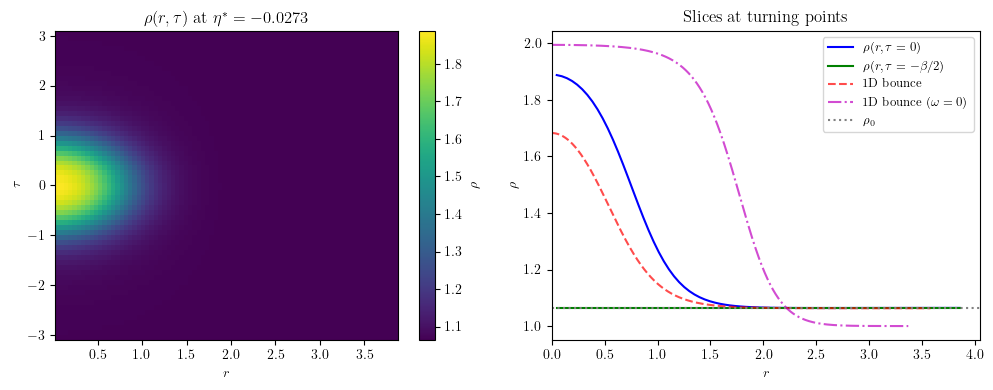

In [25]:
# Plot solution from eta0 scan (Q-matched at eta*) — extended by symmetry τ → −τ
rho_eta = solver_newton.rho_map(sol_eta.y, sol_eta.ybar)
r_plt = np.asarray(solver_newton.grid.r, float)
tau_plt = np.asarray(solver_newton.grid.tau, float)
# Grid has tau from 0 to -β/2 (tau_plt[0]≈0, tau_plt[-1]≈-3.1). We order τ increasing from -3.1 to 3.1.
tau_neg = tau_plt[::-1]
rho_neg = rho_eta[:, ::-1]
tau_pos = (-tau_plt[-2::-1])[::-1][1:]
rho_pos = rho_eta[:, -2::-1][:, ::-1][:, 1:]
tau_sym = np.concatenate([tau_neg, tau_pos])
rho_sym = np.concatenate([rho_neg, rho_pos], axis=1)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
im = axes[0].pcolormesh(r_plt, tau_sym, rho_sym.T, shading="auto", cmap="viridis")
axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\tau$")
axes[0].set_ylim(-3.1, 3.1)
axes[0].set_title(r"$\rho(r,\tau)$ at $\eta^*={:.4f}$".format(eta_star))
plt.colorbar(im, ax=axes[0], label=r"$\rho$")

axes[1].plot(r_plt, rho_eta[:, 0], "b-", lw=1.5, label=r"$\rho(r,\tau=0)$")
axes[1].plot(r_plt, rho_eta[:, -1], "g-", lw=1.5, label=r"$\rho(r,\tau=-\beta/2)$")
r_cb = r_1d if "r_1d" in dir() else globals().get("r_bounce")
phi_cb = phi_1d if "phi_1d" in dir() else globals().get("phi_bounce")
if r_cb is not None and phi_cb is not None:
    axes[1].plot(r_cb, phi_cb, "r--", alpha=0.7, label="1D bounce")
if "r_bubble_zero_charge" in globals() and r_bubble_zero_charge is not None:
    axes[1].plot(r_bubble_zero_charge, phi_bubble_zero_charge, "m-.", lw=1.5, alpha=0.7, label=r"1D bounce ($\omega=0$)")
axes[1].axhline(float(solver_newton.rho0), color="gray", ls=":", label=r"$\rho_0$")
axes[1].set_xlabel(r"$r$")
axes[1].set_ylabel(r"$\rho$")
axes[1].set_title("Slices at turning points")
axes[1].legend(fontsize=9)
axes[1].set_xlim(0, None)
plt.tight_layout()
plt.show()

Plot saved to: /home/giulio/Madrid - PostDoc/Projects/Finite Density Vacuum decay/BubbleX/Bubble_finder/notebooks/3D_solution.pdf


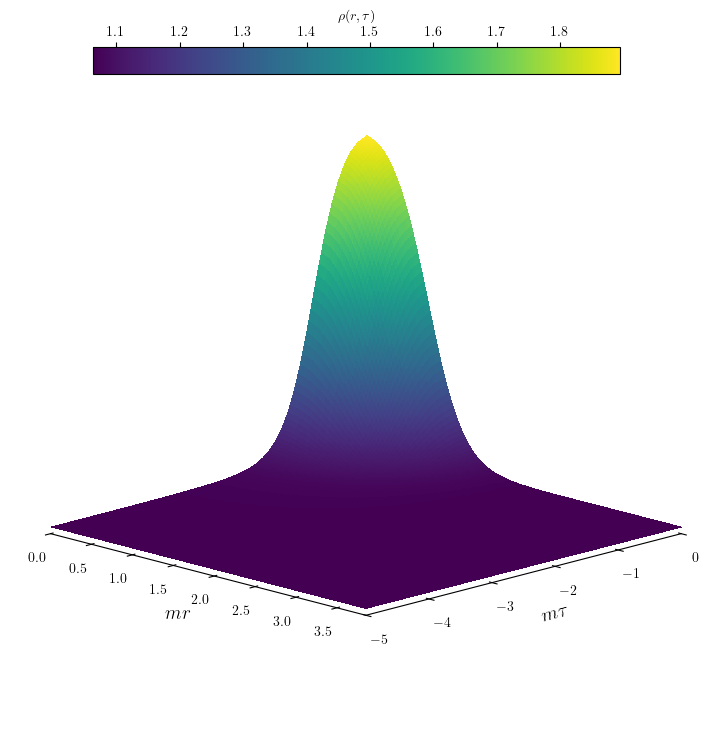

In [26]:
# --- 3D surface plot: resample rho to finer grid (adapted from Q-ball notebook) ---
from scipy.interpolate import RegularGridInterpolator
from mpl_toolkits.mplot3d import Axes3D

solution_plot = sol_eta
grid_orig = solver_newton.grid
rho_orig = solver_newton.rho_map(sol_eta.y, sol_eta.ybar)
r_old = np.asarray(grid_orig.r, float)
tau_old = np.asarray(grid_orig.tau, float)

# Finer grid: r_max as before, tau from -5 to 0
Lr_fine = min(10.0, float(r_old.max()))
Nr_fine = 300
Ntau_fine = 300
dr_fine = Lr_fine / Nr_fine
r_new = dr_fine * (np.arange(Nr_fine) + 1.0)
tau_new = np.linspace(-5.0, 0.0, Ntau_fine)

# Resample rho with extrapolation
interp = RegularGridInterpolator(
    (r_old, tau_old), rho_orig,
    bounds_error=False, fill_value=None, method="linear"
)
R_new, T_new = np.meshgrid(r_new, tau_new, indexing="ij")
points_new = np.stack([R_new, T_new], axis=-1)
rho_fine = interp(points_new)

# Filter r>0
mask_r = r_new > 0
r_plot = r_new[mask_r]
rho_plot = rho_fine[mask_r, :]
R_3d, T_3d = np.meshgrid(r_plot, tau_new, indexing="xy")

fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection="3d")
surf = ax.plot_surface(R_3d, T_3d, rho_plot.T, cmap="viridis",
                       linewidth=0, antialiased=False, alpha=1, edgecolor="none", shade=False, rcount=200, ccount=200)
ax.set_xlabel(r"$mr$", fontsize=14)
ax.set_ylabel(r"$m\tau$", fontsize=14)
ax.set_zlabel("")
ax.set_zticks([])
ax.set_zticklabels([])
ax.zaxis.line.set_linewidth(0.0)
ax.zaxis.pane.set_visible(False)
ax.zaxis.set_visible(False)
ax.xaxis.pane.set_visible(False)
ax.yaxis.pane.set_visible(False)
ax.zaxis.pane.set_visible(False)
ax.grid(False)
ax.set_xlim(0 * r_plot.min(), min(10.0, r_plot.max()))
ax.set_ylim(tau_new.min(), 0)
cbar = fig.colorbar(surf, ax=ax, orientation="horizontal", location="top", shrink=0.45, aspect=20, pad=-0.05, label=r"$\rho(r, \tau)$")
ax.set_proj_type("ortho")
ax.view_init(elev=15, azim=-45)
plt.tight_layout()
pdf_path = PROJECT_ROOT / "Bubble_finder" / "notebooks" / "3D_solution.pdf"
plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
print(f"Plot saved to: {pdf_path}")
plt.show()

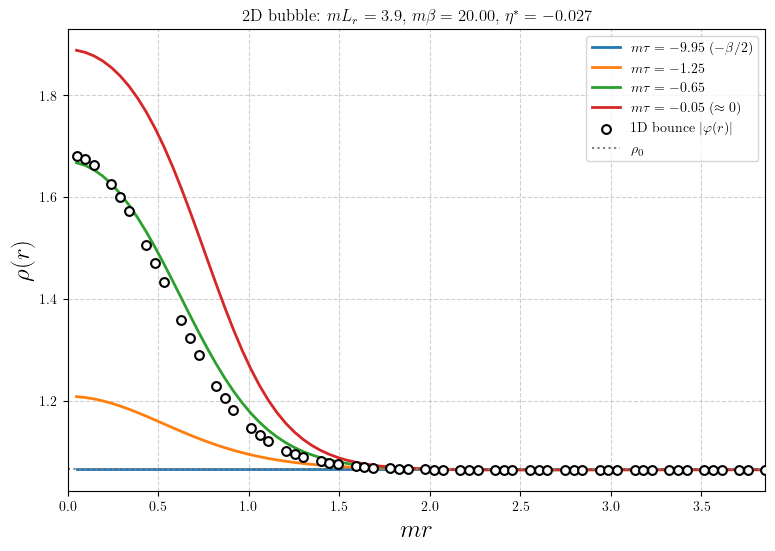

In [27]:
# --- Plot: bubble 2D solution slices at different tau vs 1D bounce ---
solution_plot_last = sol_eta
grid_plot_last = solver_newton.grid
r_slice_last = np.asarray(grid_plot_last.r, float)
tau_grid = np.asarray(grid_plot_last.tau, float)

tau_idx_min_last = int(np.argmin(tau_grid))
tau_min_last = tau_grid[tau_idx_min_last]

# Target tau values for slices (e.g. -beta/4, -beta/8)
beta_used = solver_newton.settings.beta
tau_mb4 = -beta_used / 16
tau_mb8 = -beta_used / 32
tau_targets = [tau_min_last, tau_mb4, tau_mb8, tau_grid[-1]]
tau_indices = {}
tau_values = {}
for tau_target in tau_targets:
    idx = int(np.argmin(np.abs(tau_grid - tau_target)))
    tau_indices[tau_target] = idx
    tau_values[tau_target] = tau_grid[idx]

rho_2d = solver_newton.rho_map(sol_eta.y, sol_eta.ybar)

def extract_rho_slice(idx):
    return rho_2d[:, idx]

rho_slice_tau_min = extract_rho_slice(tau_idx_min_last)
rho_slice_tau_mb4 = extract_rho_slice(tau_indices[tau_mb4])
rho_slice_tau_mb8 = extract_rho_slice(tau_indices[tau_mb8])
# tau_grid[0] is closest to 0, tau_grid[-1] is closest to -beta/2
rho_slice_tau0 = extract_rho_slice(0)

# 1D bounce reference
r_cb = r_1d if "r_1d" in dir() else globals().get("r_bounce")
phi_cb = phi_1d if "phi_1d" in dir() else globals().get("phi_bounce")
if r_cb is not None and phi_cb is not None:
    rho_bounce_interp = np.interp(r_slice_last, np.asarray(r_cb, float), np.asarray(phi_cb, float))
else:
    rho_bounce_interp = None

fig, ax = plt.subplots(figsize=(9, 6))
ax.plot(r_slice_last, rho_slice_tau_min, lw=2.0, linestyle="-", label=rf"$m\tau = {tau_min_last:.2f}$ ($-\beta/2$)")
ax.plot(r_slice_last, rho_slice_tau_mb4, lw=2.0, linestyle="-", label=rf"$m\tau = {tau_values[tau_mb4]:.2f}$")
ax.plot(r_slice_last, rho_slice_tau_mb8, lw=2.0, linestyle="-", label=rf"$m\tau = {tau_values[tau_mb8]:.2f}$")
ax.plot(r_slice_last, rho_slice_tau0, lw=2.0, linestyle="-", label=rf"$m\tau = {tau_grid[0]:.2f}$ ($\approx 0$)")
if rho_bounce_interp is not None:
    n_points = 60
    indices = np.linspace(0, len(r_slice_last) - 1, n_points, dtype=int)
    ax.scatter(r_slice_last[indices], rho_bounce_interp[indices], marker="o", s=40,
               facecolors="white", edgecolors="black", linewidths=1.5, label=r"1D bounce $|\varphi(r)|$", zorder=5)
ax.axhline(float(solver_newton.rho0), color="gray", ls=":", label=r"$\rho_0$")
ax.set_xlabel(r"$mr$", fontsize=18)
ax.set_ylabel(r"$\rho(r)$", fontsize=18)
ax.set_xlim(0, min(10, np.max(r_slice_last)))
Lr_plot = getattr(grid_plot_last, "Lr", None)
if Lr_plot is None:
    Lr_plot = float(grid_plot_last.dr * grid_plot_last.Nr)
else:
    Lr_plot = float(Lr_plot)
ax.set_title(rf"2D bubble: $mL_r={Lr_plot:.1f}$, $m\beta={beta_used:.2f}$, $\eta^*={eta_star:.3f}$")
ax.grid(True, ls="--", alpha=0.6)
ax.legend()
#pdf_path = PROJECT_ROOT / "Bubble_finder" / "notebooks" / "slices_solutions.pdf"
#plt.savefig(pdf_path, format="pdf", dpi=300, bbox_inches="tight")
#print(f"Plot saved to: {pdf_path}")
plt.show()

## Beta scan (continuation in $\beta$)

We increase **$\beta$** (maximum Euclidean time $|\tau| \le \beta/2$) from the current value up to a maximum (e.g. $200$) in fixed steps (e.g. $5$). For each $\beta$:

1. Build a new grid with the same $L_r$ but $N_\tau$ adapted to $\beta$.
2. The initial ansatz is the **previous solution** resampled on the new grid (`resample_complex_field` or equivalent).
3. Run Newton; then perform an **$\eta_0$ scan** (step e.g. $0.02$) until $Q = Q_{\mathrm{hom}}$.

The **targets** $Q_{\mathrm{target}}$, $E_{\mathrm{target}}$ for comparison are computed with `compute_targets_tau0_ghost` on the homogeneous configuration on the same grid.


In [28]:
# ========== Target diagnostics: charge, energy, density ==========
# Targets from homogeneous config (y=ȳ=0) via same τ=0 ghost observables on same grid
from Bubble_finder.observables_2d import compute_targets_tau0_ghost

targets_diag = compute_targets_tau0_ghost(solver_newton, subtract_background_charge=False, subtract_background_energy=True)
Q_target_diag = targets_diag["Q"]
E_target_diag = targets_diag["E"]
# True Lr and V from the grid used for targets (solver_newton): Lr = dr*Nr
Lr_diag = float(solver_newton.grid.dr * solver_newton.grid.Nr)
V_diag = (4.0 / 3.0) * np.pi * (Lr_diag**3)
rho_Q_target = Q_target_diag / V_diag if V_diag > 0 else 0.0
rho_E_target = E_target_diag / V_diag if V_diag > 0 else 0.0
print("=== Target (expected values for scans) ===")
print(f"  Q_target   = {Q_target_diag:.6f}")
print(f"  E_target   = {E_target_diag:.6f}  (from compute_targets_tau0_ghost)")
print(f"  Lr         = {Lr_diag:.6f}  (true: dr×Nr)")
print(f"  V          = (4/3)π Lr³ = {V_diag:.6f}")
print(f"  ρ_Q_target = Q/V = {rho_Q_target:.6e}")
print(f"  ρ_E_target = E/V = {rho_E_target:.6e}")

=== Target (expected values for scans) ===
  Q_target   = 231.048899
  E_target   = 0.000000  (from compute_targets_tau0_ghost)
  Lr         = 3.853205  (true: dr×Nr)
  V          = (4/3)π Lr³ = 239.637614
  ρ_Q_target = Q/V = 9.641596e-01
  ρ_E_target = E/V = 7.225891e-13


In [29]:
# ============================================================================
# Beta scan: beta -> 200, step 5; for each beta: Newton + eta0 scan (d_eta=0.02)
# ============================================================================
from Q_ball_finder.notebook_utils import resample_complex_field
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver, NewtonConvergenceError
from Bubble_finder.observables_2d import compute_targets_tau0_ghost
from scipy.optimize import brentq

def compute_ntau_for_beta(beta_i, beta_ref, ntau_ref):
    """Ntau to keep dtau ~ constant."""
    dtau_target = beta_ref / (2.0 * ntau_ref)
    return int(round(0.5 * beta_i / dtau_target))

def solve_at_eta(solver, eta, x0, verbose=False):
    solver.settings.eta0 = float(eta)
    solver.eta0 = float(eta)
    sol = solver.solve(x0, verbose=verbose, verbose_success_block=False)
    return float(sol.Q_tau0.real), sol

def _density_summary(r, q_r, e_r):
    """Return q_max, r_at_q_max, e_max, r_at_e_max from density profiles."""
    if q_r is None or q_r.size == 0:
        return 0.0, 0.0, 0.0, 0.0
    q_max = float(np.max(np.abs(q_r)))
    e_max = float(np.max(np.abs(e_r))) if e_r is not None and e_r.size else 0.0
    r_at_q_max = float(r[int(np.argmax(np.abs(q_r)))])
    r_at_e_max = float(r[int(np.argmax(np.abs(e_r)))]) if e_r is not None and e_r.size else 0.0
    return q_max, r_at_q_max, e_max, r_at_e_max

def eta_scan_at_beta(solver, eta_start, x_seed, Q_target, d_eta=0.02, max_steps=80, tol_Q=1e-6, verbose=True):
    """Eta scan to match Q = Q_target. Returns (eta_star, sol, x_seed, dens_info).
    dens_info = dict with Q, E, q_r, e_r, r, q_max, e_max, r_at_q_max, r_at_e_max."""
    tol_Q = tol_Q * max(1.0, abs(Q_target))
    eta_cache = {}
    eta_cache_precision = 1e-12
    E_Q_ref = solver.omega * Q_target if Q_target else 1.0

    eta_curr = eta_start
    Q_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
    x_seed = sol_curr.x.copy()
    E_curr = float(sol_curr.E_tau0)
    ratioQ = Q_curr / Q_target if Q_target else 0.0
    ratioE = E_curr / E_Q_ref if E_Q_ref else 0.0
    eta_cache[round(eta_curr / eta_cache_precision) * eta_cache_precision] = (Q_curr, E_curr, ratioQ, ratioE)
    if abs(Q_curr - Q_target) < tol_Q:
        Q_g, q_r = solver.compute_charge_tau0_ghost(sol_curr.y, sol_curr.ybar, subtract_background=False, return_profile=True)
        E_g, e_r = solver.compute_energy_tau0_ghost(sol_curr.y, sol_curr.ybar, subtract_background=True, return_profile=True)
        r = np.asarray(solver.grid.r, float)
        q_max, r_q, e_max, r_e = _density_summary(r, q_r, e_r)
        dens_info = dict(Q=Q_curr, E=E_curr, q_r=q_r, e_r=e_r, r=r, q_max=q_max, e_max=e_max, r_at_q_max=r_q, r_at_e_max=r_e)
        if verbose:
            print(f"[eta-scan] eta* = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, ratioQ = {ratioQ:.6f}, ratioE = {ratioE:.6f}")
        return eta_curr, sol_curr, x_seed, dens_info
    if verbose:
        print(f"[eta-scan] eta = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, target = {Q_target:.6e}, ratioQ = {ratioQ:.6f}")
    eta_prev, Q_prev = eta_curr, Q_curr
    for _ in range(max_steps):
        if Q_curr < Q_target:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr += d_eta
        else:
            eta_prev, Q_prev = eta_curr, Q_curr
            eta_curr -= d_eta
        Q_curr, sol_curr = solve_at_eta(solver, eta_curr, x_seed, verbose=False)
        x_seed = sol_curr.x.copy()
        E_curr = float(sol_curr.E_tau0)
        ratioQ = Q_curr / Q_target if Q_target else 0.0
        ratioE = E_curr / E_Q_ref if E_Q_ref else 0.0
        eta_cache[round(eta_curr / eta_cache_precision) * eta_cache_precision] = (Q_curr, E_curr, ratioQ, ratioE)
        if verbose:
            print(f"[eta-scan] try eta = {eta_curr:.6f}, charge = {Q_curr:.6e}, energy = {E_curr:.6e}, ratioQ = {ratioQ:.6f}, ratioE = {ratioE:.6f}")
        if (Q_prev - Q_target) * (Q_curr - Q_target) <= 0:
            break
    else:
        raise RuntimeError("eta scan did not cross Q_target")
    eta_lo, eta_hi = (eta_prev, eta_curr) if Q_prev < Q_target else (eta_curr, eta_prev)
    state = {"x_seed": x_seed}

    def f_eta(eta):
        eta_f = float(eta)
        key = round(eta_f / eta_cache_precision) * eta_cache_precision
        if key in eta_cache:
            q, e, rq, re = eta_cache[key]
            if verbose:
                print(f"[eta-root] eta = {eta_f:.6f} (cached), charge = {q:.6e}, energy = {e:.6e}, ratioQ = {rq:.6f}, ratioE = {re:.6f}")
            return q - Q_target
        q, s = solve_at_eta(solver, eta_f, state["x_seed"], verbose=False)
        state["x_seed"] = s.x.copy()
        e = float(s.E_tau0)
        rq = q / Q_target if Q_target else 0.0
        re = e / E_Q_ref if E_Q_ref else 0.0
        eta_cache[key] = (q, e, rq, re)
        if verbose:
            print(f"[eta-root] eta = {eta_f:.6f}, charge = {q:.6e}, energy = {e:.6e}, ratioQ = {rq:.6f}, ratioE = {re:.6f}")
        return q - Q_target

    eta_star = float(brentq(f_eta, eta_lo, eta_hi, xtol=1e-10))
    _, sol_final = solve_at_eta(solver, eta_star, state["x_seed"], verbose=False)
    x_seed = sol_final.x.copy()
    Q_final = float(sol_final.Q_tau0.real)
    E_final = float(sol_final.E_tau0)
    ratioQ_f = Q_final / Q_target if Q_target else 0.0
    ratioE_f = E_final / E_Q_ref if E_Q_ref else 0.0
    Q_g, q_r = solver.compute_charge_tau0_ghost(sol_final.y, sol_final.ybar, subtract_background=False, return_profile=True)
    E_g, e_r = solver.compute_energy_tau0_ghost(sol_final.y, sol_final.ybar, subtract_background=True, return_profile=True)
    r = np.asarray(solver.grid.r, float)
    q_max, r_q, e_max, r_e = _density_summary(r, q_r, e_r)
    dens_info = dict(Q=Q_final, E=E_final, q_r=q_r, e_r=e_r, r=r, q_max=q_max, e_max=e_max, r_at_q_max=r_q, r_at_e_max=r_e)
    if verbose:
        print(f"[eta-scan] eta* = {eta_star:.6f}, charge = {Q_final:.6e}, energy = {E_final:.6e}, ratioQ = {ratioQ_f:.6f}, ratioE = {ratioE_f:.6f}")
    return eta_star, sol_final, x_seed, dens_info

# Parametri
Q_target_beta = Q_hom
beta_start = float(BETA_USED)
beta_end = 55
beta_step = 5
d_eta_beta = 0.02
beta_ref = beta_start
ntau_ref = int(sol_eta.grid.Ntau)
nr_ref = int(sol_eta.grid.Nr)
lr_ref = float(sol_eta.grid.dr * sol_eta.grid.Nr)

# Stato iniziale: compute density profiles for initial solution
def _get_dens_info(solver, sol):
    """Extract Q, E and density profiles from solution. Q total, E excess (matches sol.E_tau0)."""
    Q = float(sol.Q_tau0.real)
    E = float(sol.E_tau0)
    Q_g, q_r = solver.compute_charge_tau0_ghost(sol.y, sol.ybar, subtract_background=False, return_profile=True)
    E_g, e_r = solver.compute_energy_tau0_ghost(sol.y, sol.ybar, subtract_background=True, return_profile=True)
    r = np.asarray(solver.grid.r, float)
    q_max, r_q, e_max, r_e = _density_summary(r, q_r, e_r)
    return dict(Q=Q, E=E, q_r=q_r, e_r=e_r, r=r, q_max=q_max, e_max=e_max, r_at_q_max=r_q, r_at_e_max=r_e)

sol_beta = sol_eta
eta_beta = eta_star
dens_initial = _get_dens_info(solver_newton, sol_eta)
E_2d_0 = float(solver_newton.compute_energy_tau0_ghost(sol_eta.y, sol_eta.ybar, subtract_background=False))
x_bg_0 = solver_newton._zero_vec()
y_h0, yb_h0 = solver_newton.unpack(x_bg_0)
E_hom_0 = float(solver_newton.compute_energy_tau0_ghost(y_h0, yb_h0, subtract_background=False))
results_beta = [{"beta": beta_start, "eta": eta_beta, "Q": float(sol_beta.Q_tau0.real), "E": float(sol_beta.E_tau0),
                 "E_2d": E_2d_0, "E_hom": E_hom_0,
                 "sol": sol_beta, "q_r": dens_initial["q_r"], "e_r": dens_initial["e_r"], "r": dens_initial["r"],
                 "q_max": dens_initial["q_max"], "e_max": dens_initial["e_max"]}]

beta_values = list(np.arange(beta_start + beta_step, beta_end + 0.5, beta_step))
N_steps = len(beta_values)

print(f"Beta scan: {beta_start} -> {beta_end} (step {beta_step}), Q_target={Q_target_beta:.6f}, d_eta={d_eta_beta}")
print(f"Initial: beta={beta_start}, eta*={eta_beta:.6f}, Q={float(sol_beta.Q_tau0.real):.6f}, E={float(sol_beta.E_tau0):.6f}")

for k, beta_new in enumerate(beta_values):
    ntau_new = compute_ntau_for_beta(beta_new, beta_ref, ntau_ref)
    dtau_new = float(beta_new) / (2.0 * ntau_new)
    print("")
    print("=" * 60)
    print(f"Beta scan step {k+1}/{N_steps}: β = {beta_new:.4f}")
    print("=" * 60)
    print("Strategy: Adjusting Ntau to keep dtau constant")
    print(f"Ntau = {ntau_new}, dtau = {dtau_new:.6f}")
    print("")

    settings_new = Bubble2DSettings(
        Nr=nr_ref, Ntau=ntau_new, Lr=lr_ref, beta=float(beta_new),
        eta0=eta_beta, omega_ref=solver_newton.settings.omega_ref,
        rho0=float(solver_newton.rho0), newton_tol=solver_newton.settings.newton_tol,
        newton_verbose=False
    )
    solver_b = Bubble2DSolver(settings_new, U, dU, d2U)
    r_old, tau_old = sol_beta.grid.r, sol_beta.grid.tau
    r_new, tau_new = solver_b.grid.r, solver_b.grid.tau
    y_new = resample_complex_field(sol_beta.y, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
    ybar_new = resample_complex_field(sol_beta.ybar, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
    x0 = solver_b.pack(y_new, ybar_new)

    sol_newton = solver_b.solve(x0, verbose=True, verbose_success_block=False)

    # Target Q for *this* beta (homogeneous charge on current grid); avoids wrong eta direction when grid/Ntau changes
    tgt_b = compute_targets_tau0_ghost(solver_b, subtract_background_charge=False, subtract_background_energy=True)
    Q_target_this_beta = float(tgt_b["Q"])

    eta_beta, sol_beta, _, dens_info = eta_scan_at_beta(solver_b, eta_beta, sol_newton.x.copy(), Q_target_this_beta, d_eta=d_eta_beta, verbose=True)

    Q_f = dens_info["Q"]
    E_ghost = dens_info["E"]
    E_2d = float(solver_b.compute_energy_tau0_ghost(sol_beta.y, sol_beta.ybar, subtract_background=False))
    x_bg_b = solver_b._zero_vec()
    y_hb, yb_hb = solver_b.unpack(x_bg_b)
    E_hom = float(solver_b.compute_energy_tau0_ghost(y_hb, yb_hb, subtract_background=False))
    try:
        E_slice = float(solver_b.compute_energy(sol_beta.y, sol_beta.ybar, 0))
    except Exception:
        E_slice = E_ghost
    E_Q = solver_b.omega * Q_target_this_beta

    print("")
    print(f"--- Diagnostics for β = {beta_new:.4f} ---")
    print(f"η* = {eta_beta:.6f}")
    print(f"Q = {Q_f:.6f} (target: {Q_target_this_beta:.6f}, ratio: {Q_f/Q_target_this_beta:.6f})")
    print(f"E (τ≈0 slice) = {E_slice:.6f}, E (τ=0 ghost) = {E_ghost:.6f}")
    print(f"Energy ratio (slice) = {E_slice/E_Q:.6f}, Energy ratio (ghost) = {E_ghost/E_Q:.6f}")
    print(f"Ntau = {ntau_new}, dtau = {dtau_new:.6f}")
    Lr_b = float(sol_beta.grid.dr * sol_beta.grid.Nr)
    V_b = (4.0/3.0) * np.pi * (Lr_b**3)
    rho_Q_avg = Q_f / V_b
    rho_E_avg = E_ghost / V_b
    print(f"Density: q_max = {dens_info['q_max']:.6e} at r = {dens_info['r_at_q_max']:.6f}, e_max = {dens_info['e_max']:.6e} at r = {dens_info['r_at_e_max']:.6f}")
    print(f"  ρ_Q_avg = Q/V = {rho_Q_avg:.6e}, ρ_E_avg = E/V = {rho_E_avg:.6e} (V = (4/3)π Lr³)")

    results_beta.append({"beta": float(beta_new), "eta": eta_beta, "Q": Q_f, "E": E_ghost, "E_2d": E_2d, "E_hom": E_hom, "sol": sol_beta,
                        "q_r": dens_info["q_r"], "e_r": dens_info["e_r"], "r": dens_info["r"],
                        "q_max": dens_info["q_max"], "e_max": dens_info["e_max"]})

print("")
print(f"Scan completed: {len(results_beta)} points.")

Beta scan: 20.0 -> 55 (step 5), Q_target=231.049350, d_eta=0.02
Initial: beta=20.0, eta*=-0.027336, Q=231.049350, E=2.489073

Beta scan step 1/7: β = 25.0000
Strategy: Adjusting Ntau to keep dtau constant
Ntau = 125, dtau = 0.100000

[Newton-explicit] iter=01, ||F||=5.125e-02, charge=2.310494e+02, energy=2.489073e+00, rhoQ=9.641615e-01, rhoE=1.038682e-02, ratioQ=1.0000, ratioE=14374449642.1822
[Newton-explicit] iter=02, ||F||=3.977e-05, charge=2.310562e+02, energy=2.500436e+00, rhoQ=9.641902e-01, rhoE=1.043424e-02, ratioQ=1.0000, ratioE=14440073073.8668
[Newton-explicit] iter=03, ||F||=7.951e-12, charge=2.310562e+02, energy=2.500433e+00, rhoQ=9.641901e-01, rhoE=1.043423e-02, ratioQ=1.0000, ratioE=14440057522.7155
[eta-scan] eta = -0.027336, charge = 2.310562e+02, energy = 2.500433e+00, target = 2.310489e+02, ratioQ = 1.000032
[eta-scan] try eta = -0.047336, charge = 2.307891e+02, energy = 2.059192e+00, ratioQ = 0.998876, ratioE = 0.010485
[eta-root] eta = -0.047336 (cached), charge = 2

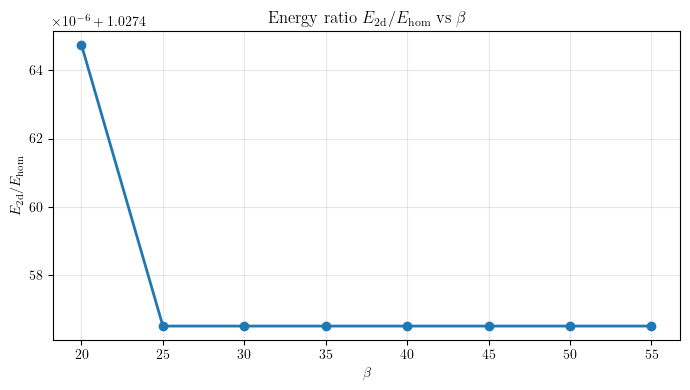

In [30]:
# Plot E_2d / E_hom vs beta (after beta scan)
if "results_beta" in dir() and len(results_beta) > 0 and results_beta[0].get("E_2d") is not None:
    betas = [r["beta"] for r in results_beta]
    E_2d_list = [r["E_2d"] for r in results_beta]
    E_hom_list = [r["E_hom"] for r in results_beta]
    ratio = np.array(E_2d_list) / np.array(E_hom_list)
    fig, ax = plt.subplots(1, 1, figsize=(7, 4))
    ax.plot(betas, ratio, "o-", lw=2, markersize=6)
    ax.set_xlabel(r"$\beta$")
    ax.set_ylabel(r"$E_{2\mathrm{d}} / E_{\mathrm{hom}}$")
    ax.set_title(r"Energy ratio $E_{2\mathrm{d}}/E_{\mathrm{hom}}$ vs $\beta$")
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()
else:
    print("Run the beta scan first; E_2d and E_hom are stored in results_beta.")

In [31]:
# Resample solution onto a finer grid and run Newton
from Q_ball_finder.notebook_utils import resample_complex_field
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver

# Source: last beta-scan solution or current 2D solution
if "results_beta" in dir() and len(results_beta) > 0:
    sol_ref = results_beta[-1]["sol"]
    eta_ref = results_beta[-1]["eta"]
else:
    sol_ref = sol_eta if "sol_eta" in dir() else (sol_newton if "sol_newton" in dir() else None)
    eta_ref = eta_star if "eta_star" in dir() else getattr(solver_newton, "eta0", 0.0)

if sol_ref is None:
    print("No solution available; run Newton/eta scan or beta scan first.")
else:
    Nr_old = sol_ref.grid.Nr
    Ntau_old = sol_ref.grid.Ntau
    Lr = float(sol_ref.grid.dr * Nr_old)
    beta = float(sol_ref.settings.beta)
    # Finer grid: e.g. factor 2 (or 3/2)
    factor_r = 3
    factor_tau = 3
    Nr_fine = Nr_old * factor_r
    Ntau_fine = Ntau_old * factor_tau

    settings_fine = Bubble2DSettings(
        Nr=Nr_fine, Ntau=Ntau_fine, Lr=Lr, beta=beta,
        eta0=eta_ref, omega_ref=solver_newton.settings.omega_ref,
        rho0=float(solver_newton.rho0),
        newton_tol=solver_newton.settings.newton_tol,
        newton_verbose=True,
    )
    solver_fine = Bubble2DSolver(settings_fine, U, dU, d2U)
    r_old = sol_ref.grid.r
    tau_old = sol_ref.grid.tau
    r_new = solver_fine.grid.r
    tau_new = solver_fine.grid.tau

    y_fine = resample_complex_field(sol_ref.y, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
    ybar_fine = resample_complex_field(sol_ref.ybar, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
    x0_fine = solver_fine.pack(y_fine, ybar_fine)

    print(f"Refinement: ({Nr_old}, {Ntau_old}) -> ({Nr_fine}, {Ntau_fine})")
    sol_fine = solver_fine.solve(x0_fine, verbose=True, verbose_success_block=False)
    print(f"Newton on fine grid: Q = {float(sol_fine.Q_tau0.real):.6f}, E = {float(sol_fine.E_tau0):.6f}")

    E_2d_fine = float(solver_fine.compute_energy_tau0_ghost(sol_fine.y, sol_fine.ybar, subtract_background=False))
    x_bg_fine = solver_fine._zero_vec()
    y_hf, yb_hf = solver_fine.unpack(x_bg_fine)
    E_hom_fine = float(solver_fine.compute_energy_tau0_ghost(y_hf, yb_hf, subtract_background=False))
    print(f"E_2d / E_hom = {E_2d_fine / E_hom_fine:.6f}")

Refinement: (80, 275) -> (240, 825)
[Newton-explicit] iter=01, ||F||=1.280e+03, charge=2.205046e+02, energy=-1.175123e+01, rhoQ=9.201584e-01, rhoE=-4.903752e-02, ratioQ=0.9544, ratioE=-67863993730.4500
[Newton-explicit] iter=02, ||F||=3.827e+00, charge=2.310291e+02, energy=2.464971e+00, rhoQ=9.640770e-01, rhoE=1.028624e-02, ratioQ=0.9999, ratioE=14235335033.6092
[Newton-explicit] iter=03, ||F||=1.182e-03, charge=2.310293e+02, energy=2.465040e+00, rhoQ=9.640778e-01, rhoE=1.028653e-02, ratioQ=0.9999, ratioE=14235734081.5777
[Newton-explicit] iter=04, ||F||=9.122e-10, charge=2.310293e+02, energy=2.465037e+00, rhoQ=9.640778e-01, rhoE=1.028652e-02, ratioQ=0.9999, ratioE=14235719439.2286
Newton on fine grid: Q = 231.029306, E = 2.465037
E_2d / E_hom = 1.027199


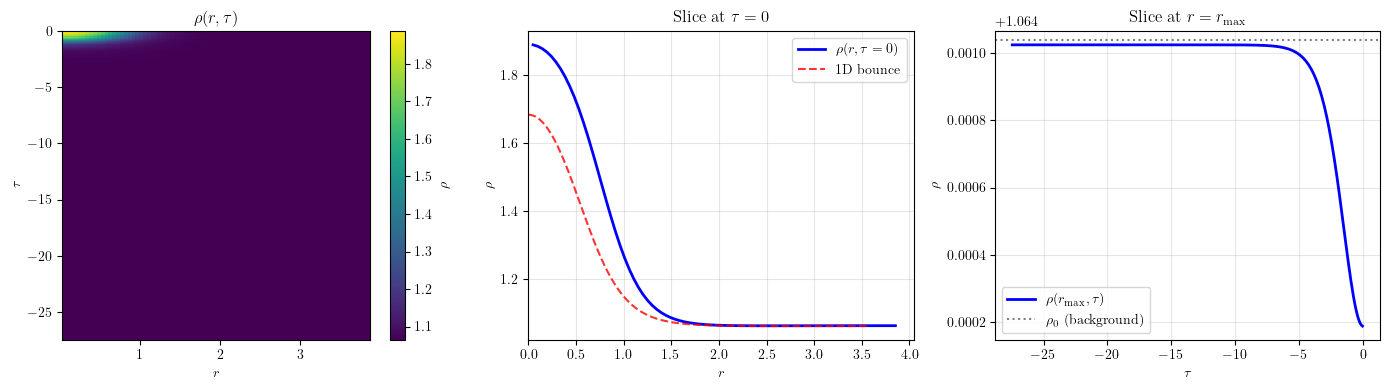

In [32]:
# Plot: rho 2D, slice at tau=0 vs 1D bounce, slice at r_max vs tau with background
sol_plot = results_beta[-1]["sol"] if "results_beta" in dir() and len(results_beta) > 0 else sol_eta
solver_plot = solver_newton
if "results_beta" in dir() and len(results_beta) > 0:
    last = results_beta[-1]
    settings_plot = Bubble2DSettings(
        Nr=last["sol"].grid.Nr, Ntau=last["sol"].grid.Ntau,
        Lr=float(last["sol"].grid.dr * last["sol"].grid.Nr),
        beta=last["sol"].settings.beta,
        eta0=last["eta"], omega_ref=solver_newton.settings.omega_ref,
        rho0=float(solver_newton.rho0)
    )
    solver_plot = Bubble2DSolver(settings_plot, U, dU, d2U)

rho_2d = solver_plot.rho_map(sol_plot.y, sol_plot.ybar)
r_plt = np.asarray(solver_plot.grid.r, float)
tau_plt = np.asarray(solver_plot.grid.tau, float)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. rho 2D heatmap
im = axes[0].pcolormesh(r_plt, tau_plt, rho_2d.T, shading="auto", cmap="viridis")
axes[0].set_xlabel(r"$r$")
axes[0].set_ylabel(r"$\tau$")
axes[0].set_title(r"$\rho(r,\tau)$")
plt.colorbar(im, ax=axes[0], label=r"$\rho$")

# 2. Slice at tau=0 vs 1D bounce
axes[1].plot(r_plt, rho_2d[:, 0], "b-", lw=2, label=r"$\rho(r,\tau=0)$")
r_cb = r_1d if "r_1d" in dir() else (r_bounce if "r_bounce" in dir() else None)
phi_cb = phi_1d if "phi_1d" in dir() else (phi_bounce if "phi_bounce" in dir() else None)
if r_cb is not None and phi_cb is not None:
    axes[1].plot(r_cb, phi_cb, "r--", lw=1.5, alpha=0.8, label="1D bounce")
axes[1].set_xlabel(r"$r$")
axes[1].set_ylabel(r"$\rho$")
axes[1].set_title(r"Slice at $\tau=0$")
axes[1].legend()
axes[1].set_xlim(0, None)
axes[1].grid(True, alpha=0.3)

# 3. Slice at r_max vs tau with background
axes[2].plot(tau_plt, rho_2d[-1, :], "b-", lw=2, label=r"$\rho(r_{\mathrm{max}},\tau)$")
axes[2].axhline(float(solver_plot.rho0), color="gray", ls=":", lw=1.5, label=r"$\rho_0$ (background)")
axes[2].set_xlabel(r"$\tau$")
axes[2].set_ylabel(r"$\rho$")
axes[2].set_title(r"Slice at $r=r_{\mathrm{max}}$")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

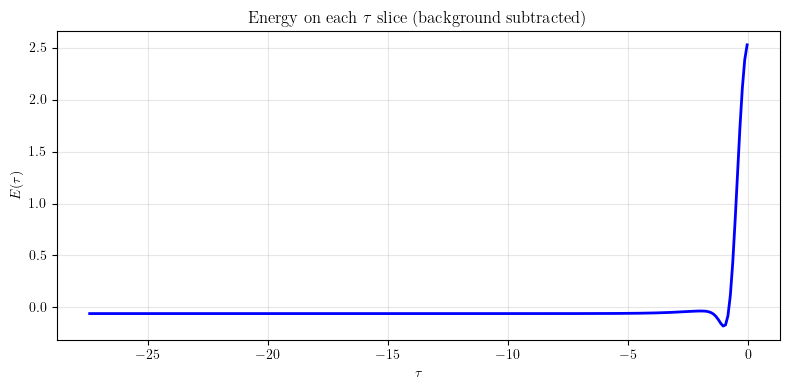

In [33]:
# Energy E(τ) on each τ slice (same solution as previous plot)
_, E_tau = solver_plot.compute_energy(sol_plot.y, sol_plot.ybar, return_profile=True, subtract_background=True)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tau_plt, E_tau, "b-", lw=2)
ax.set_xlabel(r"$\tau$")
ax.set_ylabel(r"$E(\tau)$")
ax.set_title(r"Energy on each $\tau$ slice (background subtracted)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [34]:
print(E_tau[-1])

-0.059352981088217786


In [35]:
# Energy of the homogeneous configuration at the chosen ω
from Bubble_finder.observables_2d import compute_targets_tau0_ghost

# Choose ω; ρ₀ recomputed from homogeneous condition dU/dρ = 2ω²ρ
omega = 0.85   # set your value here
from Bubble_finder.bounce2d import solve_rho0_for_omega
rho0 = float(solve_rho0_for_omega(omega, dU, (V1 * 0.8, V1 * 1.2)))
Lr = float(solver_plot.grid.dr * solver_plot.grid.Nr)
Nr, Ntau = solver_plot.grid.Nr, solver_plot.grid.Ntau
settings_hom = Bubble2DSettings(Nr=Nr, Ntau=Ntau, Lr=Lr, beta=solver_plot.settings.beta, eta0=0.0, omega_ref=omega, rho0=rho0)
solver_hom = Bubble2DSolver(settings_hom, U, dU, d2U)
tgt_hom = compute_targets_tau0_ghost(solver_hom, subtract_background_charge=False, subtract_background_energy=False)
E_hom = float(tgt_hom["E"])
Q_hom = float(tgt_hom["Q"])
V_ball = (4.0 / 3.0) * np.pi * (Lr**3)

print(f"ω = {omega:.6f}")
print(f"ρ₀ = {rho0:.6f}")
print(f"Lr = {Lr:.6f},  V = (4/3)π Lr³ = {V_ball:.6f}")
print(f"Homogeneous:  Q_hom = {Q_hom:.6f},  E_hom = {E_hom:.6f}")
print(f"              ρ_Q = Q/V = {Q_hom/V_ball:.6e},  ρ_E = E/V = {E_hom/V_ball:.6e}")

# 2D solution (after β scan): energy at τ=0 with ghost reconstruction (background subtracted)
E_2d_ghost = float(solver_plot.compute_energy_tau0_ghost(sol_plot.y, sol_plot.ybar, subtract_background=False))
Q_2d_ghost = float(solver_plot.compute_charge_tau0_ghost(sol_plot.y, sol_plot.ybar, subtract_background=False))
print(f"2D solution (τ=0 ghost):  Q = {Q_2d_ghost:.6f},  E = {E_2d_ghost:.6f}")

ω = 0.850000
ρ₀ = 1.065039
Lr = 3.853205,  V = (4/3)π Lr³ = 239.637614
Homogeneous:  Q_hom = 231.048901,  E_hom = 90.627942
              ρ_Q = Q/V = 9.641596e-01,  ρ_E = E/V = 3.781875e-01
2D solution (τ=0 ghost):  Q = 231.048899,  E = 93.116266


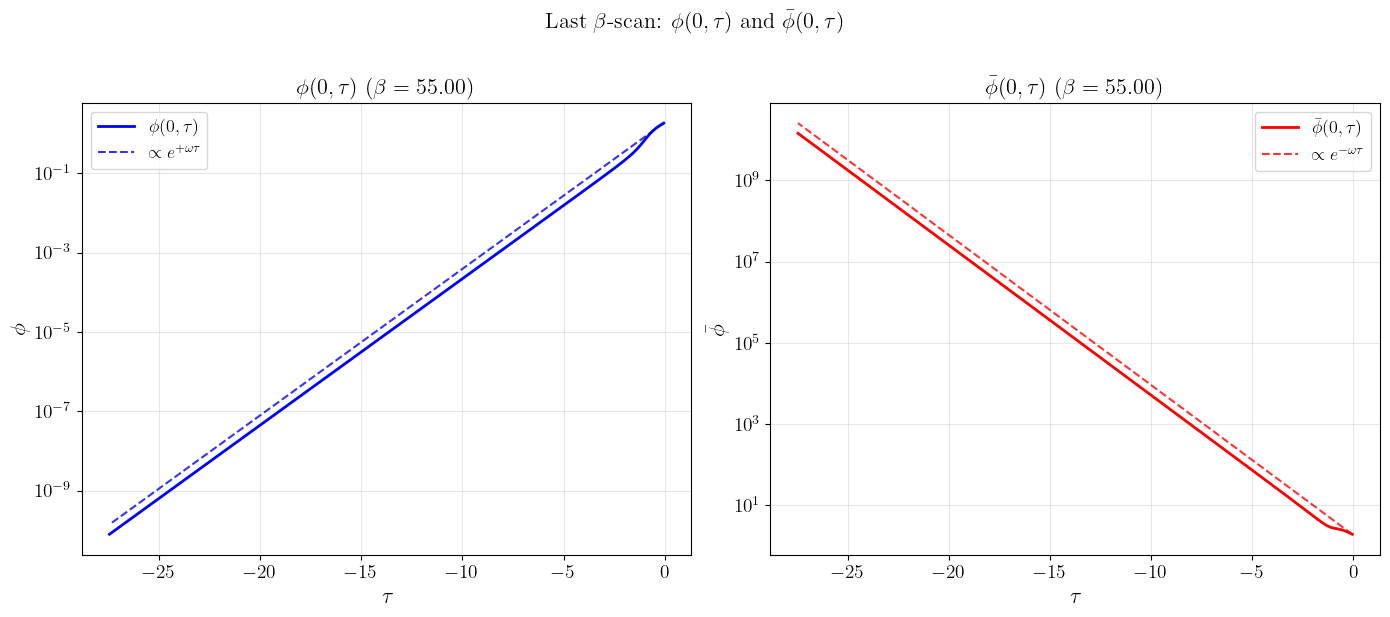

In [36]:
# φ(0, τ) and φ̄(0, τ) vs τ for the **last β-scan** solution (separate plots)
# Toggle y-axis scale:
LOG_Y = True  # set True for log scale

# Font sizes
LABEL_FS = 16
TICK_FS = 14
TITLE_FS = 16
LEGEND_FS = 13

# Pick last successful entry from β scan (fallback: current sol_plot/solver_plot)
sol_beta_plot = sol_plot
solver_beta_plot = solver_plot
beta_label = ""

if "results_beta" in dir() and isinstance(results_beta, list) and len(results_beta) > 0:
    last_ok = next((r for r in reversed(results_beta) if r.get("sol") is not None), None)
    if last_ok is not None:
        sol_beta_plot = last_ok["sol"]
        beta_val = float(last_ok.get("beta", sol_beta_plot.settings.beta))
        eta_val = float(last_ok.get("eta", solver_newton.eta0))
        settings_beta_plot = Bubble2DSettings(
            Nr=sol_beta_plot.grid.Nr,
            Ntau=sol_beta_plot.grid.Ntau,
            Lr=float(sol_beta_plot.grid.dr * sol_beta_plot.grid.Nr),
            beta=float(sol_beta_plot.settings.beta),
            eta0=eta_val,
            omega_ref=solver_newton.settings.omega_ref,
            rho0=float(solver_newton.rho0),
        )
        solver_beta_plot = Bubble2DSolver(settings_beta_plot, U, dU, d2U)
        beta_label = rf" ($\beta={beta_val:.2f}$)"

phi_2d, phibar_2d = solver_beta_plot.phi(sol_beta_plot.y, sol_beta_plot.ybar)  # (Nr, Ntau)
tau = np.asarray(solver_beta_plot.grid.tau, float)

# Reference exponential factors: exp(+ωτ) for φ, exp(-ωτ) for φ̄ (normalized at τ≈0)
omega_plot = float(getattr(solver_beta_plot, "omega", solver_beta_plot.settings.omega_ref))
i_tau0 = int(np.argmin(np.abs(tau)))
phi_ref0 = float(np.real(phi_2d[0, i_tau0]))
phibar_ref0 = float(np.real(phibar_2d[0, i_tau0]))
exp_phi = phi_ref0 * np.exp(+omega_plot * (tau - tau[i_tau0]))
exp_phibar = phibar_ref0 * np.exp(-omega_plot * (tau - tau[i_tau0]))

# Side-by-side panels (same structure as the rho cell): axes[0] left, axes[1] right
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True)

axes[0].plot(tau, np.real(phi_2d[0, :]), "b-", lw=2, label=r"$\phi(0,\tau)$")
axes[0].plot(tau, exp_phi, "b--", lw=1.5, alpha=0.8, label=r"$\propto e^{+\omega\tau}$")
axes[0].set_xlabel(r"$\tau$", fontsize=LABEL_FS)
axes[0].set_ylabel(r"$\phi$", fontsize=LABEL_FS)
axes[0].set_title(r"$\phi(0,\tau)$" + beta_label, fontsize=TITLE_FS)
axes[0].tick_params(axis="both", which="both", labelsize=TICK_FS)
if LOG_Y:
    axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc="best", fontsize=LEGEND_FS)

axes[1].plot(tau, np.real(phibar_2d[0, :]), "r-", lw=2, label=r"$\bar\phi(0,\tau)$")
axes[1].plot(tau, exp_phibar, "r--", lw=1.5, alpha=0.8, label=r"$\propto e^{-\omega\tau}$")
axes[1].set_xlabel(r"$\tau$", fontsize=LABEL_FS)
axes[1].set_ylabel(r"$\bar\phi$", fontsize=LABEL_FS)
axes[1].set_title(r"$\bar\phi(0,\tau)$" + beta_label, fontsize=TITLE_FS)
axes[1].tick_params(axis="both", which="both", labelsize=TICK_FS)
if LOG_Y:
    axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc="best", fontsize=LEGEND_FS)

fig.suptitle(r"Last $\beta$-scan: $\phi(0,\tau)$ and $\bar\phi(0,\tau)$", y=1.02, fontsize=TITLE_FS)
fig.tight_layout()
plt.show()

## Beta scan (β decrescente)

Scan su β con **step −0.5** (β diminuisce). Parte dall’ultimo punto dello scan in β crescente (o da `sol_eta` se non eseguito). Per ogni β: Newton + scan in η per matchare Q_target; risultati in `results_beta_down`. Alla fine: plot di $E_{2\mathrm{d}}/E_{\mathrm{hom}}$ vs β e profilo della soluzione finale.

In [42]:
# ============================================================================
# Beta scan DECRESCENTE: partenza da β=10, poi β giù di 0.5 fino a quando non si rompe
# ============================================================================
# Richiede: cella "Beta scan" (β crescente) per eta_scan_at_beta, compute_ntau_for_beta, _get_dens_info.
from Q_ball_finder.notebook_utils import resample_complex_field
from Bubble_finder.observables_2d import compute_targets_tau0_ghost
from Bubble_finder.bounce2d import NewtonConvergenceError

beta_start_down = 10.0   # partenza fissa a β=10
beta_step_down = -0.5    # poi 9.5, 9, 8.5, ... fino a fallimento
d_eta_down = 0.02

# Seed per β=10: da results_beta (punto con β più vicino a 10 o più piccolo) o da sol_eta
if "results_beta" in dir() and isinstance(results_beta, list) and len(results_beta) > 0:
    # Prendi il punto con beta >= 10 più piccolo, oppure l'ultimo (beta max) e resample a beta=10
    candidates = [r for r in results_beta if r.get("sol") is not None]
    if candidates:
        _ref = min(candidates, key=lambda r: abs(r.get("beta", 0) - 10.0))
        sol_seed = _ref["sol"]
        eta_seed = float(_ref["eta"])
    else:
        sol_seed = sol_eta
        eta_seed = float(eta_star) if "eta_star" in dir() else float(getattr(solver_newton, "eta0", 0.0))
else:
    sol_seed = sol_eta if "sol_eta" in dir() else None
    eta_seed = float(eta_star) if "eta_star" in dir() else float(getattr(solver_newton, "eta0", 0.0))

if sol_seed is None:
    print("Nessuna soluzione di partenza: eseguire prima lo scan β crescente o la cella eta scan.")
else:
    nr_ref_down = int(sol_seed.grid.Nr)
    lr_ref_down = float(sol_seed.grid.dr * sol_seed.grid.Nr)
    beta_ref_down = beta_start_down
    ntau_10 = compute_ntau_for_beta(beta_start_down, float(sol_seed.settings.beta), int(sol_seed.grid.Ntau))
    ntau_ref_down = ntau_10

    # Costruisci soluzione a β=10 (resample seed + Newton + eta_scan)
    settings_10 = Bubble2DSettings(
        Nr=nr_ref_down, Ntau=ntau_10, Lr=lr_ref_down, beta=beta_start_down,
        eta0=eta_seed, omega_ref=solver_newton.settings.omega_ref,
        rho0=float(solver_newton.rho0), newton_tol=solver_newton.settings.newton_tol,
        newton_verbose=False,
    )
    solver_10 = Bubble2DSolver(settings_10, U, dU, d2U)
    r_old, tau_old = sol_seed.grid.r, sol_seed.grid.tau
    r_new, tau_new = solver_10.grid.r, solver_10.grid.tau
    y_new = resample_complex_field(sol_seed.y, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
    ybar_new = resample_complex_field(sol_seed.ybar, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
    x0_10 = solver_10.pack(y_new, ybar_new)

    try:
        sol_newton_10 = solver_10.solve(x0_10, verbose=True, verbose_success_block=False)
        tgt_10 = compute_targets_tau0_ghost(solver_10, subtract_background_charge=False, subtract_background_energy=True)
        eta_beta_down, sol_beta_down, _, dens_info_10 = eta_scan_at_beta(
            solver_10, eta_seed, sol_newton_10.x.copy(), float(tgt_10["Q"]), d_eta=d_eta_down, verbose=True
        )
    except (NewtonConvergenceError, RuntimeError) as e:
        print(f"Fallito già a β={beta_start_down}: {e}")
        results_beta_down = []
    else:
        _x0 = solver_10._zero_vec()
        _yh, _ybh = solver_10.unpack(_x0)
        E_2d_0 = float(solver_10.compute_energy_tau0_ghost(sol_beta_down.y, sol_beta_down.ybar, subtract_background=False))
        E_hom_0 = float(solver_10.compute_energy_tau0_ghost(_yh, _ybh, subtract_background=False))
        results_beta_down = [
            {"beta": beta_start_down, "eta": eta_beta_down, "Q": float(sol_beta_down.Q_tau0.real),
             "E": float(sol_beta_down.E_tau0), "sol": sol_beta_down, "E_2d": E_2d_0, "E_hom": E_hom_0,
             "q_r": dens_info_10.get("q_r"), "e_r": dens_info_10.get("e_r"), "r": dens_info_10.get("r")}
        ]
        print(f"Punto iniziale β={beta_start_down}: η*={eta_beta_down:.6f}, E_2d/E_hom={E_2d_0/E_hom_0:.6f}")

        # Loop: β decreases; use Δβ=-0.5 down to β=4, then Δβ=-0.1 for β<4 (until it breaks)
        k = 0
        beta_curr = float(beta_start_down)
        while True:
            step_here = -0.5 if beta_curr > 4.0 else -0.1
            beta_new = beta_curr + step_here
            if beta_new <= 0:
                print("Raggiunto β ≤ 0, stop.")
                break
            ntau_new = compute_ntau_for_beta(beta_new, beta_ref_down, ntau_ref_down)
            print("")
            print("=" * 60)
            print(f"Step {k+1}: β = {beta_new:.4f}  (Δβ={step_here:.1f})")
            print("=" * 60)
            try:
                settings_new = Bubble2DSettings(
                    Nr=nr_ref_down, Ntau=ntau_new, Lr=lr_ref_down, beta=float(beta_new),
                    eta0=eta_beta_down, omega_ref=solver_newton.settings.omega_ref,
                    rho0=float(solver_newton.rho0), newton_tol=solver_newton.settings.newton_tol,
                    newton_verbose=False,
                )
                solver_b = Bubble2DSolver(settings_new, U, dU, d2U)
                r_old, tau_old = sol_beta_down.grid.r, sol_beta_down.grid.tau
                r_new, tau_new = solver_b.grid.r, solver_b.grid.tau
                y_new = resample_complex_field(sol_beta_down.y, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
                ybar_new = resample_complex_field(sol_beta_down.ybar, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
                x0 = solver_b.pack(y_new, ybar_new)

                sol_newton = solver_b.solve(x0, verbose=True, verbose_success_block=False)
                tgt_b = compute_targets_tau0_ghost(solver_b, subtract_background_charge=False, subtract_background_energy=True)
                Q_target_this = float(tgt_b["Q"])

                eta_beta_down, sol_beta_down, _, dens_info = eta_scan_at_beta(
                    solver_b, eta_beta_down, sol_newton.x.copy(), Q_target_this, d_eta=d_eta_down, verbose=True
                )
            except (NewtonConvergenceError, RuntimeError) as e:
                print(f"Stop: fallito a β = {beta_new:.4f} — {e}")
                break

            Q_f = dens_info["Q"]
            E_ghost = dens_info["E"]
            E_2d = float(solver_b.compute_energy_tau0_ghost(sol_beta_down.y, sol_beta_down.ybar, subtract_background=False))
            x_bg_b = solver_b._zero_vec()
            y_hb, yb_hb = solver_b.unpack(x_bg_b)
            E_hom = float(solver_b.compute_energy_tau0_ghost(y_hb, yb_hb, subtract_background=False))

            results_beta_down.append({
                "beta": float(beta_new), "eta": eta_beta_down, "Q": Q_f, "E": E_ghost,
                "E_2d": E_2d, "E_hom": E_hom, "sol": sol_beta_down,
                "q_r": dens_info.get("q_r"), "e_r": dens_info.get("e_r"), "r": dens_info.get("r"),
            })
            print(f"  η* = {eta_beta_down:.6f}, Q = {Q_f:.6f}, E_2d/E_hom = {E_2d/E_hom:.6f}")
            beta_curr = float(beta_new)
            k += 1

        print("")
        print(f"Scan decrescente completato: {len(results_beta_down)} punti (ultimo β = {results_beta_down[-1]['beta']:.2f}).")

[Newton-explicit] iter=01, ||F||=3.470e+00, charge=2.310494e+02, energy=2.489073e+00, rhoQ=9.641615e-01, rhoE=1.038682e-02, ratioQ=1.0000, ratioE=14374449642.1822
[Newton-explicit] iter=02, ||F||=1.974e-04, charge=2.310151e+02, energy=2.432414e+00, rhoQ=9.640186e-01, rhoE=1.015038e-02, ratioQ=0.9999, ratioE=14047243134.2694
[Newton-explicit] iter=03, ||F||=2.490e-10, charge=2.310151e+02, energy=2.432416e+00, rhoQ=9.640186e-01, rhoE=1.015039e-02, ratioQ=0.9999, ratioE=14047256108.9383
[eta-scan] eta = -0.027336, charge = 2.310151e+02, energy = 2.432416e+00, target = 2.310489e+02, ratioQ = 0.999854
[eta-scan] try eta = -0.007336, charge = 2.316815e+02, energy = 3.534749e+00, ratioQ = 1.002738, ratioE = 0.017998
[eta-root] eta = -0.027336 (cached), charge = 2.310151e+02, energy = 2.432416e+00, ratioQ = 0.999854, ratioE = 0.012386
[eta-root] eta = -0.007336 (cached), charge = 2.316815e+02, energy = 3.534749e+00, ratioQ = 1.002738, ratioE = 0.017998
[eta-root] eta = -0.026323, charge = 2.31

IndexError: index 1 is out of bounds for axis 1 with size 1

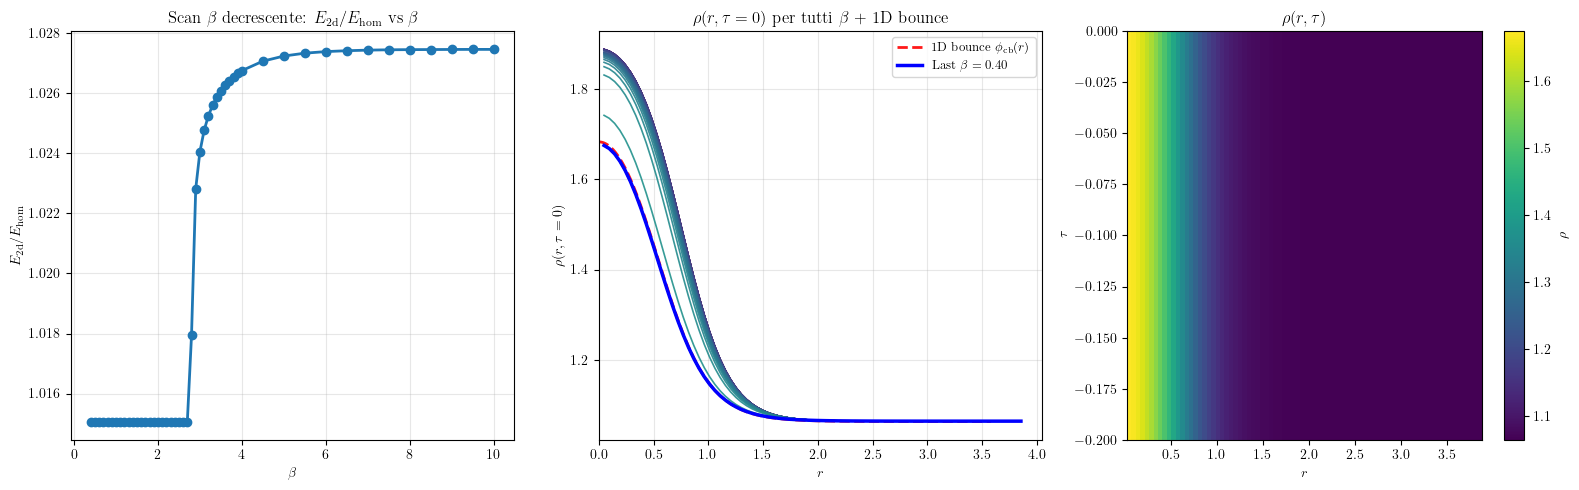

In [43]:
# Plot risultati scan β decrescente: E_2d/E_hom vs β e profilo finale
if "results_beta_down" in dir() and len(results_beta_down) > 0:
    betas_down = [r["beta"] for r in results_beta_down]
    E_2d_down = [r["E_2d"] for r in results_beta_down]
    E_hom_down = [r["E_hom"] for r in results_beta_down]
    ratio_down = np.array(E_2d_down) / np.array(E_hom_down)

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    axes[0].plot(betas_down, ratio_down, "o-", lw=2, markersize=6, color="C0")
    axes[0].set_xlabel(r"$\beta$")
    axes[0].set_ylabel(r"$E_{2\mathrm{d}} / E_{\mathrm{hom}}$")
    axes[0].set_title(r"Scan $\beta$ decrescente: $E_{2\mathrm{d}}/E_{\mathrm{hom}}$ vs $\beta$")
    axes[0].grid(True, alpha=0.3)

    # Profilo ρ(r) a τ=0 per tutte le iterazioni β e profilo 1D bolla
    cmap_rho = plt.cm.viridis
    n_down = len(results_beta_down)
    for idx, rec in enumerate(results_beta_down):
        sol_i = rec["sol"]
        r_i = np.asarray(sol_i.grid.r, float)
        set_i = Bubble2DSettings(
            Nr=sol_i.grid.Nr, Ntau=sol_i.grid.Ntau,
            Lr=float(sol_i.grid.dr * sol_i.grid.Nr), beta=sol_i.settings.beta,
            eta0=rec["eta"], omega_ref=solver_newton.settings.omega_ref,
            rho0=float(solver_newton.rho0),
        )
        solver_i = Bubble2DSolver(set_i, U, dU, d2U)
        rho_i = solver_i.rho_map(sol_i.y, sol_i.ybar)[:, 0]
        color = cmap_rho(idx / max(n_down - 1, 1))
        axes[1].plot(r_i, rho_i, "-", lw=1.2, color=color, alpha=0.9)
    r_cb = r_1d if "r_1d" in dir() else (r_bounce if "r_bounce" in dir() else None)
    phi_cb = phi_1d if "phi_1d" in dir() else (phi_bounce if "phi_bounce" in dir() else None)
    if r_cb is not None and phi_cb is not None:
        axes[1].plot(r_cb, phi_cb, "r--", lw=2, alpha=0.9, label=r"1D bounce $\phi_{\mathrm{cb}}(r)$")
    last_down = results_beta_down[-1]
    sol_last = last_down["sol"]
    r_last = np.asarray(sol_last.grid.r, float)
    tau_last = np.asarray(sol_last.grid.tau, float)
    settings_last = Bubble2DSettings(
        Nr=sol_last.grid.Nr, Ntau=sol_last.grid.Ntau,
        Lr=float(sol_last.grid.dr * sol_last.grid.Nr), beta=sol_last.settings.beta,
        eta0=last_down["eta"], omega_ref=solver_newton.settings.omega_ref,
        rho0=float(solver_newton.rho0),
    )
    solver_last = Bubble2DSolver(settings_last, U, dU, d2U)
    rho_2d = solver_last.rho_map(sol_last.y, sol_last.ybar)
    axes[1].plot(r_last, rho_2d[:, 0], "b-", lw=2.5, label=rf"Last $\beta={last_down['beta']:.2f}$")
    axes[1].set_xlabel(r"$r$")
    axes[1].set_ylabel(r"$\rho(r,\tau=0)$")
    axes[1].set_title(r"$\rho(r,\tau=0)$ per tutti $\beta$ + 1D bounce")
    axes[1].legend(loc="best", fontsize=9)
    axes[1].set_xlim(0, None)
    axes[1].grid(True, alpha=0.3)

    im = axes[2].pcolormesh(r_last, tau_last, rho_2d.T, shading="auto", cmap="viridis")
    axes[2].set_xlabel(r"$r$")
    axes[2].set_ylabel(r"$\tau$")
    axes[2].set_title(r"$\rho(r,\tau)$")
    plt.colorbar(im, ax=axes[2], label=r"$\rho$")

    fig.tight_layout()
    plt.show()
else:
    print("Eseguire prima la cella dello scan β decrescente (results_beta_down).")

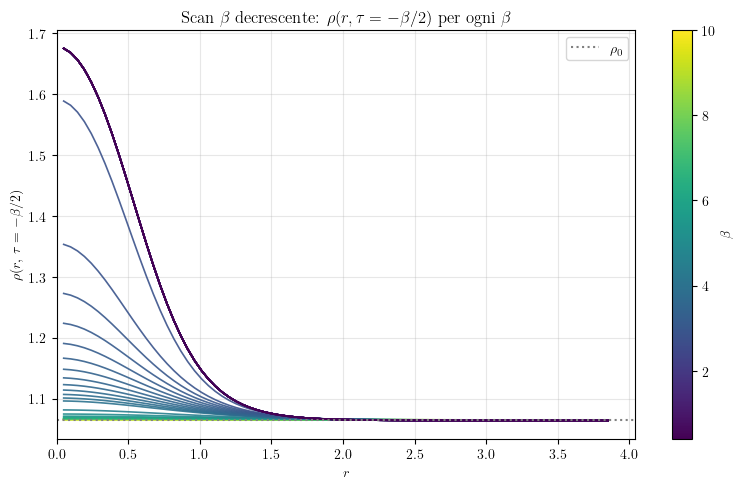

In [45]:
# Plot ρ(r, τ=-β/2) per ogni β dello scan decrescente
if "results_beta_down" in dir() and len(results_beta_down) > 0:
    fig, ax = plt.subplots(figsize=(8, 5))
    betas_down = [r["beta"] for r in results_beta_down]
    b_min, b_max = min(betas_down), max(betas_down)
    norm_beta = plt.Normalize(vmin=b_min, vmax=b_max)
    cmap = plt.cm.viridis
    for rec in results_beta_down:
        sol_i = rec["sol"]
        r_i = np.asarray(sol_i.grid.r, float)
        set_i = Bubble2DSettings(
            Nr=sol_i.grid.Nr, Ntau=sol_i.grid.Ntau,
            Lr=float(sol_i.grid.dr * sol_i.grid.Nr), beta=sol_i.settings.beta,
            eta0=rec["eta"], omega_ref=solver_newton.settings.omega_ref,
            rho0=float(solver_newton.rho0),
        )
        solver_i = Bubble2DSolver(set_i, U, dU, d2U)
        rho_2d_i = solver_i.rho_map(sol_i.y, sol_i.ybar)
        rho_at_tau_end = rho_2d_i[:, -1]
        color = cmap(norm_beta(rec["beta"]))
        ax.plot(r_i, rho_at_tau_end, "-", lw=1.2, color=color, alpha=0.9)
    ax.axhline(float(solver_newton.rho0), color="gray", ls=":", lw=1.5, label=r"$\rho_0$")
    ax.set_xlabel(r"$r$")
    ax.set_ylabel(r"$\rho(r,\, \tau=-\beta/2)$")
    ax.set_title(r"Scan $\beta$ decrescente: $\rho(r,\tau=-\beta/2)$ per ogni $\beta$")
    ax.set_xlim(0, None)
    ax.legend(loc="best")
    ax.grid(True, alpha=0.3)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm_beta)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, label=r"$\beta$")
    plt.tight_layout()
    plt.show()
else:
    print("Eseguire prima la cella dello scan β decrescente (results_beta_down).")

## Maximum radius scan (continuation in $L_r$)

We increase the **maximum radius** $L_r = r_{\max}$ from the current configuration up to a maximum (e.g. $15$) in steps (e.g. $1$). We start from the solution **before** the $\beta$ scan, i.e. **$\texttt{sol\_eta}$** (charge already matched to $Q_{\mathrm{hom}}$).

For each $L_r$: build a grid with the new $L_r$ (same $\beta$); the ansatz is the previous solution **resampled** on the new grid; run Newton; then run an **$\eta_0$ scan** (bisection) so that the charge $Q$ matches the homogeneous value $Q_{\\mathrm{target}}$ on this grid. So at each step $\eta_0$ is updated to $\eta_0^*$ and the solution is charge-matched. The goal is to study the effect of the volume (and of the boundary at $r = L_r$) on the 2D solution.

In [82]:
# ============================================================================
# Lr scan: increase maximum radius from current Lr up to 15, step 1
# At each Lr step: Newton then eta0 scan to match Q to homogeneous on this grid
# ============================================================================
from Q_ball_finder.notebook_utils import resample_complex_field
from Bubble_finder.bounce2d import Bubble2DSettings, Bubble2DSolver
from Bubble_finder.observables_2d import compute_targets_tau0_ghost

# Start from sol_eta (before beta scan)
sol_lr = sol_eta
eta_lr = float(solver_newton.eta0)
beta_lr = float(solver_newton.settings.beta)
Lr_start = float(sol_eta.grid.dr * sol_eta.grid.Nr)
dr_ref = float(sol_eta.grid.dr)
Ntau_lr = int(sol_eta.grid.Ntau)

# Scan: Lr from Lr_start to 15, step 1
Lr_end = 15.0
Lr_step = 2
d_eta_lr = 0.01
Lr_values = []
x = Lr_start
while x <= Lr_end:
    Lr_values.append(float(x))
    x += Lr_step

results_lr = []
print(f"Lr scan: {Lr_start:.1f} -> {Lr_end:.0f} (step {Lr_step}), beta={beta_lr:.2f}, eta={eta_lr:.6f}")
print(f"Initial: Lr={Lr_start:.2f}, Q={float(sol_lr.Q_tau0.real):.6f}, E={float(sol_lr.E_tau0):.6f}")
print()

for k, Lr_new in enumerate(Lr_values):
    # Keep dr constant: Nr scales with Lr
    Nr_new = max(1, int(round(Lr_new / dr_ref)))
    dr_new = Lr_new / Nr_new

    settings_lr = Bubble2DSettings(
        Nr=Nr_new, Ntau=Ntau_lr, Lr=Lr_new, beta=beta_lr,
        eta0=eta_lr, omega_ref=solver_newton.settings.omega_ref,
        rho0=float(solver_newton.rho0), newton_tol=solver_newton.settings.newton_tol,
        newton_verbose=False
    )
    solver_lr = Bubble2DSolver(settings_lr, U, dU, d2U)

    # Resample solution onto new grid
    r_old = np.asarray(sol_lr.grid.r, float)
    tau_old = np.asarray(sol_lr.grid.tau, float)
    r_new = np.asarray(solver_lr.grid.r, float)
    tau_new = np.asarray(solver_lr.grid.tau, float)
    y_new = resample_complex_field(sol_lr.y, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
    ybar_new = resample_complex_field(sol_lr.ybar, r_old, tau_old, r_new, tau_new, clamp_tau_to_plateau=True)
    x0 = solver_lr.pack(y_new, ybar_new)

    print("=" * 60)
    print(f"Lr scan step {k+1}/{len(Lr_values)}: Lr = {Lr_new:.1f} (Nr={Nr_new}, dr={dr_new:.4f})")
    print("=" * 60)
    print("Strategy: Keeping dr constant, Nr scales with Lr")
    print(f"Nr = {Nr_new}, dr = {dr_new:.6f}")
    print("")

    try:
        sol_new = solver_lr.solve(x0, verbose=True, verbose_success_block=False)

        # Targets on this grid (homogeneous reference)
        tgt_lr = compute_targets_tau0_ghost(solver_lr, subtract_background_charge=False, subtract_background_energy=True)
        Q_target_lr = float(tgt_lr["Q"])

        # Find η* to match Q (then take observables from the converged 2D solution)
        eta_lr, sol_lr, _, dens_info = eta_scan_at_beta(
            solver_lr, eta_lr, sol_new.newton.x.copy(), Q_target_lr, d_eta=d_eta_lr, verbose=True
        )

        # 2D observables (τ=0 ghost)
        Q_f = float(dens_info["Q"])                         # total Q (no subtraction)
        E_sub = float(dens_info["E"])                       # E with background subtraction (as in dens_info)
        E_raw = float(solver_lr.compute_energy_tau0_ghost(sol_lr.y, sol_lr.ybar, subtract_background=False))

        # Homogeneous energy on the same grid (NO background subtraction)
        tgt_hom_raw = compute_targets_tau0_ghost(solver_lr, subtract_background_charge=False, subtract_background_energy=False)
        E_hom_raw = float(tgt_hom_raw["E"])

        V_lr = (4.0 / 3.0) * np.pi * (Lr_new**3)
        rho_Q_avg = Q_f / V_lr
        rho_E_avg = E_sub / V_lr

        print("")
        print(f"--- Diagnostics for Lr = {Lr_new:.4f} ---")
        print(f"η* = {eta_lr:.6f}")
        print(f"Q = {Q_f:.6f} (target: {Q_target_lr:.6f}, ratio: {Q_f/Q_target_lr:.6f})")
        print(f"E (τ=0 ghost, subtracted) = {E_sub:.6f}")
        print(f"E_raw (τ=0 ghost, no subtraction) = {E_raw:.6f}")
        print(f"E_hom_raw (homogeneous, no subtraction) = {E_hom_raw:.6f}")
        if abs(E_hom_raw) > 0:
            print(f"  ratio E_raw/E_hom_raw = {E_raw/E_hom_raw:.6e}")
        print(f"Nr = {Nr_new}, dr = {dr_new:.6f}")
        print(f"Density: q_max = {dens_info['q_max']:.6e} at r = {dens_info['r_at_q_max']:.6f}, e_max = {dens_info['e_max']:.6e} at r = {dens_info['r_at_e_max']:.6f}")
        print(f"  ρ_Q_avg = Q/V = {rho_Q_avg:.6e}, ρ_E_avg = E/V = {rho_E_avg:.6e} (V = (4/3)π Lr³)")

        results_lr.append({
            "Lr": Lr_new, "Nr": Nr_new, "dr": dr_new, "eta": eta_lr,
            "Q": Q_f,
            # Energies:
            # - E: τ=0 ghost energy with background subtraction (used in scans/diagnostics)
            # - E_raw: τ=0 ghost energy with NO subtraction
            # - E_hom_raw: homogeneous energy on the same grid with NO subtraction
            "E": E_sub, "E_raw": E_raw, "E_hom_raw": E_hom_raw,
            "sol": sol_lr, "success": True,
            "q_r": dens_info["q_r"], "e_r": dens_info["e_r"], "r": dens_info["r"],
            "q_max": dens_info["q_max"], "e_max": dens_info["e_max"],
            "r_at_q_max": dens_info["r_at_q_max"], "r_at_e_max": dens_info["r_at_e_max"]
        })
    except Exception as e:
        print(f"  FAILED: {e}")
        results_lr.append({"Lr": Lr_new, "Nr": Nr_new, "dr": dr_new, "success": False})
    print()

print(f"Lr scan completed: {len([r for r in results_lr if r.get('success')])} successful, {len(results_lr)} total.")

Lr scan: 3.9 -> 15 (step 2), beta=20.00, eta=-0.027336
Initial: Lr=3.85, Q=231.049350, E=2.489073

Lr scan step 1/6: Lr = 3.9 (Nr=80, dr=0.0482)
Strategy: Keeping dr constant, Nr scales with Lr
Nr = 80, dr = 0.048165

[Newton-explicit] iter=01, ||F||=6.574e-13, charge=2.310494e+02, energy=2.489073e+00, rhoQ=9.641615e-01, rhoE=1.038682e-02, ratioQ=1.0000, ratioE=14374449642.1822


[eta-scan] eta = -0.027336, charge = 2.310494e+02, energy = 2.489073e+00, target = 2.310489e+02, ratioQ = 1.000002
[eta-scan] try eta = -0.037336, charge = 2.308825e+02, energy = 2.213384e+00, ratioQ = 0.999280, ratioE = 0.011270
[eta-root] eta = -0.037336 (cached), charge = 2.308825e+02, energy = 2.213384e+00, ratioQ = 0.999280, ratioE = 0.011270
[eta-root] eta = -0.027336 (cached), charge = 2.310494e+02, energy = 2.489073e+00, ratioQ = 1.000002, ratioE = 0.012674
[eta-root] eta = -0.027363, charge = 2.310489e+02, energy = 2.488327e+00, ratioQ = 1.000000, ratioE = 0.012670
[eta-root] eta = -0.027363, charge = 2.310489e+02, energy = 2.488327e+00, ratioQ = 1.000000, ratioE = 0.012670
[eta-root] eta = -0.027363, charge = 2.310489e+02, energy = 2.488327e+00, ratioQ = 1.000000, ratioE = 0.012670
[eta-scan] eta* = -0.027363, charge = 2.310489e+02, energy = 2.488327e+00, ratioQ = 1.000000, ratioE = 0.012670

--- Diagnostics for Lr = 3.8532 ---
η* = -0.027363
Q = 231.048899 (target: 231.04889

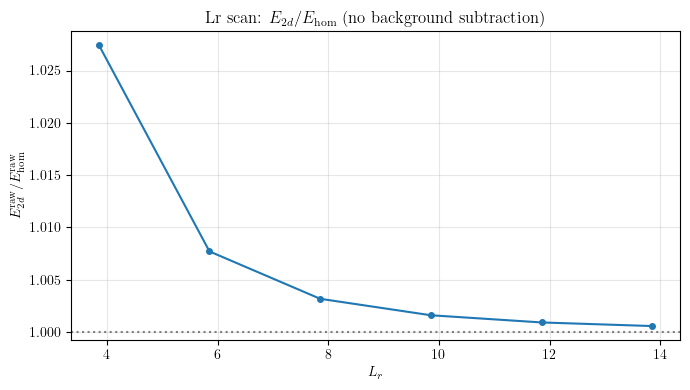

In [ ]:
# Plot ratio E_2d/E_hom (no background subtraction) vs Lr from Lr scan
if "results_lr" not in dir() or len(results_lr) == 0:
    print("No Lr scan results; run the Lr scan cell first.")
else:
    ok = [r for r in results_lr if r.get("success") and ("E_raw" in r) and ("E_hom_raw" in r)]
    if not ok:
        print("No successful Lr entries with E_raw and E_hom_raw; re-run the Lr scan after updating the scan cell.")
    else:
        Lr_arr = np.array([r["Lr"] for r in ok], float)
        E_raw_arr = np.array([r["E_raw"] for r in ok], float)
        E_hom_arr = np.array([r["E_hom_raw"] for r in ok], float)
        ratio = np.where(np.abs(E_hom_arr) > 0, E_raw_arr / E_hom_arr, np.nan)

        fig, ax = plt.subplots(figsize=(7, 4))
        ax.plot(Lr_arr, ratio, "o-", lw=1.5, ms=4)
        ax.axhline(1.0, color="gray", ls=":", lw=1.5, label=r"$E_{2d}/E_{\rm hom}=1$")
        ax.set_xlabel(r"$L_r$")
        ax.set_ylabel(r"$E_{2d}^{\rm raw} / E_{\rm hom}^{\rm raw}$")
        ax.set_title(r"Lr scan: $E_{2d}/E_{\rm hom}$ (no background subtraction)")
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

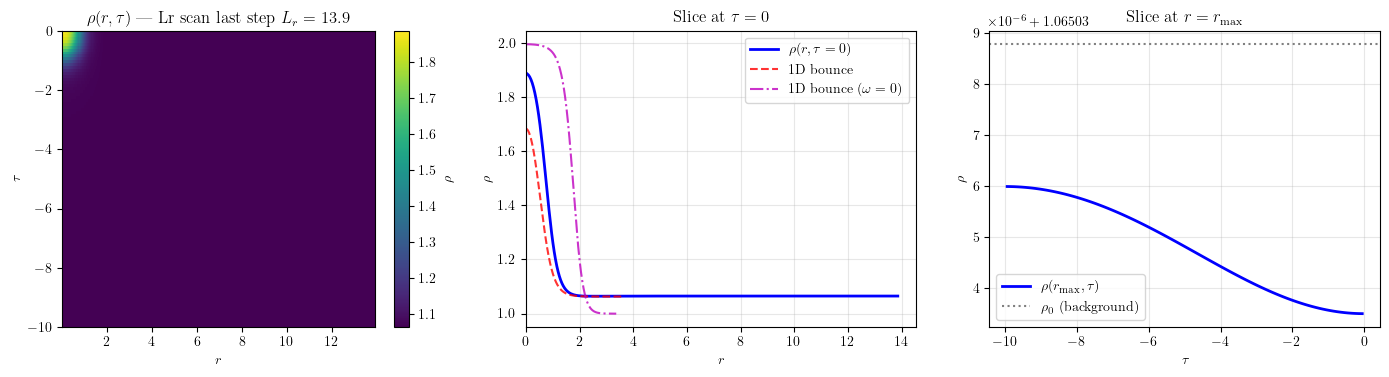

In [ ]:
# Plot: rho 2D, slice at tau=0 vs 1D bounce, slice at r_max vs tau — last step of Lr scan
last_lr = results_lr[-1] if "results_lr" in dir() and len(results_lr) > 0 and results_lr[-1].get("success") else None
if last_lr is None:
    print("No successful Lr scan result; run the Lr scan cell first.")
else:
    sol_plot = last_lr["sol"]
    settings_plot = Bubble2DSettings(
        Nr=sol_plot.grid.Nr, Ntau=sol_plot.grid.Ntau,
        Lr=float(sol_plot.grid.dr * sol_plot.grid.Nr),
        beta=sol_plot.settings.beta,
        eta0=solver_newton.eta0, omega_ref=solver_newton.settings.omega_ref,
        rho0=float(solver_newton.rho0)
    )
    solver_plot = Bubble2DSolver(settings_plot, U, dU, d2U)

    rho_2d = solver_plot.rho_map(sol_plot.y, sol_plot.ybar)
    r_plt = np.asarray(solver_plot.grid.r, float)
    tau_plt = np.asarray(solver_plot.grid.tau, float)
    Lr_val = last_lr["Lr"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # 1. rho 2D heatmap
    im = axes[0].pcolormesh(r_plt, tau_plt, rho_2d.T, shading="auto", cmap="viridis")
    axes[0].set_xlabel(r"$r$")
    axes[0].set_ylabel(r"$\tau$")
    axes[0].set_title(rf"$\rho(r,\tau)$ — Lr scan last step $L_r={Lr_val:.1f}$")
    plt.colorbar(im, ax=axes[0], label=r"$\rho$")

    # 2. Slice at tau=0 vs 1D bounce
    axes[1].plot(r_plt, rho_2d[:, 0], "b-", lw=2, label=r"$\rho(r,\tau=0)$")
    r_cb = r_1d if "r_1d" in dir() else (r_bounce if "r_bounce" in dir() else None)
    phi_cb = phi_1d if "phi_1d" in dir() else (phi_bounce if "phi_bounce" in dir() else None)
    if r_cb is not None and phi_cb is not None:
        axes[1].plot(r_cb, phi_cb, "r--", lw=1.5, alpha=0.8, label="1D bounce")
    if "r_bubble_zero_charge" in dir() and r_bubble_zero_charge is not None and phi_bubble_zero_charge is not None:
        axes[1].plot(r_bubble_zero_charge, phi_bubble_zero_charge, "m-.", lw=1.5, alpha=0.8, label=r"1D bounce ($\omega=0$)")
    axes[1].set_xlabel(r"$r$")
    axes[1].set_ylabel(r"$\rho$")
    axes[1].set_title(r"Slice at $\tau=0$")
    axes[1].legend()
    axes[1].set_xlim(0, None)
    axes[1].grid(True, alpha=0.3)

    # 3. Slice at r_max vs tau with background
    axes[2].plot(tau_plt, rho_2d[-1, :], "b-", lw=2, label=r"$\rho(r_{\mathrm{max}},\tau)$")
    axes[2].axhline(float(solver_plot.rho0), color="gray", ls=":", lw=1.5, label=r"$\rho_0$ (background)")
    axes[2].set_xlabel(r"$\tau$")
    axes[2].set_ylabel(r"$\rho$")
    axes[2].set_title(r"Slice at $r=r_{\mathrm{max}}$")
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    fig.tight_layout()
    plt.show()

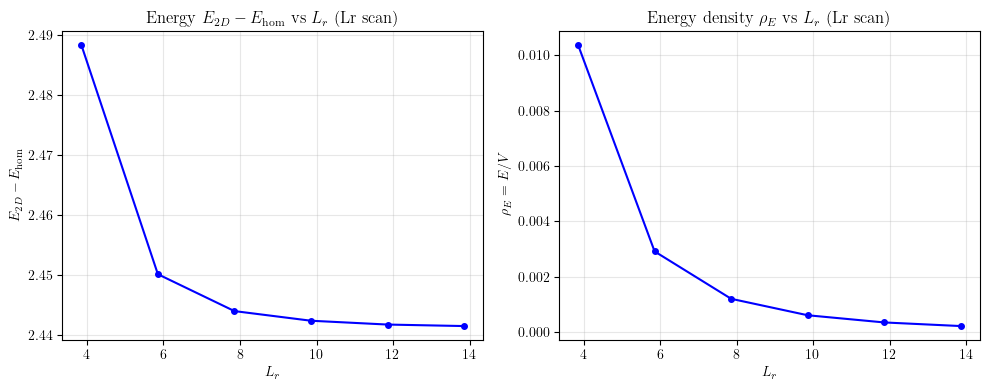

In [ ]:
# E and rho_E vs Lr from Lr scan
if "results_lr" not in dir() or len(results_lr) == 0:
    print("No Lr scan results; run the Lr scan cell first.")
else:
    ok = [r for r in results_lr if r.get("success")]
    if not ok:
        print("No successful Lr scan entries.")
    else:
        Lr_arr = np.array([r["Lr"] for r in ok])
        E_arr = np.array([r["E"] for r in ok])
        V_arr = (4.0 / 3.0) * np.pi * (Lr_arr**3)
        rho_E_arr = E_arr / V_arr

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
        ax1.plot(Lr_arr, E_arr, "b-o", lw=1.5, ms=4)
        ax1.set_xlabel(r"$L_r$")
        ax1.set_ylabel(r"$E_{2D}-E_{\rm hom}$")
        ax1.set_title(r"Energy $E_{2D}-E_{\rm hom}$ vs $L_r$ (Lr scan)")
        ax1.grid(True, alpha=0.3)

        ax2.plot(Lr_arr, rho_E_arr, "b-o", lw=1.5, ms=4)
        ax2.set_xlabel(r"$L_r$")
        ax2.set_ylabel(r"$\rho_E = E/V$")
        ax2.set_title(r"Energy density $\rho_E$ vs $L_r$ (Lr scan)")
        ax2.grid(True, alpha=0.3)

        fig.tight_layout()
        plt.show()

## Hyperbolic phase $\beta(\tau, r)$ in the $(r, \tau)$ plane

In the Euclidean path integral with **fixed charge**, the saddle is "bi-real": the Minkowskian phase $\alpha$ becomes $i\beta$ ($\beta \in \mathbb{R}$), so
$$
\phi = \rho\, e^{-\beta}, \qquad \bar\phi = \rho\, e^{+\beta}.
$$
Thus **$\phi$ and $\bar\phi$ are real** (and positive for $\rho \geq 0$), with $\phi\bar\phi = \rho^2$. The solver uses two real fields $(\phi, \bar\phi)$ and a potential $W(s)$ with $s = \phi\bar\phi$.

The variable we plot is the **hyperbolic phase** $\beta$, not an angle mod $2\pi$. It is defined by
$$
\beta(\tau, r) = \frac{1}{2}\,\ln\frac{\bar\phi}{\phi}
$$
(well defined where $\phi, \bar\phi > 0$). In terms of the code variables $\phi = e^{+\omega\tau}\, y/r$, $\bar\phi = e^{-\omega\tau}\, \bar y/r$ this gives
$$
\beta = -\omega\tau + \frac{1}{2}\,\ln\frac{\bar y}{y}
$$
(the factor $1/r$ cancels). So $-\omega\tau$ is the background twist and the rest is the fluctuation. We plot $\beta(\tau, r)$ and $\beta - \omega\tau$ in the $(r, \tau)$ plane; both are real and unbounded.


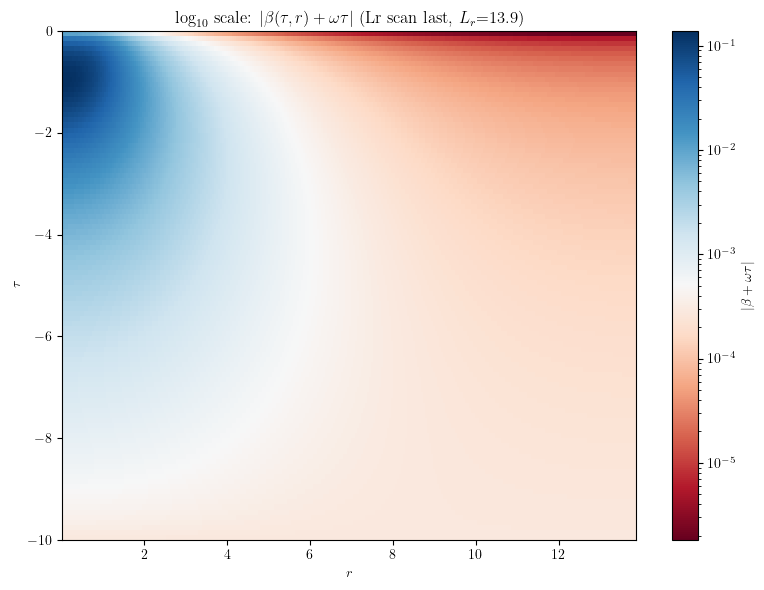

In [ ]:
# Plot hyperbolic phase β(τ, r) = ln(φ̄/φ); φ, φ̄ real
# Use last successful Lr result if available, otherwise the current 2D solution (e.g. sol_eta)
if "last_lr" in dir() and last_lr is not None:
    sol_phase = last_lr["sol"]
    title_suffix = f" (Lr scan last, $L_r$={last_lr['Lr']:.1f})"
elif "results_lr" in dir() and len(results_lr) > 0:
    ok = [r for r in results_lr if r.get("success")]
    if ok:
        sol_phase = ok[-1]["sol"]
        title_suffix = f" (Lr scan last, $L_r$={ok[-1]['Lr']:.1f})"
    else:
        sol_phase = None
        title_suffix = ""
else:
    sol_phase = sol_eta if "sol_eta" in dir() else (sol_newton if "sol_newton" in dir() else None)
    title_suffix = ""

if sol_phase is None:
    print("No 2D solution available; run Newton/eta/Lr scan first.")
else:
    settings_phase = Bubble2DSettings(
        Nr=sol_phase.grid.Nr, Ntau=sol_phase.grid.Ntau,
        Lr=float(sol_phase.grid.dr * sol_phase.grid.Nr),
        beta=sol_phase.settings.beta,
        eta0=solver_newton.eta0, omega_ref=solver_newton.settings.omega_ref,
        rho0=float(solver_newton.rho0),
    )
    solver_phase = Bubble2DSolver(settings_phase, U, dU, d2U)
    phi_c, phibar_c = solver_phase.phi(sol_phase.y, sol_phase.ybar)
    # φ, φ̄ real → hyperbolic phase β = (1/2) ln(φ̄/φ); only where both > 0 (else log = NaN → white plot)
    phi_r = np.real(phi_c)
    phibar_r = np.real(phibar_c)
    eps = 1e-12
    valid = (phi_r > eps) & (phibar_r > eps)
    beta_2d = np.where(valid, 0.5 * np.log(phibar_r / phi_r), np.nan)
    r_phase = np.asarray(solver_phase.grid.r, float)
    tau_phase = np.asarray(solver_phase.grid.tau, float)
    omega_phase = float(solver_phase.omega)
    tau_2d = tau_phase[None, :]
    # β + ωτ (always negative here); plot log10(|β + ωτ|)
    beta_plus_omega_tau = beta_2d + omega_phase * tau_2d
    abs_beta_plus = np.abs(beta_plus_omega_tau)
    small = 1e-30
    to_plot = np.where(np.isfinite(abs_beta_plus) & (abs_beta_plus > 0), abs_beta_plus, small)

    #fig, ax = plt.subplots(1, 1, figsize=(8, 4))
    #im = ax.pcolormesh(r_phase, tau_phase, beta_2d.T, shading="auto", cmap="RdBu_r")
    #ax.set_xlabel(r"$r$")
    #ax.set_ylabel(r"$\tau$")
    #ax.set_title(r"Hyperbolic phase $\beta(\tau,r) = \frac{1}{2}\ln(\bar\phi/\phi)$" + title_suffix)
    #plt.colorbar(im, ax=ax, label=r"$\beta$")
    #fig.tight_layout()
    #plt.show()

    from matplotlib.colors import LogNorm
    fig, ax = plt.subplots(1, 1, figsize=(8, 6))
    vmin = np.nanmin(to_plot)
    vmax = np.nanmax(to_plot)
    if np.isnan(vmin) or vmin <= 0 or vmin == vmax:
        vmin, vmax = 1e-30, 1.0
    im2 = ax.pcolormesh(r_phase, tau_phase, to_plot.T, shading="auto", cmap="RdBu", norm=LogNorm(vmin=vmin, vmax=vmax))
    ax.set_xlabel(r"$r$")
    #ax.set_xlim(0, 3)
    #ax.set_ylim(-3, 0)
    ax.set_ylabel(r"$\tau$")
    ax.set_title(r"$\log_{10}$ scale: $|\beta(\tau,r) + \omega\tau|$" + title_suffix)
    plt.colorbar(im2, ax=ax, label=r"$|\beta + \omega\tau|$")
    fig.tight_layout()
    plt.show()

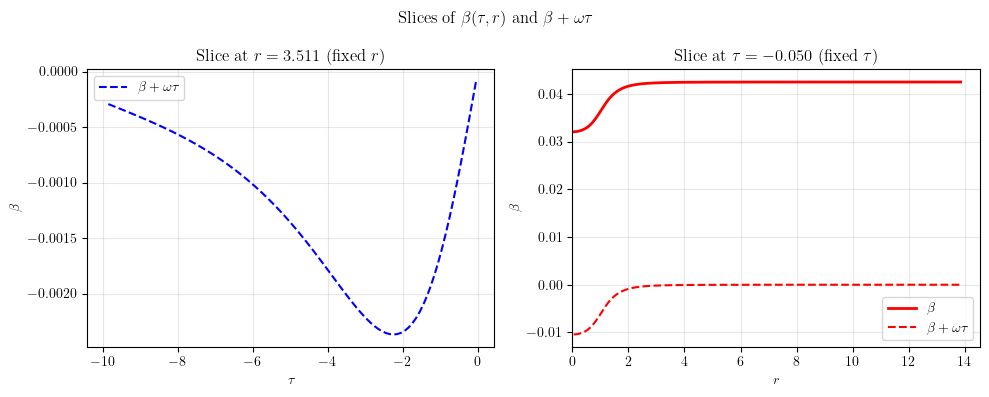

In [ ]:
# Slices of β and of (β − ωτ). Uses beta_2d, r_phase, tau_phase from previous cell.
if "beta_2d" in dir() and "r_phase" in dir() and "tau_phase" in dir():
    omega_slice = float(getattr(solver_phase, "omega", solver_phase.settings.omega_ref)) if "solver_phase" in dir() else 0.0
    beta_plus_omega_tau = beta_2d + omega_slice * tau_phase[None, :]
    Nr, Nt = beta_2d.shape
    i_r_fix = Nr // 4
    i_tau_fix = 0
    r_fix = r_phase[i_r_fix]
    tau_fix = tau_phase[i_tau_fix]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
    #ax1.plot(tau_phase, beta_2d[i_r_fix, :], "b-", lw=2, label=r"$\beta$")
    ax1.plot(tau_phase, beta_plus_omega_tau[i_r_fix, :], "b--", lw=1.5, label=r"$\beta + \omega\tau$")
    ax1.set_xlabel(r"$\tau$")
    ax1.set_ylabel(r"$\beta$")
    ax1.set_title(rf"Slice at $r = {r_fix:.3f}$ (fixed $r$)")
    ax1.legend(loc="best")
    ax1.grid(True, alpha=0.3)

    ax2.plot(r_phase, beta_2d[:, i_tau_fix], "r-", lw=2, label=r"$\beta$")
    ax2.plot(r_phase, beta_plus_omega_tau[:, i_tau_fix], "r--", lw=1.5, label=r"$\beta + \omega\tau$")
    ax2.set_xlabel(r"$r$")
    ax2.set_ylabel(r"$\beta$")
    ax2.set_title(rf"Slice at $\tau = {tau_fix:.3f}$ (fixed $\tau$)")
    ax2.set_xlim(0, None)
    ax2.legend(loc="best")
    ax2.grid(True, alpha=0.3)

    fig.suptitle(r"Slices of $\beta(\tau, r)$ and $\beta + \omega\tau$")
    plt.tight_layout()
    plt.show()
else:
    print("Run the hyperbolic phase (pcolormesh) cell first to define beta_2d, r_phase, tau_phase.")